# CRRT Clot Formation Prediction

**Please refer to Colab notebook Table of Contents for organization.** (https://drive.google.com/file/d/1Lz3ofBgks1gniRNa2ENbomJy363qe1Cp/view?usp=sharing)

**Alternatively, search "THIS IS PART II HOMEWORK BELOW" to go directly to section of this week's assigned homework.**

LLM Disclosure: I used an LLM to assist with writing this code.

**Import Libraries**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, precision_recall_curve
)
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.feature_selection import SelectKBest, f_classif

# For handling class imbalance
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

import warnings
warnings.filterwarnings('ignore')

! pip install gdown
import gdown
import os

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import pickle
from xgboost import XGBClassifier

# Import for custom colormap
from matplotlib.colors import LinearSegmentedColormap

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")
print("\nNote: If you get an import error for imblearn, install it with:")
print("  pip install imbalanced-learn")


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
✓ Libraries imported successfully

Note: If you get an import error for imblearn, install it with:
  pip install imbalanced-learn


**Download dataset**

In [40]:
# For google colab
# files = {
#     "datasetv4.csv": "1C_jmIEtqAQYTiUKecbsUyqibR4jDSEZy"
# }

# for name, fid in files.items():
#     url = f"https://drive.google.com/uc?id={fid}"
#     gdown.download(url, name, quiet=False)

**Load and Explore Data**

In [41]:
# Load the filtered dataset (already filtered for clots IS NOT NULL)
df = pd.read_csv('datasetv4.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClots column distribution (TARGET):")
print(df['clots'].value_counts(dropna=False))
print(f"\nMissing clots: {df['clots'].isnull().sum():,}")

print(f"\nFirst few rows:")
df.head()

Dataset shape: (125611, 64)

Clots column distribution (TARGET):
clots
1    113622
0     11989
Name: count, dtype: int64

Missing clots: 0

First few rows:


,subject_id,hadm_id,stay_id,charttime,crrt_mode,access_pressure,blood_flow,citrate,current_goal,dialysate_fluid,...,pco2,bicarbonate_1,triglyceride,hdl_cholesterol,ldl_cholesterol,ldl_source,magnesium,phosphate,antithrombin,ldh
0,11440929,23071615,30003749,2180-06-07 02:13:00,CVVHDF,-106.0,250.0,200.0,0.0,Prismasate K2,...,28.0,NaN,NaN,NaN,NaN,NaN,2.2,10.0,NaN,NaN
1,15850686,25593892,30005000,2117-12-07 08:00:00,NaN,-58.0,200.0,200.0,0.0,Prismasate K2,...,37.0,NaN,NaN,NaN,NaN,NaN,2.0,3.2,NaN,NaN
2,15850686,25593892,30005000,2117-12-05 20:11:00,CVVHDF,-68.0,200.0,100.0,0.0,Prismasate K2,...,38.0,NaN,179.0,NaN,NaN,NaN,2.4,4.6,NaN,NaN
3,15850686,25593892,30005000,2117-12-06 10:00:00,NaN,-66.0,200.0,200.0,-25.0,Prismasate K2,...,35.0,NaN,NaN,NaN,NaN,NaN,2.1,3.7,NaN,NaN
4,15850686,25593892,30005000,2117-12-06 08:00:00,NaN,-68.0,200.0,200.0,-50.0,Prismasate K2,...,38.0,NaN,NaN,NaN,NaN,NaN,2.3,3.8,NaN,NaN


In [42]:
# Create corrected variable
# df['clots_corrected'] = 1 - df['clots']  # Flip 0→1 and 1→0
df['clots_corrected'] = df['clots']
print("\nCORRECTED 'clots_present' variable:")
print(df['clots_corrected'].value_counts())
print(f"Clots present: {df['clots_corrected'].sum()} ({df['clots_corrected'].mean()*100:.1f}%)")
print(f"\nObservation-level clots rate: {df['clots'].mean()*100:.2f}%")
print(f"Class imbalance ratio: {(df['clots']==0).sum() / (df['clots']==1).sum():.1f}:1")




CORRECTED 'clots_present' variable:
clots_corrected
1    113622
0     11989
Name: count, dtype: int64
Clots present: 113622 (90.5%)

Observation-level clots rate: 90.46%
Class imbalance ratio: 0.1:1


# **EDA**

## **Summary Statistics**

In [43]:
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"Total observations: {len(df):,}")
print(f"Unique patients (subject_id): {df['subject_id'].nunique():,}")
print(f"Unique hospital admissions (hadm_id): {df['hadm_id'].nunique():,}")
print(f"Unique ICU stays (stay_id): {df['stay_id'].nunique():,}")

print("\n" + "="*70)
print("SUMMARY STATISTICS - CONTINUOUS VARIABLES")
print("="*70)

# Define all continuous variables
continuous_vars = [
    # Lab values
    'hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc',
    'd_dimer', 'fibrinogen', 'thrombin', 'inr', 'pt', 'ptt',
    'albumin', 'globulin', 'total_protein', 'aniongap', 'bicarbonate',
    'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium',
    'lactate', 'ph', 'bg_bicarbonate', 'pco2',
    'triglyceride', 'hdl_cholesterol', 'ldl_cholesterol',
    'magnesium', 'phosphate', 'antithrombin', 'ldh',
    # Machine parameters
    'blood_flow', 'filter_pressure', 'access_pressure', 'return_pressure',
    'dialysate_rate', 'replacement_rate', 'ultrafiltrate_output',
    'effluent_pressure', 'hourly_patient_fluid_removal',
    # Anticoagulation
    'citrate', 'heparin_dose'
]

# Filter to variables that exist in the dataset
available_continuous = [var for var in continuous_vars if var in df.columns]

print(f"\nAnalyzing {len(available_continuous)} continuous variables\n")

# Calculate summary statistics
summary_stats = []
for var in available_continuous:
    data = df[var].dropna()

    if len(data) > 0:
        summary_stats.append({
            'Variable': var,
            'N': len(data),
            'Missing': df[var].isna().sum(),
            'Missing %': (df[var].isna().sum() / len(df) * 100),
            'Mean': round(data.mean(), 2),
            'Median': data.median(),
            'Std Dev': round(data.std(), 2),
            'Min': data.min(),
            'Max': data.max(),
            '25th': data.quantile(0.25),
            '75th': data.quantile(0.75)
        })

summary_df = pd.DataFrame(summary_stats)

# Display by category
print("\n" + "="*70)
print("LAB VALUES")
print("="*70)
lab_vars = ['hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc',
            'd_dimer', 'fibrinogen', 'thrombin', 'inr', 'pt', 'ptt',
            'albumin', 'bun', 'calcium', 'creatinine', 'glucose', 'sodium',
            'potassium', 'lactate', 'ph', 'triglyceride', 'magnesium', 'phosphate']
lab_summary = summary_df[summary_df['Variable'].isin(lab_vars)]
print(lab_summary[['Variable', 'N', 'Mean', 'Median', 'Std Dev']].to_string(index=False))

print("\n" + "="*70)
print("MACHINE PARAMETERS")
print("="*70)
machine_vars = ['blood_flow', 'filter_pressure', 'access_pressure', 'return_pressure',
                'dialysate_rate', 'replacement_rate', 'ultrafiltrate_output', 'effluent_pressure']
machine_summary = summary_df[summary_df['Variable'].isin(machine_vars)]
print(machine_summary[['Variable', 'N', 'Mean', 'Median', 'Std Dev']].to_string(index=False))

# Save full summary to CSV
summary_df.to_csv('summary_statistics.csv', index=False)
print(f"\n✓ Full summary statistics saved to 'summary_statistics.csv'")

DATA SUMMARY
Total observations: 125,611
Unique patients (subject_id): 1,971
Unique hospital admissions (hadm_id): 2,063
Unique ICU stays (stay_id): 2,137

SUMMARY STATISTICS - CONTINUOUS VARIABLES

Analyzing 44 continuous variables


LAB VALUES
    Variable      N    Mean  Median  Std Dev
  hematocrit 121687   27.29   26.60     4.23
  hemoglobin 114871    8.88    8.60     1.42
    platelet 116261  148.83  116.00   114.39
         rbc 113395    2.92    2.84     0.52
         wbc 113345   17.24   15.10    11.02
     d_dimer   2311 5778.40 5003.00  4661.34
  fibrinogen  26252  338.83  232.00   252.58
    thrombin    100   25.87   15.80    29.79
         inr 102953    1.68    1.40     0.84
          pt 102997   18.28   15.70     8.32
         ptt 108369   46.59   39.50    21.31
     albumin  15673    2.90    2.80     0.78
         bun 101599   28.55   24.00    19.19
     calcium  99929    9.04    9.00     0.94
  creatinine 101875    1.82    1.50     1.22
     glucose 117453  153.64  142.0

In [44]:
print(df.columns)

Index(['subject_id', 'hadm_id', 'stay_id', 'charttime', 'crrt_mode',
       'access_pressure', 'blood_flow', 'citrate', 'current_goal',
       'dialysate_fluid', 'dialysate_rate', 'effluent_pressure',
       'filter_pressure', 'heparin_concentration', 'heparin_dose',
       'hourly_patient_fluid_removal', 'prefilter_replacement_rate',
       'postfilter_replacement_rate', 'replacement_fluid', 'replacement_rate',
       'return_pressure', 'ultrafiltrate_output', 'system_active', 'clots',
       'clots_increasing', 'clotted', 'race', 'line_type', 'line_site',
       'hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc', 'd_dimer',
       'fibrinogen', 'thrombin', 'inr', 'pt', 'ptt', 'albumin', 'globulin',
       'total_protein', 'aniongap', 'bicarbonate', 'bun', 'calcium',
       'chloride', 'creatinine', 'glucose', 'sodium', 'potassium', 'lactate',
       'ph', 'pco2', 'bicarbonate_1', 'triglyceride', 'hdl_cholesterol',
       'ldl_cholesterol', 'ldl_source', 'magnesium', 'phosphate',
  

## **Distribution Plots**

## **Correlation Analysis**

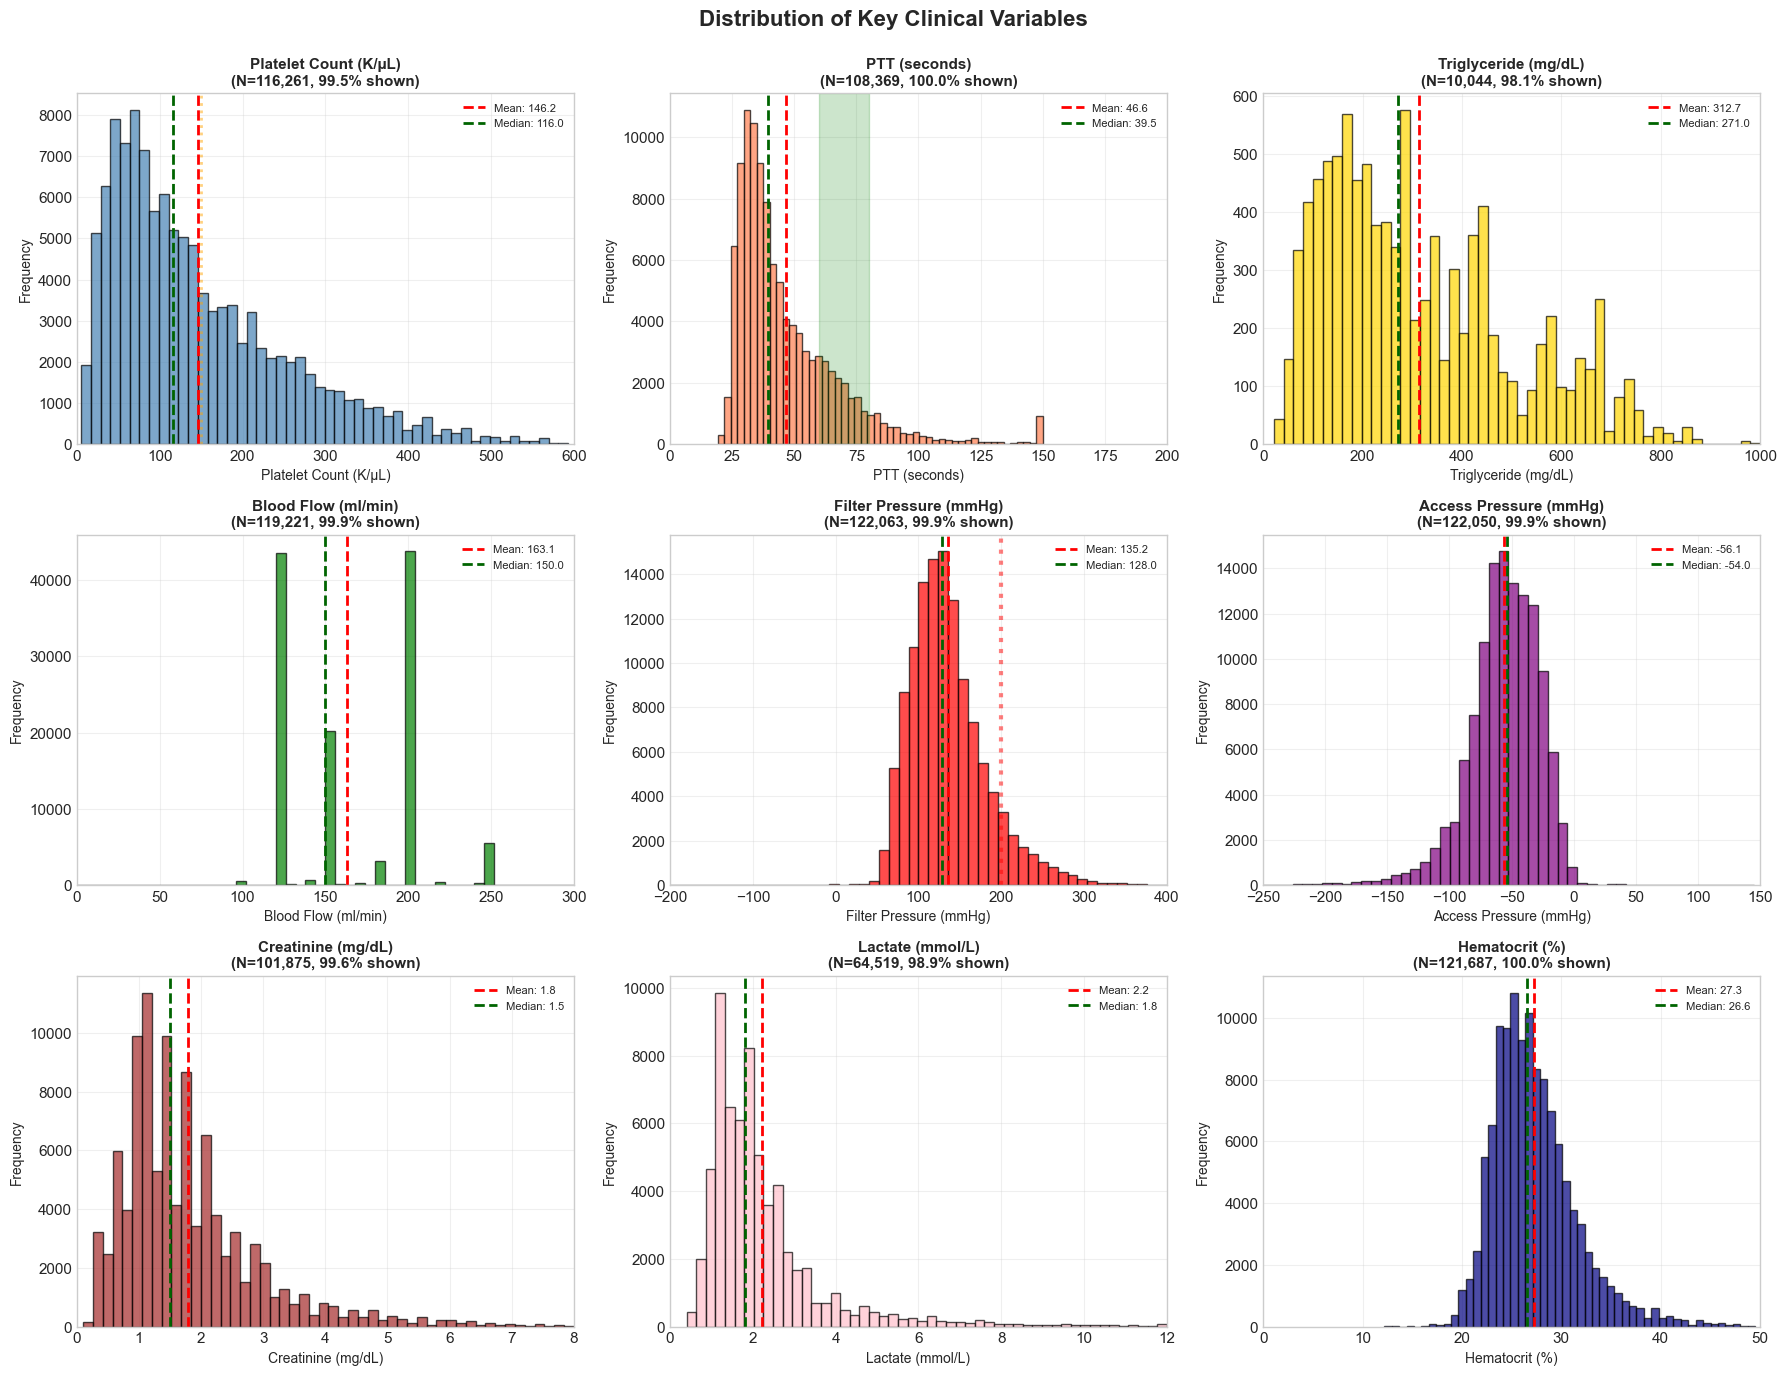


OUTLIER ANALYSIS

Percentage of extreme outliers (beyond 99th percentile):

platelet            :  1,155 ( 0.99%) above 518.0
ptt                 :  1,075 ( 0.99%) above 138.4
triglyceride        :    100 ( 1.00%) above 1140.0
blood_flow          :    248 ( 0.21%) above 250.0
filter_pressure     :  1,207 ( 0.99%) above 286.0
creatinine          :    992 ( 0.97%) above 6.4
lactate             :    633 ( 0.98%) above 12.2


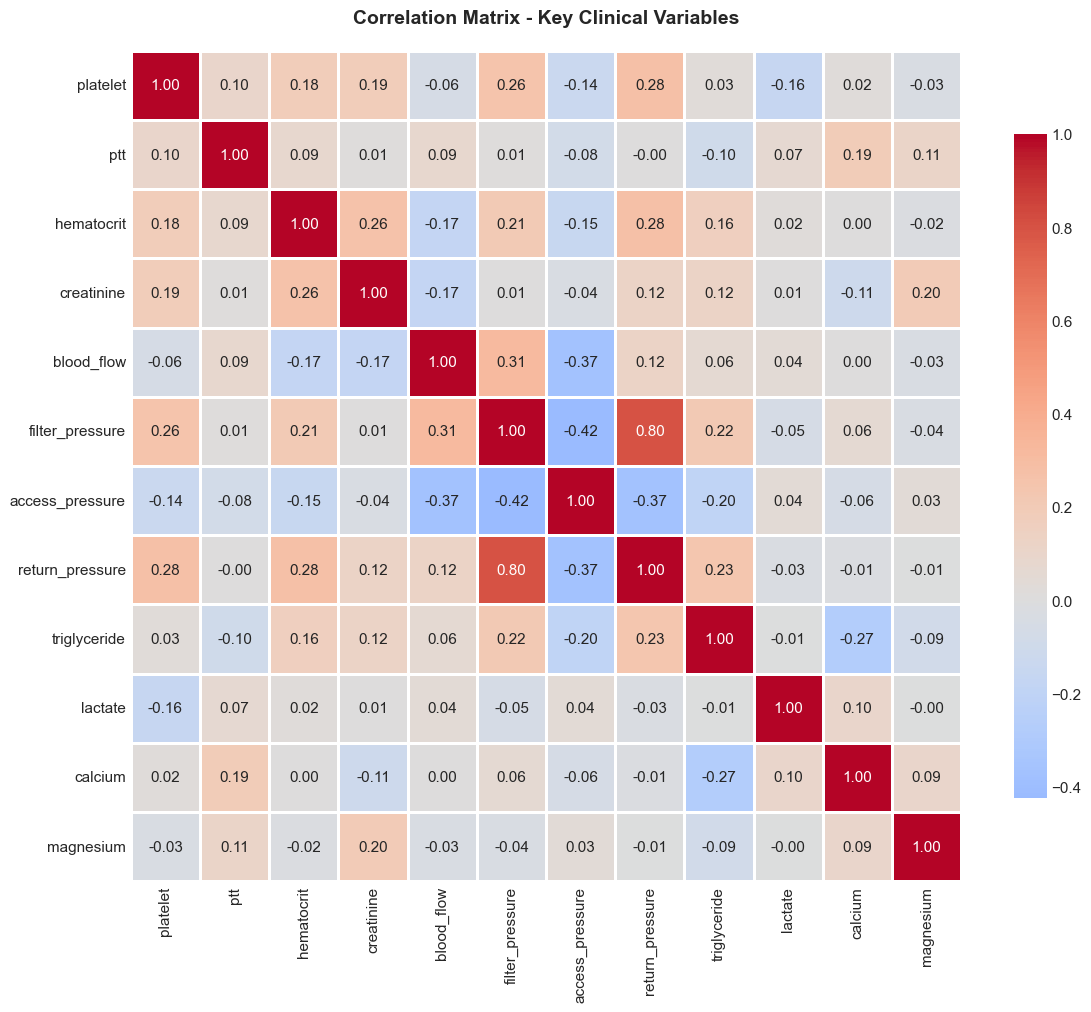

In [45]:
# ----------------------------------------------------------------
# FIGURE 1: Distribution of Key Variables
# ----------------------------------------------------------------
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 12)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Distribution of Key Clinical Variables\n', fontsize=16, fontweight='bold')

key_vars = [
    ('platelet', 'Platelet Count (K/µL)', 'steelblue', (0, 600)),  # Cut off extreme outliers
    ('ptt', 'PTT (seconds)', 'coral', (0, 200)),  # Focus on clinically relevant range
    ('triglyceride', 'Triglyceride (mg/dL)', 'gold', (0, 1000)),  # Cut off extremes
    ('blood_flow', 'Blood Flow (ml/min)', 'green', (0, 300)),  # Focus on main distribution
    ('filter_pressure', 'Filter Pressure (mmHg)', 'red', (-200, 400)),  # Cut off outliers
    ('access_pressure', 'Access Pressure (mmHg)', 'purple', (-250, 150)),  # Should be negative
    ('creatinine', 'Creatinine (mg/dL)', 'brown', (0, 8)),  # Focus on relevant range
    ('lactate', 'Lactate (mmol/L)', 'pink', (0, 12)),  # Cut off extremes
    ('hematocrit', 'Hematocrit (%)', 'navy', (0, 50))  # Physiologic range
]

for idx, (var, title, color, xlim) in enumerate(key_vars):
    ax = axes[idx // 3, idx % 3]
    if var in df.columns:
        data = df[var].dropna()

        # Filter data to reasonable range for better visualization
        data_filtered = data[(data >= xlim[0]) & (data <= xlim[1])]

        if len(data_filtered) > 0:
            ax.hist(data_filtered, bins=50, edgecolor='black', alpha=0.7, color=color)

            # Add mean and median lines
            mean_val = data_filtered.mean()
            median_val = data_filtered.median()
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                      label=f'Mean: {mean_val:.1f}')
            ax.axvline(median_val, color='darkgreen', linestyle='--', linewidth=2,
                      label=f'Median: {median_val:.1f}')

            # Set labels and limits
            ax.set_xlabel(title, fontsize=10)
            ax.set_ylabel('Frequency', fontsize=10)
            ax.set_xlim(xlim)

            # Show percentage of data included
            pct_included = (len(data_filtered) / len(data)) * 100
            ax.set_title(f'{title}\n(N={len(data):,}, {pct_included:.1f}% shown)',
                        fontsize=11, fontweight='bold')

            ax.legend(fontsize=8, loc='upper right')
            ax.grid(True, alpha=0.3)

            # Add reference lines for clinically important values
            if var == 'filter_pressure':
                ax.axvline(200, color='red', linestyle=':', linewidth=3,
                          label='High Pressure (≥200)', alpha=0.5)
            elif var == 'ptt':
                ax.axvspan(60, 80, alpha=0.2, color='green', label='Therapeutic Range')
            elif var == 'platelet':
                ax.axvline(150, color='orange', linestyle=':', linewidth=2,
                          label='Low (<150)', alpha=0.5)

    else:
        ax.text(0.5, 0.5, f'{var}\nNot Available', ha='center', va='center', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# ADDITIONAL: Show outlier information
# ----------------------------------------------------------------

print("\n" + "="*70)
print("OUTLIER ANALYSIS")
print("="*70)

outlier_vars = ['platelet', 'ptt', 'triglyceride', 'blood_flow', 'filter_pressure',
                'creatinine', 'lactate']

print("\nPercentage of extreme outliers (beyond 99th percentile):\n")
for var in outlier_vars:
    if var in df.columns:
        data = df[var].dropna()
        p99 = data.quantile(0.99)
        outliers = (data > p99).sum()
        pct = (outliers / len(data)) * 100
        print(f"{var:20s}: {outliers:6,} ({pct:5.2f}%) above {p99:.1f}")

# ----------------------------------------------------------------
# FIGURE 2: Correlation Heatmap
# ----------------------------------------------------------------

# Select numeric columns for correlation
numeric_cols = ['platelet', 'ptt', 'hematocrit', 'creatinine', 'blood_flow',
                'filter_pressure', 'access_pressure', 'return_pressure',
                'triglyceride', 'lactate', 'calcium', 'magnesium']

available_numeric = [col for col in numeric_cols if col in df.columns]
corr_data = df[available_numeric].dropna()

if len(corr_data) > 100:
    correlation_matrix = corr_data.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix - Key Clinical Variables', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Insufficient data for correlation matrix")

## **Comparison by Outcome**


Creating improved box plots by outcome...


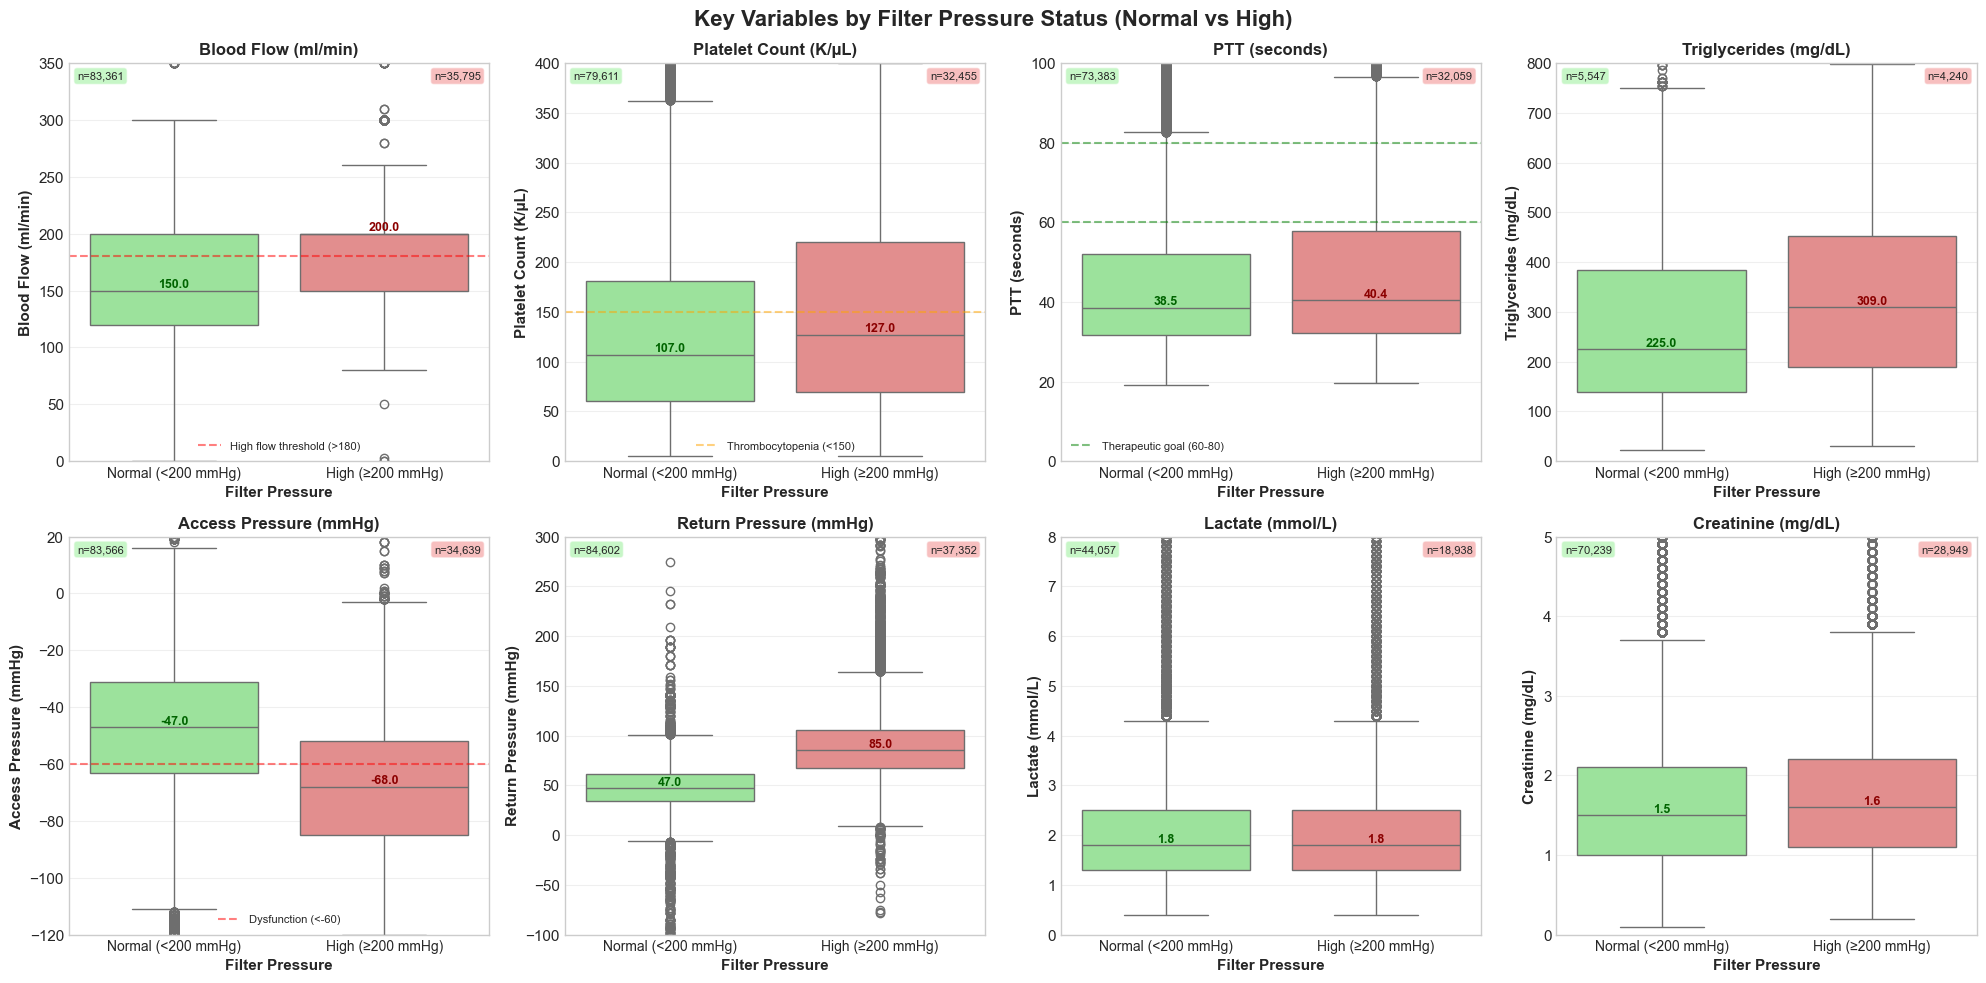


COMPARISON: NORMAL vs HIGH FILTER PRESSURE

               Variable  Normal_Median  High_Median  Difference  Normal_Mean  High_Mean
   Blood Flow (ml/min)          150.0        200.0        50.0       154.09     184.39
 Platelet Count (K/µL)          107.0        127.0        20.0       129.82     150.64
         PTT (seconds)           38.5         40.4         1.9        43.50      46.33
 Triglycerides (mg/dL)          225.0        309.0        84.0       278.65     348.23
Access Pressure (mmHg)          -47.0        -68.0       -21.0       -47.83     -68.25
Return Pressure (mmHg)           47.0         85.0        38.0        48.13      89.21
      Lactate (mmol/L)            1.8          1.8         0.0         2.12       2.14
    Creatinine (mg/dL)            1.5          1.6         0.1         1.66       1.79


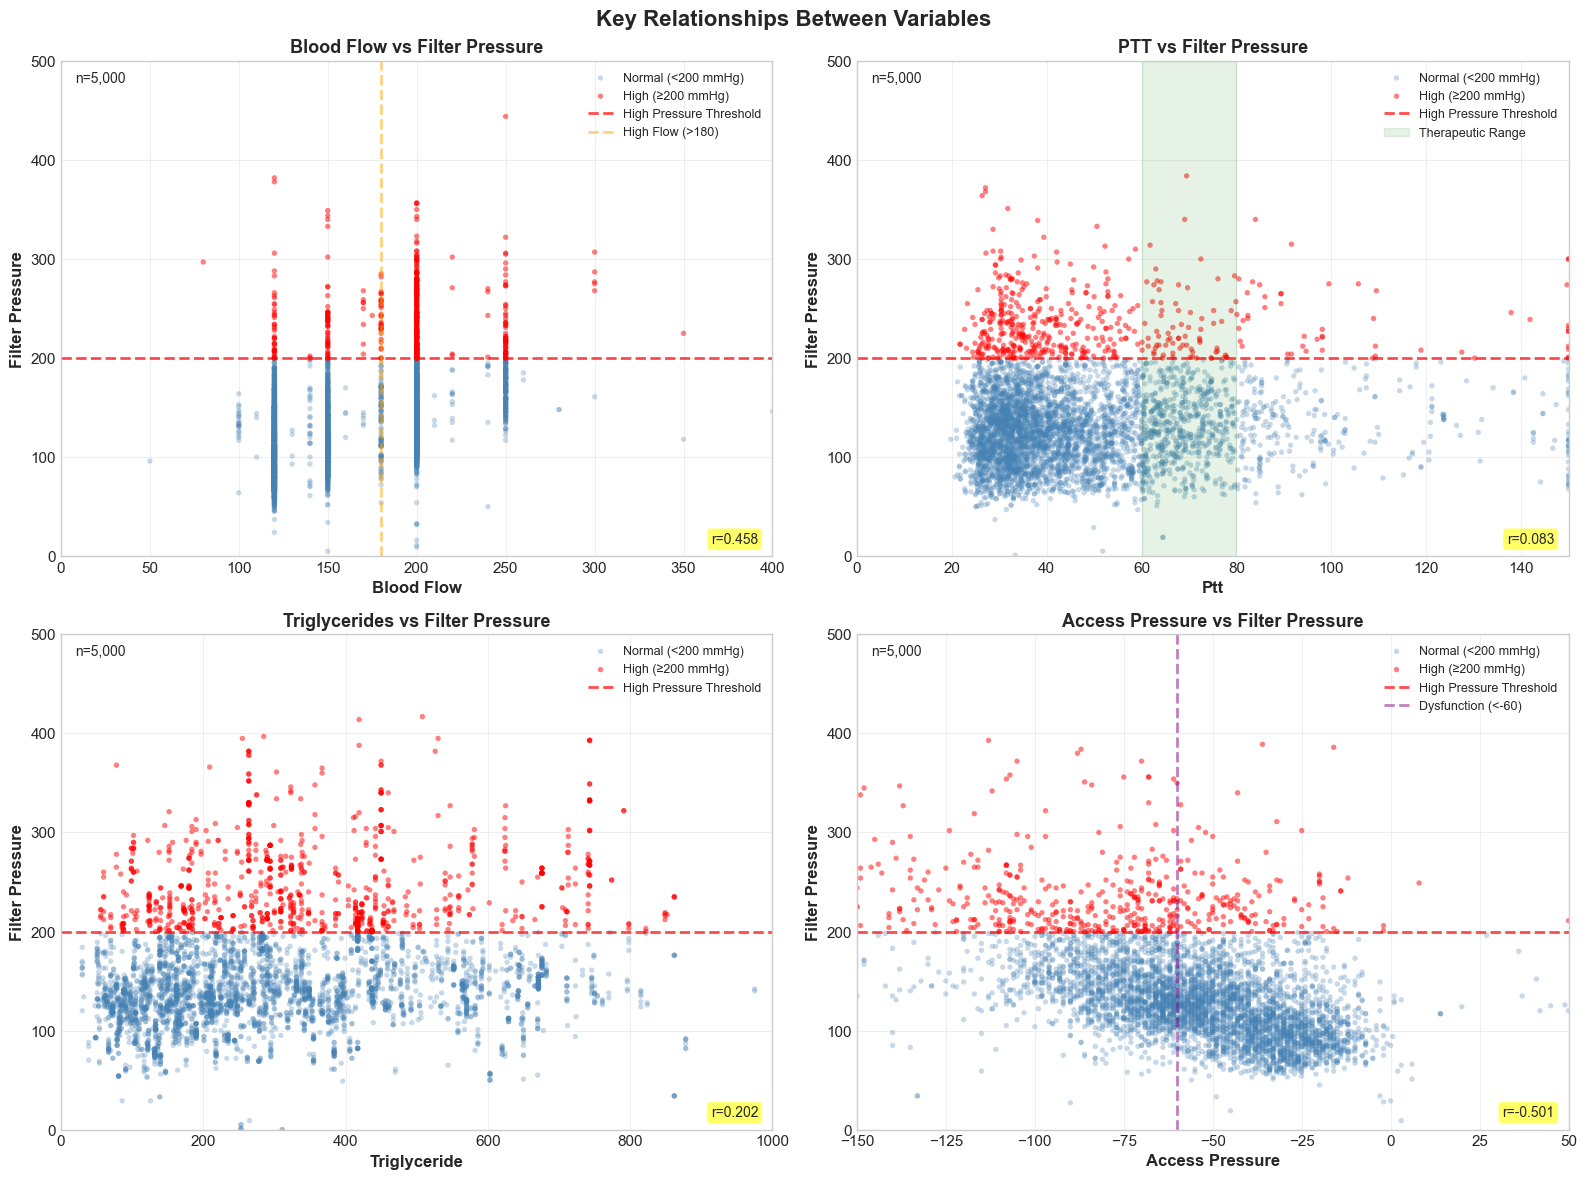

In [46]:
# ----------------------------------------------------------------
# FIGURE 3: Box Plots by Outcome
# ----------------------------------------------------------------

print("\nCreating improved box plots by outcome...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Key Variables by Filter Pressure Status (Normal vs High)', fontsize=16, fontweight='bold')

# Create outcome variable for visualization
df['high_pressure'] = (df['filter_pressure'] >= 150).astype(int)

# Define variables with better y-axis limits and outlier handling
boxplot_vars = [
    ('blood_flow', 'Blood Flow (ml/min)', (0, 350)),
    ('platelet', 'Platelet Count (K/µL)', (0, 400)),
    ('ptt', 'PTT (seconds)', (0, 100)),
    ('triglyceride', 'Triglycerides (mg/dL)', (0, 800)),
    ('access_pressure', 'Access Pressure (mmHg)', (-120, 20)),
    ('return_pressure', 'Return Pressure (mmHg)', (-100, 300)),
    ('lactate', 'Lactate (mmol/L)', (0, 8)),
    ('creatinine', 'Creatinine (mg/dL)', (0, 5))
]

for idx, (var, title, ylim) in enumerate(boxplot_vars):
    ax = axes[idx // 4, idx % 4]
    if var in df.columns:
        # Filter data to remove extreme outliers
        data_to_plot = df[[var, 'high_pressure']].dropna()
        data_to_plot = data_to_plot[(data_to_plot[var] >= ylim[0]) &
                                     (data_to_plot[var] <= ylim[1])]

        if len(data_to_plot) > 0:
            # Create boxplot
            sns.boxplot(data=data_to_plot, x='high_pressure', y=var, ax=ax,
                       palette=['lightgreen', 'lightcoral'], showfliers=True)

            # Set labels
            ax.set_xlabel('Filter Pressure', fontsize=11, fontweight='bold')
            ax.set_xticklabels(['Normal (<200 mmHg)', 'High (≥200 mmHg)'], fontsize=10)
            ax.set_ylabel(title, fontsize=11, fontweight='bold')
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_ylim(ylim)
            ax.grid(True, alpha=0.3, axis='y')

            # Calculate and display statistics
            normal_vals = data_to_plot[data_to_plot['high_pressure']==0][var]
            high_vals = data_to_plot[data_to_plot['high_pressure']==1][var]

            if len(normal_vals) > 0 and len(high_vals) > 0:
                normal_median = normal_vals.median()
                high_median = high_vals.median()

                # Add median values as text
                ax.text(0, normal_median, f'{normal_median:.1f}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkgreen')
                ax.text(1, high_median, f'{high_median:.1f}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkred')

                # Add reference lines for clinical thresholds
                if var == 'ptt':
                    ax.axhline(y=60, color='green', linestyle='--', linewidth=1.5,
                              alpha=0.5, label='Therapeutic goal (60-80)')
                    ax.axhline(y=80, color='green', linestyle='--', linewidth=1.5, alpha=0.5)
                    ax.legend(fontsize=8)
                elif var == 'platelet':
                    ax.axhline(y=150, color='orange', linestyle='--', linewidth=1.5,
                              alpha=0.5, label='Thrombocytopenia (<150)')
                    ax.legend(fontsize=8)
                elif var == 'blood_flow':
                    ax.axhline(y=180, color='red', linestyle='--', linewidth=1.5,
                              alpha=0.5, label='High flow threshold (>180)')
                    ax.legend(fontsize=8)
                elif var == 'access_pressure':
                    ax.axhline(y=-60, color='red', linestyle='--', linewidth=1.5,
                              alpha=0.5, label='Dysfunction (<-60)')
                    ax.legend(fontsize=8)

            # Show sample sizes
            n_normal = len(normal_vals)
            n_high = len(high_vals)
            ax.text(0.02, 0.98, f'n={n_normal:,}', transform=ax.transAxes,
                   fontsize=8, va='top', ha='left', bbox=dict(boxstyle='round',
                   facecolor='lightgreen', alpha=0.5))
            ax.text(0.98, 0.98, f'n={n_high:,}', transform=ax.transAxes,
                   fontsize=8, va='top', ha='right', bbox=dict(boxstyle='round',
                   facecolor='lightcoral', alpha=0.5))
    else:
        ax.text(0.5, 0.5, f'{var}\nNot Available', ha='center', va='center', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# Print comparison statistics
# ----------------------------------------------------------------

print("\n" + "="*70)
print("COMPARISON: NORMAL vs HIGH FILTER PRESSURE")
print("="*70)

comparison_results = []
for var, title, ylim in boxplot_vars:
    if var in df.columns:
        normal_vals = df[df['high_pressure']==0][var].dropna()
        high_vals = df[df['high_pressure']==1][var].dropna()

        # Filter to reasonable range
        normal_vals = normal_vals[(normal_vals >= ylim[0]) & (normal_vals <= ylim[1])]
        high_vals = high_vals[(high_vals >= ylim[0]) & (high_vals <= ylim[1])]

        if len(normal_vals) > 0 and len(high_vals) > 0:
            comparison_results.append({
                'Variable': title,
                'Normal_Median': normal_vals.median(),
                'High_Median': high_vals.median(),
                'Difference': high_vals.median() - normal_vals.median(),
                'Normal_Mean': round(normal_vals.mean(), 2),
                'High_Mean': round(high_vals.mean(), 2)
            })

comparison_df = pd.DataFrame(comparison_results)
print("\n", comparison_df.to_string(index=False))


# ----------------------------------------------------------------
# FIGURE 4: Scatter Plots - Key Relationships
# ----------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Key Relationships Between Variables', fontsize=16, fontweight='bold')

# Define scatter pairs with appropriate axis limits
scatter_pairs = [
    ('blood_flow', 'filter_pressure', 'Blood Flow vs Filter Pressure',
     (0, 400), (0, 500)),
    ('ptt', 'filter_pressure', 'PTT vs Filter Pressure',
     (0, 150), (0, 500)),
    ('triglyceride', 'filter_pressure', 'Triglycerides vs Filter Pressure',
     (0, 1000), (0, 500)),
    ('access_pressure', 'filter_pressure', 'Access Pressure vs Filter Pressure',
     (-150, 50), (0, 500))
]

for idx, (x_var, y_var, title, xlim, ylim) in enumerate(scatter_pairs):
    ax = axes[idx // 2, idx % 2]
    if x_var in df.columns and y_var in df.columns:
        # Filter data to remove outliers
        plot_data = df[[x_var, y_var]].dropna()
        plot_data = plot_data[
            (plot_data[x_var] >= xlim[0]) & (plot_data[x_var] <= xlim[1]) &
            (plot_data[y_var] >= ylim[0]) & (plot_data[y_var] <= ylim[1])
        ]

        # Sample if too many points (for performance)
        if len(plot_data) > 5000:
            plot_data = plot_data.sample(5000, random_state=42)

        if len(plot_data) > 0:
            # Create scatter plot with color based on high pressure
            plot_data['high_pressure'] = (plot_data[y_var] >= 200).astype(int)

            # Plot normal pressure in blue, high pressure in red
            normal = plot_data[plot_data['high_pressure'] == 0]
            high = plot_data[plot_data['high_pressure'] == 1]

            ax.scatter(normal[x_var], normal[y_var], alpha=0.3, s=15,
                      c='steelblue', label='Normal (<200 mmHg)', edgecolors='none')
            ax.scatter(high[x_var], high[y_var], alpha=0.5, s=15,
                      c='red', label='High (≥200 mmHg)', edgecolors='none')

            # Add horizontal line at high pressure threshold
            ax.axhline(y=200, color='red', linestyle='--', linewidth=2,
                      label='High Pressure Threshold', alpha=0.7)

            # Add vertical reference lines for specific variables
            if x_var == 'blood_flow':
                ax.axvline(x=180, color='orange', linestyle='--', linewidth=2,
                          label='High Flow (>180)', alpha=0.5)
            elif x_var == 'ptt':
                ax.axvspan(60, 80, alpha=0.1, color='green', label='Therapeutic Range')
            elif x_var == 'access_pressure':
                ax.axvline(x=-60, color='purple', linestyle='--', linewidth=2,
                          label='Dysfunction (<-60)', alpha=0.5)

            # Set labels and limits
            ax.set_xlabel(x_var.replace('_', ' ').title(), fontsize=12, fontweight='bold')
            ax.set_ylabel(y_var.replace('_', ' ').title(), fontsize=12, fontweight='bold')
            ax.set_title(title, fontsize=13, fontweight='bold')
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
            ax.legend(fontsize=9, loc='best')
            ax.grid(True, alpha=0.3)

            # Add sample size
            ax.text(0.02, 0.98, f'n={len(plot_data):,}',
                   transform=ax.transAxes, fontsize=10, va='top', ha='left',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

            # Calculate and display correlation
            corr = plot_data[x_var].corr(plot_data[y_var])
            ax.text(0.98, 0.02, f'r={corr:.3f}',
                   transform=ax.transAxes, fontsize=10, va='bottom', ha='right',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))
    else:
        ax.text(0.5, 0.5, f'Data not available', ha='center', va='center', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()




## **Missing Data**


MISSING DATA ANALYSIS

Variables with Missing Data (Top 20):
            Variable  Missing Count  Missing %
        antithrombin         125611     100.00
            globulin         125553      99.95
            thrombin         125511      99.92
       total_protein         125425      99.85
     ldl_cholesterol         125292      99.75
     hdl_cholesterol         125126      99.61
             d_dimer         123300      98.16
        triglyceride         115567      92.00
             albumin         109938      87.52
          fibrinogen          99359      79.10
                 ldh          74317      59.16
             lactate          61092      48.64
        heparin_dose          52839      42.07
ultrafiltrate_output          29891      23.80
             calcium          25682      20.45
                 bun          24012      19.12
          creatinine          23736      18.90
             citrate          23570      18.76
                 inr          22658      18.0

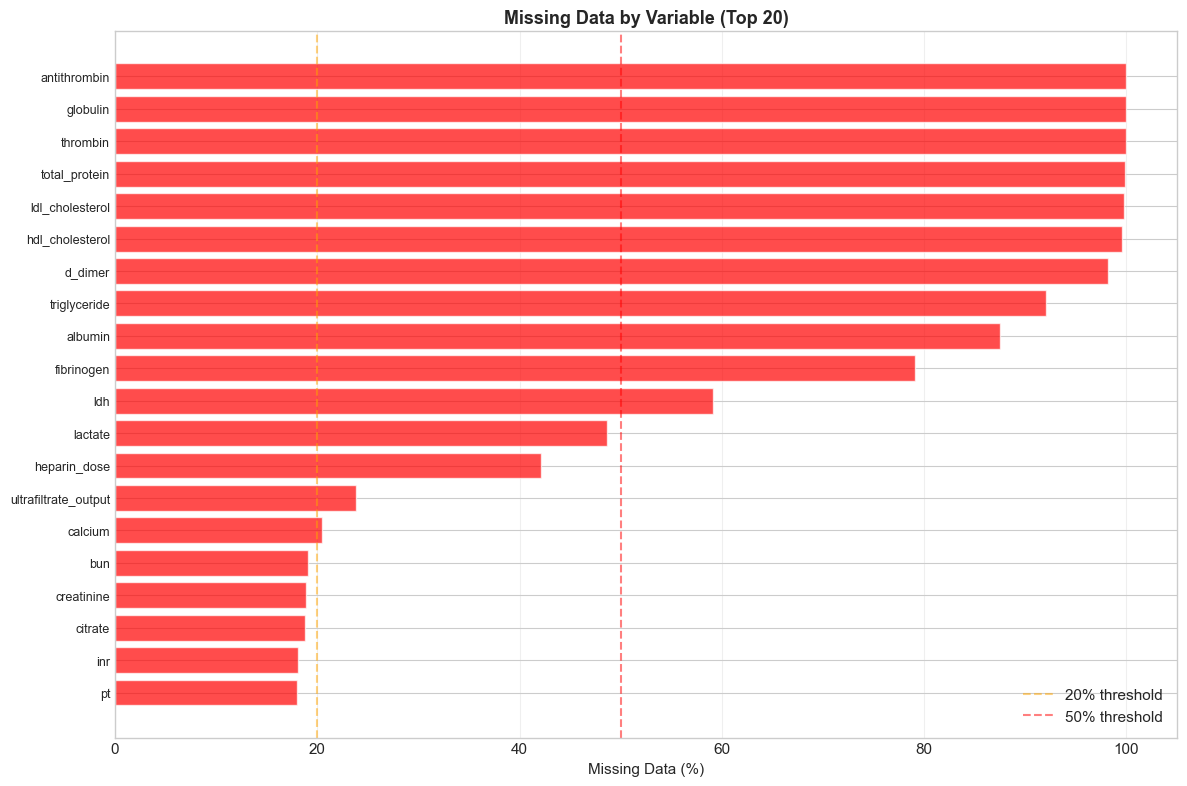

In [47]:
# ----------------------------------------------------------------
# MISSING DATA ANALYSIS
# ----------------------------------------------------------------

print("\n" + "="*70)
print("MISSING DATA ANALYSIS")
print("="*70)

missing_summary = []
for col in available_continuous:
    missing_count = df[col].isna().sum()
    missing_pct = round((missing_count / len(df)) * 100, 2)
    if missing_count > 0:
        missing_summary.append({
            'Variable': col,
            'Missing Count': missing_count,
            'Missing %': missing_pct
        })

missing_df = pd.DataFrame(missing_summary).sort_values('Missing %', ascending=False)

print("\nVariables with Missing Data (Top 20):")
print(missing_df.head(20).to_string(index=False))

# Visualize missing data
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    top_missing = missing_df.head(20).sort_values('Missing %')
    colors = ['red']
    ax.barh(range(len(top_missing)), top_missing['Missing %'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_missing)))
    ax.set_yticklabels(top_missing['Variable'], fontsize=9)
    ax.set_xlabel('Missing Data (%)', fontsize=11)
    ax.set_title('Missing Data by Variable (Top 20)', fontsize=13, fontweight='bold')
    ax.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='20% threshold')
    ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

## Drop features with >80% missing data

In [48]:
# ================================================================
# REMOVE FEATURES WITH >80% MISSING DATA
# ================================================================

print("="*70)
print("REMOVING LOW-QUALITY FEATURES")
print("="*70)

# Calculate missing percentage for ALL features (not just specific groups)
missing_threshold = 0.80
id_cols = ['subject_id', 'hadm_id', 'stay_id', 'charttime']
target_col = 'clots_corrected'  # Our prediction target (1=clot, 0=no clot)

# Get all columns except IDs and target
potential_features = [col for col in df.columns if col not in id_cols + [target_col, 'clots']]

# Calculate missing percentages
missing_pct = df[potential_features].isnull().sum() / len(df)

# Find features with too much missing data
high_missing_features = missing_pct[missing_pct > missing_threshold].sort_values(ascending=False)

print(f"\nAnalyzing {len(potential_features)} features...")
print(f"Threshold: >{missing_threshold*100}% missing data\n")

if len(high_missing_features) > 0:
    print(f"Found {len(high_missing_features)} features with >{missing_threshold*100}% missing data:")
    print("-" * 60)
    for feat, pct in high_missing_features.items():
        print(f"  {feat:.<50} {pct*100:>6.1f}% missing")
    print("-" * 60)

    # Remove these features from the dataframe
    df = df.drop(columns=high_missing_features.index.tolist())
    print(f"\n✓ Removed {len(high_missing_features)} low-quality features")
else:
    print("✓ No features have more than 80% missing data")

print(f"\n✓ Remaining columns in dataset: {len(df.columns)}")
print(f"  (This includes IDs, target, and all usable features)")

REMOVING LOW-QUALITY FEATURES

Analyzing 60 features...
Threshold: >80.0% missing data

Found 14 features with >80.0% missing data:
------------------------------------------------------------
  antithrombin......................................  100.0% missing
  globulin..........................................  100.0% missing
  thrombin..........................................   99.9% missing
  clotted...........................................   99.9% missing
  total_protein.....................................   99.9% missing
  ldl_cholesterol...................................   99.7% missing
  bicarbonate_1.....................................   99.7% missing
  hdl_cholesterol...................................   99.6% missing
  ldl_source........................................   99.5% missing
  clots_increasing..................................   98.3% missing
  d_dimer...........................................   98.2% missing
  triglyceride..................................

## Patient-Level Analysis

PATIENT-LEVEL CLOTS ANALYSIS

Total unique patients: 1,971

Patients who had visible clots: 1,791
Patients who never had clots: 180

Proportion of patients with clots: 90.87%

------------------------------------------------------------
Distribution of clots observations per patient (among those with clots):
count    1791.000000
mean       63.440536
std       150.819514
min         1.000000
25%         8.000000
50%        24.000000
75%        65.000000
max      2803.000000
Name: num_clots_observations, dtype: float64


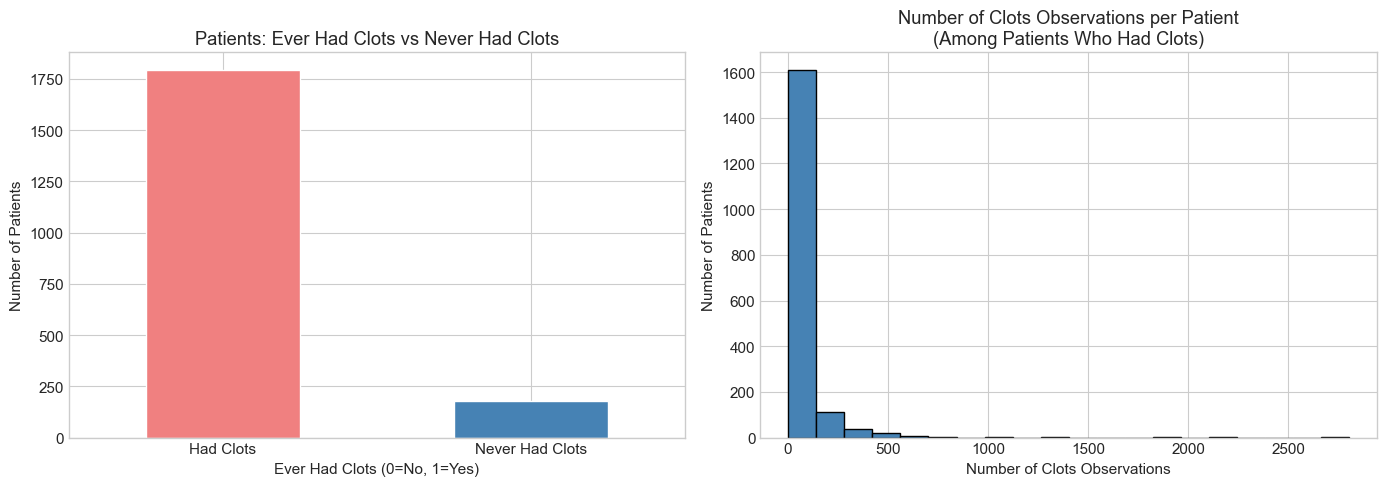

In [49]:
# Patient-level clots analysis
print("=" * 60)
print("PATIENT-LEVEL CLOTS ANALYSIS")
print("=" * 60)

# For each patient, check if they had visible clots
patient_clots = df.groupby('subject_id')['clots'].agg(['max', 'sum', 'count'])
patient_clots.columns = ['ever_had_clots', 'num_clots_observations', 'total_observations']

print(f"\nTotal unique patients: {len(patient_clots):,}")
print(f"\nPatients who had visible clots: {(patient_clots['ever_had_clots'] == 1).sum():,}")
print(f"Patients who never had clots: {(patient_clots['ever_had_clots'] == 0).sum():,}")
print(f"\nProportion of patients with clots: {(patient_clots['ever_had_clots'] == 1).mean()*100:.2f}%")

print("\n" + "-" * 60)
print("Distribution of clots observations per patient (among those with clots):")
print(patient_clots[patient_clots['ever_had_clots'] == 1]['num_clots_observations'].describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Patient-level clots
patient_clots['ever_had_clots'].value_counts().plot(kind='bar', ax=axes[0], color=['lightcoral', 'steelblue'])
axes[0].set_title('Patients: Ever Had Clots vs Never Had Clots')
axes[0].set_xlabel('Ever Had Clots (0=No, 1=Yes)')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xticklabels(['Had Clots', 'Never Had Clots'], rotation=0)

# Distribution of clots observations among patients who had clots
clots_patients = patient_clots[patient_clots['ever_had_clots'] == 1]
clots_patients['num_clots_observations'].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Number of Clots Observations per Patient\n(Among Patients Who Had Clots)')
axes[1].set_xlabel('Number of Clots Observations')
axes[1].set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()

# **Feature Engineering**

## **Define Feature Groups**

In [50]:
# Define ID columns and target
id_cols = ['subject_id', 'hadm_id', 'stay_id', 'charttime']
target_col = 'clots_corrected'  # Our prediction target (1=clot, 0=no clot)

# Document feature groups for reference
# (Create the actual feature_cols list after feature engineering)

crrt_machine_params = [
    'crrt_mode', 'access_pressure', 'blood_flow', 'citrate', 'current_goal',
    'dialysate_fluid', 'dialysate_rate', 'effluent_pressure', 'filter_pressure',
    'heparin_concentration', 'heparin_dose', 'hourly_patient_fluid_removal',
    'prefilter_replacement_rate', 'postfilter_replacement_rate',
    'replacement_fluid', 'replacement_rate', 'return_pressure',
    'ultrafiltrate_output', 'system_active'
]
# demographics and lines
demographics = ['race', 'line_type', 'line_site']

lab_values = [
    # Complete Blood Count
    'hematocrit', 'platelet', 'rbc', 'wbc',
    # Coagulation
    'd_dimer', 'fibrinogen', 'thrombin', 'inr', 'pt', 'ptt',
    # Chemistry
    'albumin', 'globulin', 'total_protein', 'aniongap', 'bicarbonate',
    'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium'
]

print("Feature groups defined:")
print(f"  - ID columns: {len(id_cols)}")
print(f"  - CRRT machine parameters: {len(crrt_machine_params)}")
print(f"  - Demographics: {len(demographics)}")
print(f"  - Lab values: {len(lab_values)}")
print(f"\n  - TARGET: '{target_col}' (1=clot, 0=no clot)")

# Note: We'll create feature_cols list after all feature engineering is complete

Feature groups defined:
  - ID columns: 4
  - CRRT machine parameters: 19
  - Demographics: 3
  - Lab values: 22

  - TARGET: 'clots_corrected' (1=clot, 0=no clot)


## Feature Engineering

### Create interaction, ratio, and polynomial features

In [51]:
# ================================================================
# CREATE INTERACTION AND RATIO FEATURES
# ================================================================

print("="*70)
print("CREATING ENGINEERED FEATURES")
print("="*70)

features_created = []

# === INTERACTION FEATURES ===
print("\n1. Creating interaction features...")

# BUN/Creatinine ratio (classic kidney function marker)
if 'bun' in df.columns and 'creatinine' in df.columns:
    df['bun_creatinine_ratio'] = df['bun'] / (df['creatinine'] + 1e-6)
    features_created.append('bun_creatinine_ratio')

# Platelet * PTT interaction (clotting capacity)
if 'platelet' in df.columns and 'ptt' in df.columns:
    df['platelet_ptt_interaction'] = df['platelet'] * df['ptt']
    features_created.append('platelet_ptt_interaction')

# Hematocrit * Blood Flow (blood viscosity effect)
if 'hematocrit' in df.columns and 'blood_flow' in df.columns:
    df['hct_bloodflow_interaction'] = df['hematocrit'] * df['blood_flow']
    features_created.append('hct_bloodflow_interaction')

# === RATIO FEATURES ===
print("2. Creating ratio features...")

# WBC/RBC ratio (immune/red cell balance)
if 'wbc' in df.columns and 'rbc' in df.columns:
    df['wbc_rbc_ratio'] = df['wbc'] / (df['rbc'] + 1e-6)
    features_created.append('wbc_rbc_ratio')

# Platelet/WBC ratio
if 'platelet' in df.columns and 'wbc' in df.columns:
    df['platelet_wbc_ratio'] = df['platelet'] / (df['wbc'] + 1e-6)
    features_created.append('platelet_wbc_ratio')

# Calcium/Albumin ratio (corrected calcium)
if 'calcium' in df.columns and 'albumin' in df.columns:
    df['calcium_albumin_ratio'] = df['calcium'] / (df['albumin'] + 1e-6)
    features_created.append('calcium_albumin_ratio')

# Blood flow / filter pressure ratio (flow efficiency)
if 'blood_flow' in df.columns and 'filter_pressure' in df.columns:
    df['flow_pressure_ratio'] = df['blood_flow'] / (df['filter_pressure'] + 1e-6)
    features_created.append('flow_pressure_ratio')

# fi

# === POLYNOMIAL FEATURES (for key predictors) ===
print("3. Creating polynomial features...")

# Squared terms for potentially non-linear relationships

if 'platelet' in df.columns:
    df['platelets_squared'] = df['platelet'] ** 2
    features_created.append('platelets_squared')

print(f"\n✓ Created {len(features_created)} new features:")
for feat in features_created:
    print(f"  - {feat}")

CREATING ENGINEERED FEATURES

1. Creating interaction features...
2. Creating ratio features...
3. Creating polynomial features...

✓ Created 7 new features:
  - bun_creatinine_ratio
  - platelet_ptt_interaction
  - hct_bloodflow_interaction
  - wbc_rbc_ratio
  - platelet_wbc_ratio
  - flow_pressure_ratio
  - platelets_squared


In [52]:
# =========================
# Filtration Fraction (FF)
# =========================

if (
    'blood_flow' in df.columns and 
    'ultrafiltrate_output' in df.columns and 
    'hematocrit' in df.columns
):

    # Convert UF from mL/hr → mL/min
    uf_min = df['ultrafiltrate_output'] / 60.0

    # Ensure hematocrit values make sense (e.g., 0–0.7 range)
    df['hematocrit'] = df['hematocrit'].clip(lower=0, upper=0.7)

    # Plasma fraction (1 - Hct)
    plasma_fraction = (1 - df['hematocrit'])

    # FF formula
    df['filtration_fraction'] = uf_min / (df['blood_flow'] * plasma_fraction + 1e-6)

    # Keep FF in physiologic range
    df['filtration_fraction'] = df['filtration_fraction'].clip(0, 1)

    features_created.append('filtration_fraction')


In [53]:
# =========================
# Effluent-to-Blood Flow Ratio (EBR)
# =========================

effluent_components = [
    'dialysate_rate',
    'prefilter_replacement_rate',
    'postfilter_replacement_rate',
    'ultrafiltrate_output'
]

# Only use the columns available in your dataset
effluent_cols = [c for c in effluent_components if c in df.columns]

if effluent_cols and 'blood_flow' in df.columns:

    # Sum effluent components (mL/hr)
    df['effluent_rate_hr'] = df[effluent_cols].sum(axis=1)

    # Convert to mL/min
    df['effluent_rate_min'] = df['effluent_rate_hr'] / 60.0

    # Compute ratio
    df['effluent_bloodflow_ratio'] = df['effluent_rate_min'] / (df['blood_flow'] + 1e-6)

    # Clean ranges—avoid insane ratios
    df['effluent_bloodflow_ratio'] = df['effluent_bloodflow_ratio'].clip(0, 2)

    features_created.append('effluent_bloodflow_ratio')

    # Optional: drop intermediate columns
    df.drop(columns=['effluent_rate_hr', 'effluent_rate_min'], inplace=True)


### Temporal features

In [54]:
# ================================================================
# CREATE TEMPORAL FEATURES
# ================================================================

print("="*70)
print("CREATING TEMPORAL FEATURES")
print("="*70)

temporal_features_created = []

# Convert charttime to datetime first!
df['charttime'] = pd.to_datetime(df['charttime'])
print("✓ Converted charttime to datetime")

# Sort by patient and time
df = df.sort_values(['stay_id', 'charttime'])

# Time since last measurement (within patient) - CREATE BUT DON'T INCLUDE AS FEATURE
df['hours_since_last'] = df.groupby('stay_id')['charttime'].diff().dt.total_seconds() / 3600
df['hours_since_last'] = df['hours_since_last'].fillna(0)
# DON'T add to temporal_features_created - this is just for calculation
print("  ✓ Created: hours_since_last (for rate calculations only)")

# IMPORTANT: Rate of change features (these are powerful!)
print("\n3. Creating rate-of-change features...")

rate_change_features = ['platelet', 'ptt', 'creatinine', 'hematocrit']

for feature in rate_change_features:
    if feature in df.columns:
        # Calculate change from previous measurement
        df[f'{feature}_change'] = df.groupby('stay_id')[feature].diff()

        # Calculate rate of change (change per hour)
        df[f'{feature}_change_rate'] = (
            df[f'{feature}_change'] / (df['hours_since_last'] + 0.01)
        )

        # Fill NaN for first observation per patient
        df[f'{feature}_change'] = df[f'{feature}_change'].fillna(0)
        df[f'{feature}_change_rate'] = df[f'{feature}_change_rate'].fillna(0)

        temporal_features_created.append(f'{feature}_change')
        temporal_features_created.append(f'{feature}_change_rate')
        print(f"  ✓ Created: {feature}_change and {feature}_change_rate")
    else:
        print(f"  ⚠ Skipped {feature} (not in dataset)")

# Remove hours_since_last from the dataframe
df = df.drop(columns=['hours_since_last'])
print("  ✓ Removed: hours_since_last (was only needed for rate calculations)")

# Patient history features
print("\n4. Creating patient history features...")
print("  NOTE: These features look at PAST clots only")

# Check which target column exists
if 'clots_corrected' in df.columns:
    clot_col = 'clots_corrected'
elif 'clots' in df.columns:
    clot_col = 'clots'
else:
    clot_col = None
    print("  WARNING: No clots column found - skipping history features")

print(f"\n✓ Created {len(temporal_features_created)} temporal features:")

print("\n" + "="*70)
print("Note: Temporal features may or may not be predictive.")
print("Feature importance analysis will determine their utility.")
print("="*70)

CREATING TEMPORAL FEATURES
✓ Converted charttime to datetime
  ✓ Created: hours_since_last (for rate calculations only)

3. Creating rate-of-change features...
  ✓ Created: platelet_change and platelet_change_rate
  ✓ Created: ptt_change and ptt_change_rate
  ✓ Created: creatinine_change and creatinine_change_rate
  ✓ Created: hematocrit_change and hematocrit_change_rate
  ✓ Removed: hours_since_last (was only needed for rate calculations)

4. Creating patient history features...
  NOTE: These features look at PAST clots only

✓ Created 8 temporal features:

Note: Temporal features may or may not be predictive.
Feature importance analysis will determine their utility.


In [55]:
# ================================================================
# CREATE FINAL FEATURE LIST (after all feature engineering)
# ================================================================

print("="*70)
print("CREATING FINAL FEATURE LIST")
print("="*70)

# Get all columns from dataframe
all_cols = df.columns.tolist()

# Exclude: IDs, target variables, and timestamp
exclude_cols = id_cols + [target_col, 'clots', 'charttime', 'system_active']

# CRITICAL: Remove data leakage features
leakage_features = ['clots_increasing']  # Contains future information!
exclude_cols.extend(leakage_features)

# Create final feature list
feature_cols = [col for col in all_cols if col not in exclude_cols]

# Add this line after creating feature_cols
if 'high_pressure' in feature_cols:
    feature_cols.remove('high_pressure')

print(f"\nTotal columns in dataframe: {len(all_cols)}")
print(f"Excluded columns: {len(exclude_cols)}")
print(f"  - ID columns: {id_cols}")
print(f"  - Target: {target_col}")
print(f"  - Data leakage features: {leakage_features}")

print(f"\n✓ Final feature count: {len(feature_cols)}")

# Show which features are included
print(f"\nFeatures included for modeling:")
for i, feat in enumerate(feature_cols, 1):
    print(f"  {i:3d}. {feat}")

# Check for any remaining nulls
null_counts = df[feature_cols].isnull().sum()
features_with_nulls = null_counts[null_counts > 0]
if len(features_with_nulls) > 0:
    print(f"\n⚠ WARNING: {len(features_with_nulls)} features still have missing values:")
    print(features_with_nulls.sort_values(ascending=False).head(10))
else:
    print("\n✓ No missing values in feature columns")

CREATING FINAL FEATURE LIST

Total columns in dataframe: 69
Excluded columns: 9
  - ID columns: ['subject_id', 'hadm_id', 'stay_id', 'charttime']
  - Target: clots_corrected
  - Data leakage features: ['clots_increasing']

✓ Final feature count: 61

Features included for modeling:
    1. crrt_mode
    2. access_pressure
    3. blood_flow
    4. citrate
    5. current_goal
    6. dialysate_fluid
    7. dialysate_rate
    8. effluent_pressure
    9. filter_pressure
   10. heparin_dose
   11. hourly_patient_fluid_removal
   12. prefilter_replacement_rate
   13. postfilter_replacement_rate
   14. replacement_fluid
   15. replacement_rate
   16. return_pressure
   17. ultrafiltrate_output
   18. race
   19. line_type
   20. line_site
   21. hematocrit
   22. hemoglobin
   23. platelet
   24. rbc
   25. wbc
   26. fibrinogen
   27. inr
   28. pt
   29. ptt
   30. aniongap
   31. bicarbonate
   32. bun
   33. calcium
   34. chloride
   35. creatinine
   36. glucose
   37. sodium
   38. potass

In [56]:
# =============================================================================
# ANTICOAGULATION FEATURE RESTRUCTURING
# =============================================================================
# This fixes two problems:
# 1. Confounding by indication: Citrate appears predictive because high-risk
#    patients are selected for citrate, not because citrate causes clots
# 2. OOD deployment: Clinicians select ONE strategy, so heparin/citrate as
#    independent features creates invalid input combinations
# =============================================================================

print("=" * 70)
print("ANTICOAGULATION FEATURE RESTRUCTURING")
print("=" * 70)

# --- Step 1: Classify anticoagulation mode ---
def get_anticoag_mode(row):
    """Classify each row as citrate, heparin, or none."""
    citrate_val = row.get('citrate', np.nan)
    heparin_val = row.get('heparin_dose', np.nan)
    
    citrate_on = pd.notna(citrate_val) and citrate_val > 0
    heparin_on = pd.notna(heparin_val) and heparin_val > 0
    
    if citrate_on:
        return 'citrate'
    elif heparin_on:
        return 'heparin'
    else:
        return 'none'

df['anticoagulation_mode'] = df.apply(get_anticoag_mode, axis=1)

# Show distribution
mode_counts = df['anticoagulation_mode'].value_counts()
print(f"\nAnticoagulation mode distribution:")
for mode, count in mode_counts.items():
    print(f"  {mode:10s}: {count:,} ({count/len(df)*100:.1f}%)")

# --- Step 2: Create one-hot mode indicators ---
df['mode_heparin'] = (df['anticoagulation_mode'] == 'heparin').astype(int)
df['mode_citrate'] = (df['anticoagulation_mode'] == 'citrate').astype(int)
df['mode_none'] = (df['anticoagulation_mode'] == 'none').astype(int)

# --- Step 3: Set structurally missing values to NaN ---
# For citrate/none patients: heparin_dose is meaningless
df.loc[df['anticoagulation_mode'].isin(['citrate', 'none']), 'heparin_dose'] = np.nan

# For heparin/none patients: citrate is meaningless
df.loc[df['anticoagulation_mode'].isin(['heparin', 'none']), 'citrate'] = np.nan

print(f"\nNaN structure after transformation:")
print(f"  heparin_dose: {df['heparin_dose'].isna().sum():,} NaN ({df['heparin_dose'].isna().mean()*100:.1f}%)")
print(f"  citrate:      {df['citrate'].isna().sum():,} NaN ({df['citrate'].isna().mean()*100:.1f}%)")

# --- Step 4: Update feature_cols ---
# Remove categorical mode column (XGBoost can't use strings)
if 'anticoagulation_mode' in feature_cols:
    feature_cols.remove('anticoagulation_mode')

# Add binary mode indicators
for col in ['mode_heparin', 'mode_citrate', 'mode_none']:
    if col not in feature_cols:
        feature_cols.append(col)

print(f"\nUpdated feature count: {len(feature_cols)}")
print(f"Added: mode_heparin, mode_citrate, mode_none")
print("\n✓ Anticoagulation restructuring complete!")
print("=" * 70)

ANTICOAGULATION FEATURE RESTRUCTURING

Anticoagulation mode distribution:
  citrate   : 77,410 (61.6%)
  none      : 40,362 (32.1%)
  heparin   : 7,839 (6.2%)

NaN structure after transformation:
  heparin_dose: 117,772 NaN (93.8%)
  citrate:      48,201 NaN (38.4%)

Updated feature count: 64
Added: mode_heparin, mode_citrate, mode_none

✓ Anticoagulation restructuring complete!


### **Correlation Analysis with Engineered Features**

CORRELATION WITH CLOTS

Top 15 positive correlations:
calcium                         0.100116
effluent_bloodflow_ratio        0.079241
ultrafiltrate_output            0.054577
dialysate_rate                  0.053386
mode_citrate                    0.050670
ph                              0.041153
bicarbonate                     0.030693
hourly_patient_fluid_removal    0.030244
replacement_rate                0.029728
platelets_squared               0.026314
glucose                         0.019730
platelet                        0.018419
filtration_fraction             0.015727
sodium                          0.014537
creatinine_change_rate          0.013612
Name: clots_corrected, dtype: float64

Top 15 negative correlations:
aniongap                 -0.046468
rbc                      -0.047255
lactate                  -0.055100
ptt                      -0.055345
potassium                -0.062618
ldh                      -0.080500
heparin_dose             -0.080673
effluent_pressure

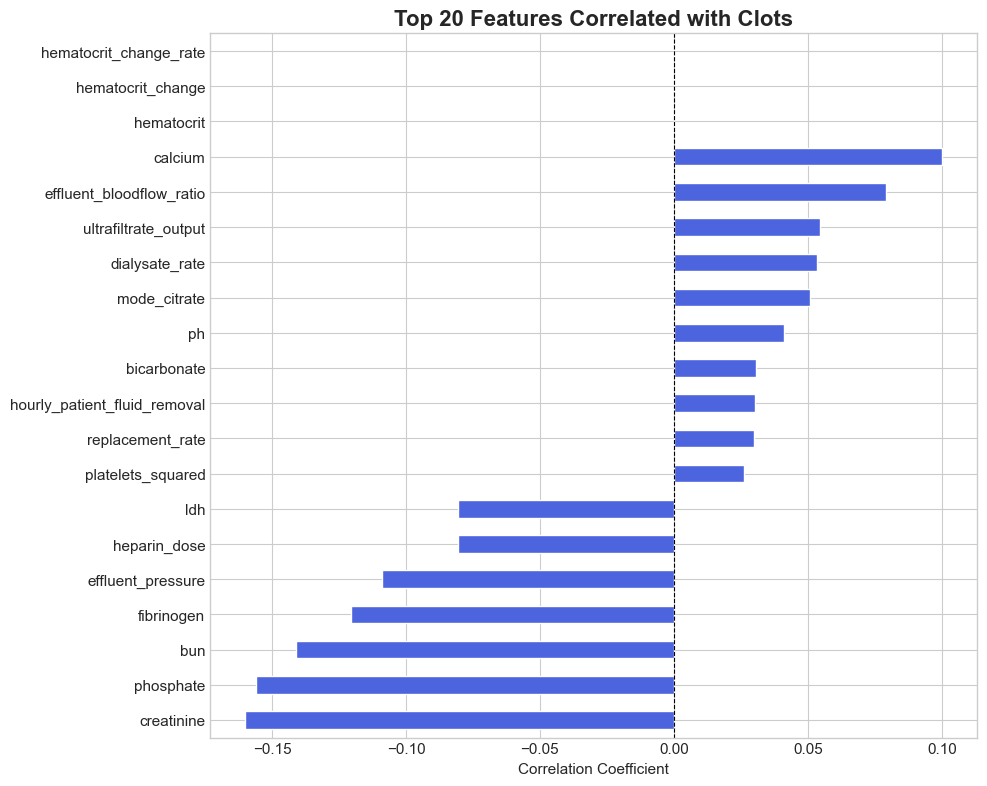

In [57]:
# Correlation analysis with target
print("=" * 60)
print("CORRELATION WITH CLOTS")
print("=" * 60)

# Get numeric columns only
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
df_model = df[numeric_features + [target_col]].copy()

numeric_cols = df_model.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in id_cols]

# Calculate correlations
correlations = df_model[numeric_cols].corr()['clots_corrected'].drop('clots_corrected').sort_values(ascending=False)

print("\nTop 15 positive correlations:")
print(correlations.head(15))

print("\nTop 15 negative correlations:")
print(correlations.tail(15))

# Visualize top correlations
top_corr = pd.concat([correlations.head(10), correlations.tail(10)])
plt.figure(figsize=(10, 8))
top_corr.sort_values().plot(kind='barh', color='#4C64DE')
plt.title('Top 20 Features Correlated with Clots', fontweight='bold', fontsize=16)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# **Model Preparation**

Build models using **labs-only features** (most clinically relevant for early prediction).

To handle class imbalance (~10:1 ratio), we'll use multiple strategies:
1. **Undersampling** - Reduce majority class
2. **SMOTE** - Synthetic minority oversampling
3. **Combined approach** - SMOTE results

## **Train/Test Split & Scaling**

In [58]:
# ================================================================
# TRAIN/TEST SPLIT, IMPUTATION, AND SCALING
# ================================================================

print("="*70)
print("TRAIN/TEST SPLIT, IMPUTATION, AND SCALING")
print("="*70)

# === STEP 0: CREATE MODELING DATAFRAME ===
print("\nSTEP 0: Preparing modeling dataframe")
print("="*70)

# Filter to only numeric features
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"Total features from Cell 34: {len(feature_cols)}")
print(f"Numeric features: {len(numeric_features)}")

if len(numeric_features) < len(feature_cols):
    non_numeric = [col for col in feature_cols if col not in numeric_features]
    print(f"\nNon-numeric features excluded: {non_numeric}")

# Create df_model with numeric features + target
df_model = df[numeric_features + [target_col]].copy()

# Create feature matrix and target
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"Clot rate: {y.mean()*100:.2f}%")

# === STEP 1: TRAIN/TEST SPLIT ===
print("\n" + "="*70)
print("STEP 1: Splitting into train and test sets")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain class balance in both sets
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"Clot rate in train: {y_train.mean()*100:.2f}%")
print(f"\nClass distribution in test set:")
print(y_test.value_counts())
print(f"Clot rate in test: {y_test.mean()*100:.2f}%")

# === STEP 2: IMPUTATION (fit on train only!) ===
print("\n" + "="*70)
print("STEP 2: Imputing missing values")
print("="*70)

# Check missing values before imputation
missing_train_before = X_train.isnull().sum()
missing_test_before = X_test.isnull().sum()

print("\nMissing values in TRAINING set (before imputation):")
if missing_train_before.sum() > 0:
    print(missing_train_before[missing_train_before > 0].sort_values(ascending=False).head(10))
else:
    print("✓ No missing values!")

print("\nMissing values in TEST set (before imputation):")
if missing_test_before.sum() > 0:
    print(missing_test_before[missing_test_before > 0].sort_values(ascending=False).head(10))
else:
    print("✓ No missing values!")

# Create imputer and fit ONLY on training data
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Fit on training data and transform both train and test
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),  # FIT on train
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),  # Only TRANSFORM test (no fitting!)
    columns=X_test.columns,
    index=X_test.index
)

print(f"\n✓ Imputation complete")
print(f"Missing values after imputation:")
print(f"  Training: {X_train_imputed.isnull().sum().sum()}")
print(f"  Test: {X_test_imputed.isnull().sum().sum()}")

# === STEP 3: SCALING (fit on train only!) ===
print("\n" + "="*70)
print("STEP 3: Scaling features")
print("="*70)

scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),  # FIT on train
    columns=X_train_imputed.columns,
    index=X_train_imputed.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),  # Only TRANSFORM test (no fitting!)
    columns=X_test_imputed.columns,
    index=X_test_imputed.index
)

print(f"\n✓ Scaling complete")
print(f"Training set (scaled): {X_train_scaled.shape}")
print(f"Test set (scaled): {X_test_scaled.shape}")

print("\n" + "="*70)
print("✓ READY FOR MODELING")
print("="*70)

TRAIN/TEST SPLIT, IMPUTATION, AND SCALING

STEP 0: Preparing modeling dataframe
Total features from Cell 34: 64
Numeric features: 58

Non-numeric features excluded: ['crrt_mode', 'dialysate_fluid', 'replacement_fluid', 'race', 'line_type', 'line_site']

Feature matrix shape: (125611, 58)
Target vector shape: (125611,)

Target distribution:
clots_corrected
1    113622
0     11989
Name: count, dtype: int64
Clot rate: 90.46%

STEP 1: Splitting into train and test sets

Training set: (100488, 58)
Test set: (25123, 58)

Class distribution in training set:
clots_corrected
1    90897
0     9591
Name: count, dtype: int64
Clot rate in train: 90.46%

Class distribution in test set:
clots_corrected
1    22725
0     2398
Name: count, dtype: int64
Clot rate in test: 90.45%

STEP 2: Imputing missing values

Missing values in TRAINING set (before imputation):
heparin_dose            94167
fibrinogen              79495
ldh                     59473
lactate                 48961
citrate                

## Handling Class Imbalance/Create Resampled Datasets

In [59]:
print("=" * 70)
print("CREATING RESAMPLED TRAINING SETS")
print("=" * 70)

# With better class balance, we can work with full training set
print(f"\nWorking with full training set: {len(y_train):,} samples")

# 1. Random Undersampling
print("\n1. Random Undersampling (50% minority class)...")
rus = RandomUnderSampler(random_state=42, sampling_strategy=0.5)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)
print(f"   After undersampling: {len(y_train_rus):,} samples")
print(f"   Class distribution: {y_train_rus.value_counts().to_dict()}")

# 2. SMOTE (Synthetic Minority Oversampling)
print("\n2. SMOTE (oversample to 30% minority class)...")
smote = SMOTE(random_state=42, sampling_strategy=0.3, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"   After SMOTE: {len(y_train_smote):,} samples")
print(f"   Class distribution: {y_train_smote.value_counts().to_dict()}")

# 3. SMOTETomek (Combined approach - oversample minority, then clean noisy samples)
print("\n3. SMOTETomek (Combined: SMOTE + Tomek Links cleaning)...")
print("   This oversamples the minority class AND removes noisy border samples")
smotetomek = SMOTETomek(random_state=42, sampling_strategy=0.3)
X_train_combined, y_train_combined = smotetomek.fit_resample(X_train_scaled, y_train)
print(f"   After SMOTETomek: {len(y_train_combined):,} samples")
print(f"   Class distribution: {y_train_combined.value_counts().to_dict()}")

print("\n✓ Resampling complete!")
print(f"\nOriginal training set: {len(y_train):,} samples")
print(f"Undersampled: {len(y_train_rus):,} samples ({len(y_train_rus)/len(y_train)*100:.1f}% of original)")
print(f"SMOTE: {len(y_train_smote):,} samples ({len(y_train_smote)/len(y_train)*100:.1f}% of original)")
print(f"Combined (SMOTETomek): {len(y_train_combined):,} samples ({len(y_train_combined)/len(y_train)*100:.1f}% of original)")

# Explanation of the differences
print("\n" + "=" * 70)
print("UNDERSTANDING THE RESAMPLING STRATEGIES")
print("=" * 70)
print("""
1. RANDOM UNDERSAMPLING:
   - Randomly removes samples from majority class
   - Fast and simple
   - Risk: May lose important information
   - Use when: You have abundant data

2. SMOTE (Synthetic Minority Over-sampling Technique):
   - Creates synthetic minority samples by interpolating between neighbors
   - Balances classes without losing majority class data
   - Risk: May create noisy synthetic samples
   - Use when: You want to preserve all real data

3. SMOTETOMEK (COMBINED):
   - First applies SMOTE to create synthetic minority samples
   - Then uses Tomek Links to remove noisy/ambiguous samples from BOTH classes
   - Tomek Links are pairs of opposite-class samples that are each other's
     nearest neighbors - these are hard to classify so we remove them
   - Result: Clean, balanced dataset
   - Use when: You want the best of both worlds (balance + cleanliness)

EXPECTED RESULTS:
- Undersampled will have FEWER samples (loses majority data)
- SMOTE will have MORE samples (adds synthetic data)
- SMOTETomek will have slightly FEWER samples than SMOTE (removes noise)
""")

CREATING RESAMPLED TRAINING SETS

Working with full training set: 100,488 samples

1. Random Undersampling (50% minority class)...
   After undersampling: 28,773 samples
   Class distribution: {1: 19182, 0: 9591}

2. SMOTE (oversample to 30% minority class)...
   After SMOTE: 118,166 samples
   Class distribution: {1: 90897, 0: 27269}

3. SMOTETomek (Combined: SMOTE + Tomek Links cleaning)...
   This oversamples the minority class AND removes noisy border samples
   After SMOTETomek: 118,022 samples
   Class distribution: {1: 90825, 0: 27197}

✓ Resampling complete!

Original training set: 100,488 samples
Undersampled: 28,773 samples (28.6% of original)
SMOTE: 118,166 samples (117.6% of original)
Combined (SMOTETomek): 118,022 samples (117.4% of original)

UNDERSTANDING THE RESAMPLING STRATEGIES

1. RANDOM UNDERSAMPLING:
   - Randomly removes samples from majority class
   - Fast and simple
   - Risk: May lose important information
   - Use when: You have abundant data

2. SMOTE (Synth

# **Model Training and Evaluation**

Training models on:
1. Original imbalanced data (baseline)
2. Undersampled data
3. SMOTE data
4. Combined (SMOTE)
# for my own knowledge: https://www.youtube.com/watch?v=1Ic7GRtDrPM

## Logistic Regression

In [60]:
print("=" * 70)
print("TRAINING LOGISTIC REGRESSION MODELS")
print("=" * 70)

# Dictionary to store models and results
lr_models = {}
lr_results = {}

# Define training sets
training_sets = {
    'Original (Imbalanced)': (X_train_scaled, y_train),
    'Undersampled': (X_train_rus, y_train_rus),
    'SMOTE': (X_train_smote, y_train_smote),
    'Combined': (X_train_combined, y_train_combined)
}

# Train models
for name, (X_tr, y_tr) in training_sets.items():
    print(f"\n{'='*70}")
    print(f"Training: {name}")
    print(f"{'='*70}")

    # Train
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_tr, y_tr)

    # Predict on TEST set (always use original imbalanced test set)
    y_pred = lr.predict(X_test_scaled)
    y_prob = lr.predict_proba(X_test_scaled)[:, 1]

    # Store
    lr_models[name] = lr
    lr_results[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test, y_prob)
    }

    # Print results
    print("\nTest Set Performance:")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC-AUC: {lr_results[name]['roc_auc']:.4f}")
    print(f"Average Precision: {lr_results[name]['avg_precision']:.4f}")

print("\n" + "="*70)
print("✓ All Logistic Regression models trained!")
print("="*70)

TRAINING LOGISTIC REGRESSION MODELS

Training: Original (Imbalanced)

Test Set Performance:
              precision    recall  f1-score   support

           0      0.475     0.039     0.072      2398
           1      0.908     0.995     0.949     22725

    accuracy                          0.904     25123
   macro avg      0.691     0.517     0.511     25123
weighted avg      0.866     0.904     0.866     25123

ROC-AUC: 0.7597
Average Precision: 0.9634

Training: Undersampled

Test Set Performance:
              precision    recall  f1-score   support

           0      0.313     0.412     0.356      2398
           1      0.936     0.905     0.920     22725

    accuracy                          0.858     25123
   macro avg      0.624     0.658     0.638     25123
weighted avg      0.876     0.858     0.866     25123

ROC-AUC: 0.7752
Average Precision: 0.9661

Training: SMOTE

Test Set Performance:
              precision    recall  f1-score   support

           0      0.368     

Feature Importance Analysis - Logistic Regression

FEATURE IMPORTANCE - Logistic Regression (Undersampled)

Top 20 Most Important Features:
                   Feature  Coefficient
           filter_pressure    10.569084
prefilter_replacement_rate    -5.018915
 hct_bloodflow_interaction    -1.305603
                blood_flow     1.298062
           access_pressure     0.867511
           return_pressure    -0.499079
  effluent_bloodflow_ratio     0.493925
         effluent_pressure    -0.491763
       filtration_fraction    -0.427016
      ultrafiltrate_output     0.407915
         platelets_squared     0.346014
                 phosphate    -0.264947
                   calcium     0.261693
                       rbc    -0.255514
                  platelet    -0.208863
                       ptt    -0.201822
                  chloride     0.179941
       flow_pressure_ratio     0.155998
                fibrinogen    -0.132522
                    sodium    -0.130343


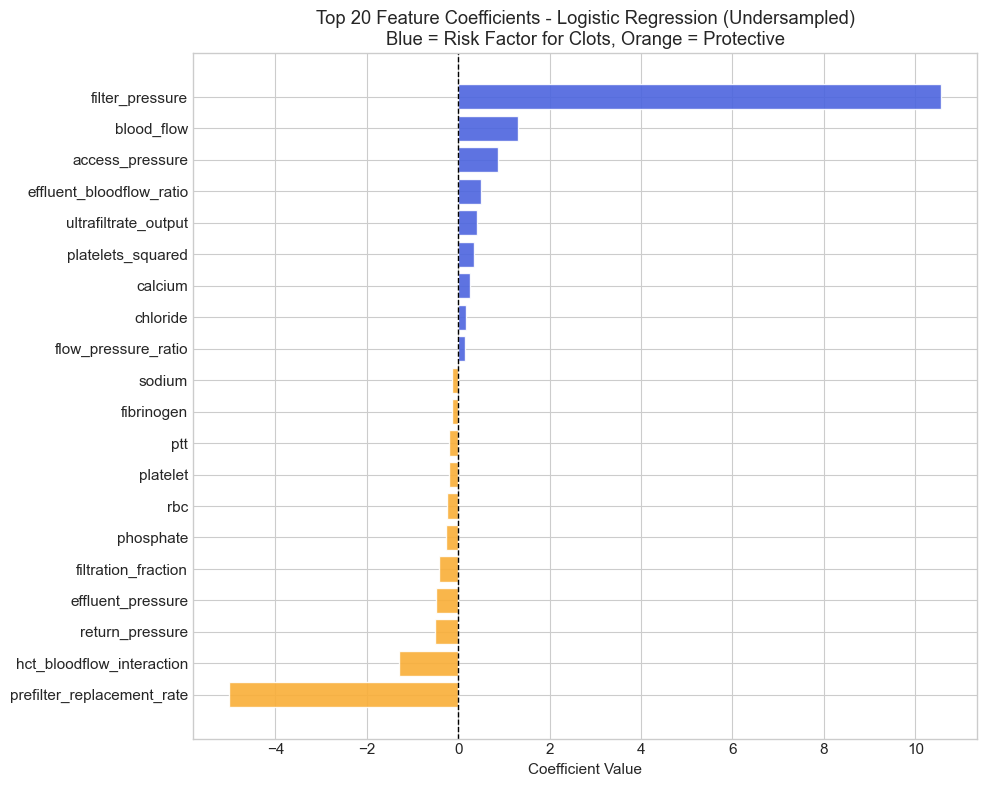

In [61]:
# Feature importance from best Logistic Regression model
best_lr_name = max(lr_results.keys(), key=lambda k: lr_results[k]['avg_precision'])
best_lr = lr_models[best_lr_name]

print("=" * 70)
print(f"FEATURE IMPORTANCE - Logistic Regression ({best_lr_name})")
print("=" * 70)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop 20 Most Important Features:")
print(coef_df.head(20).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))

top_features = coef_df.head(20).sort_values('Coefficient')

# NEW COLORS: blue for positive, orange for negative
colors = ['#4C64DE' if coef > 0 else '#F9AE37' for coef in top_features['Coefficient']]

plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.9)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title(
    f'Top 20 Feature Coefficients - Logistic Regression ({best_lr_name})\n'
    'Blue = Risk Factor for Clots, Orange = Protective'
)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

## Random Forest

In [62]:
print("=" * 70)
print("TRAINING RANDOM FOREST MODELS")
print("=" * 70)

# Dictionary to store models and results
rf_models = {}
rf_results = {}

# Train models
for name, (X_tr, y_tr) in training_sets.items():
    print(f"\n{'='*70}")
    print(f"Training: {name}")
    print(f"{'='*70}")

    # Train
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_tr, y_tr)

    # Predict on TEST set
    y_pred = rf.predict(X_test_scaled)
    y_prob = rf.predict_proba(X_test_scaled)[:, 1]

    # Store
    rf_models[name] = rf
    rf_results[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test, y_prob)
    }

    # Print results
    print("\nTest Set Performance:")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC-AUC: {rf_results[name]['roc_auc']:.4f}")
    print(f"Average Precision: {rf_results[name]['avg_precision']:.4f}")

print("\n" + "="*70)
print("✓ All Random Forest models trained!")
print("="*70)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop 20 Most Important Features:")
print(coef_df.head(20).to_string(index=False))

TRAINING RANDOM FOREST MODELS

Training: Original (Imbalanced)

Test Set Performance:
              precision    recall  f1-score   support

           0      0.996     0.229     0.373      2398
           1      0.925     1.000     0.961     22725

    accuracy                          0.926     25123
   macro avg      0.961     0.615     0.667     25123
weighted avg      0.932     0.926     0.905     25123

ROC-AUC: 0.9284
Average Precision: 0.9899

Training: Undersampled

Test Set Performance:
              precision    recall  f1-score   support

           0      0.792     0.574     0.666      2398
           1      0.956     0.984     0.970     22725

    accuracy                          0.945     25123
   macro avg      0.874     0.779     0.818     25123
weighted avg      0.941     0.945     0.941     25123

ROC-AUC: 0.9412
Average Precision: 0.9926

Training: SMOTE

Test Set Performance:
              precision    recall  f1-score   support

           0      0.955     0.434 

## XG Boost

In [63]:
# ================================================================
# TRAIN/TEST SPLIT WITH SELECTIVE IMPUTATION FOR XGBOOST
# ================================================================
# NOTE: We skip imputation for citrate and heparin_dose because
# XGBoost handles NaN natively by learning optimal split directions.
# This preserves the structured missingness from anticoag mode.
# ================================================================

print("=" * 70)
print("TRAIN/TEST SPLIT WITH SELECTIVE IMPUTATION")
print("=" * 70)

# Get numeric features (exclude categorical anticoagulation_mode)
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
if 'anticoagulation_mode' in numeric_features:
    numeric_features.remove('anticoagulation_mode')

print(f"\nNumeric features: {len(numeric_features)}")

# Create X and y
X = df[numeric_features].copy()
y = df[target_col].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# SELECTIVE IMPUTATION: Skip citrate and heparin_dose
# XGBoost handles NaN natively - this is BETTER than median imputation
# for structurally missing data
anticoag_vars = ['citrate', 'heparin_dose']
cols_to_impute = [c for c in X_train.columns if c not in anticoag_vars]

print(f"\nImputing {len(cols_to_impute)} columns (skipping anticoag vars)...")

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

X_train_imp = X_train.copy()
X_test_imp = X_test.copy()

X_train_imp[cols_to_impute] = imputer.fit_transform(X_train[cols_to_impute])
X_test_imp[cols_to_impute] = imputer.transform(X_test[cols_to_impute])

# Verify anticoag NaNs preserved
print(f"\nAnticoag NaNs preserved (training):")
for var in anticoag_vars:
    if var in X_train_imp.columns:
        nan_pct = X_train_imp[var].isna().mean() * 100
        print(f"  {var}: {nan_pct:.1f}% NaN")

# Scale (optional for XGBoost, but keeping for consistency)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scale non-anticoag columns only
X_train_scaled = X_train_imp.copy()
X_test_scaled = X_test_imp.copy()

X_train_scaled[cols_to_impute] = scaler.fit_transform(X_train_imp[cols_to_impute])
X_test_scaled[cols_to_impute] = scaler.transform(X_test_imp[cols_to_impute])

print(f"\n✓ Data ready for XGBoost (with native NaN handling)")
print("=" * 70)


TRAIN/TEST SPLIT WITH SELECTIVE IMPUTATION

Numeric features: 58
Feature matrix shape: (125611, 58)
Target distribution: {1: 113622, 0: 11989}

Training set: (100488, 58)
Test set: (25123, 58)

Imputing 56 columns (skipping anticoag vars)...

Anticoag NaNs preserved (training):
  citrate: 38.4% NaN
  heparin_dose: 93.7% NaN

✓ Data ready for XGBoost (with native NaN handling)


In [64]:
# ================================================================
# TRAIN XGBOOST
# ================================================================

print("=" * 70)
print("TRAINING XGBOOST MODEL (NO OVERSAMPLING)")
print("=" * 70)

from xgboost import XGBClassifier

# Calculate imbalance weight for minority class (0 = clots)
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance weight (scale_pos_weight): {scale_weight:.2f}")

# -----------------------------------------
# Train XGBoost on the original dataset
# -----------------------------------------
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

print("\nFitting XGBoost on original (imbalanced) dataset...")
xgb.fit(X_train_scaled, y_train)

# -----------------------------------------
# Prediction on TEST SET
# -----------------------------------------
y_pred = xgb.predict(X_test_scaled)
y_prob = xgb.predict_proba(X_test_scaled)[:, 1]

# -----------------------------------------
# Evaluation
# -----------------------------------------
print("\nTest Set Performance:")
print(classification_report(y_test, y_pred, digits=3))

xgb_auc = roc_auc_score(y_test, y_prob)
xgb_ap = average_precision_score(y_test, y_prob)

print(f"ROC-AUC:           {xgb_auc:.4f}")
print(f"Average Precision: {xgb_ap:.4f}")

print("\n" + "="*70)
print("✓ XGBoost training complete!")
print("="*70)

# Store results for comparison
xgb_results = {
    "original": {
        "model": xgb,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "roc_auc": xgb_auc,
        "avg_precision": xgb_ap
    }
}

print("\n" + "="*70)
print("XGBOOST (ORIGINAL) vs RANDOM FOREST (SMOTE)")
print("="*70)

rf_auc = rf_results["SMOTE"]["roc_auc"]
rf_ap  = rf_results["SMOTE"]["avg_precision"]

xgb_auc = xgb_results["original"]["roc_auc"]
xgb_ap  = xgb_results["original"]["avg_precision"]

print(f"\nRandom Forest (SMOTE) AUC: {rf_auc:.4f}")
print(f"XGBoost (Original) AUC:     {xgb_auc:.4f}")
print(f"Difference:                 {xgb_auc - rf_auc:+.4f} "
      f"{'✓ XGBoost wins!' if xgb_auc > rf_auc else '✗ RF wins'}")

print(f"\nRandom Forest (SMOTE) Avg Precision: {rf_ap:.4f}")
print(f"XGBoost (Original) Avg Precision:     {xgb_ap:.4f}")
print(f"Difference:                          {xgb_ap - rf_ap:+.4f} "
      f"{'✓ XGBoost wins!' if xgb_ap > rf_ap else '✗ RF wins'}")

# Extract feature names
feature_names = X_train_scaled.columns

# Extract importance scores (gain = best metric)
importances = xgb.get_booster().get_score(importance_type='gain')

# Convert dict → DataFrame
importance_df = pd.DataFrame([
    {"feature": k, "importance": v} for k, v in importances.items()
])

# Sort by importance
importance_df = importance_df.sort_values(by="importance", ascending=False)

# Display top 20
print("\nTop 20 XGBoost Feature Importances (by GAIN):")
print(importance_df.head(60).to_string(index=False))



TRAINING XGBOOST MODEL (NO OVERSAMPLING)

Class imbalance weight (scale_pos_weight): 0.11

Fitting XGBoost on original (imbalanced) dataset...

Test Set Performance:
              precision    recall  f1-score   support

           0      0.845     0.917     0.880      2398
           1      0.991     0.982     0.987     22725

    accuracy                          0.976     25123
   macro avg      0.918     0.950     0.933     25123
weighted avg      0.977     0.976     0.977     25123

ROC-AUC:           0.9880
Average Precision: 0.9984

✓ XGBoost training complete!

XGBOOST (ORIGINAL) vs RANDOM FOREST (SMOTE)

Random Forest (SMOTE) AUC: 0.9406
XGBoost (Original) AUC:     0.9880
Difference:                 +0.0474 ✓ XGBoost wins!

Random Forest (SMOTE) Avg Precision: 0.9920
XGBoost (Original) Avg Precision:     0.9984
Difference:                          +0.0064 ✓ XGBoost wins!

Top 20 XGBoost Feature Importances (by GAIN):
                     feature  importance
                mod

RETRAINING XGBOOST ON TOP 10 FEATURES

1. Extracting top 10 features from original XGBoost model...

✓ Top 10 Most Important Features:
 1. mode_citrate                   0.0654
 2. blood_flow                     0.0607
 3. fibrinogen                     0.0349
 4. phosphate                      0.0320
 5. effluent_pressure              0.0272
 6. prefilter_replacement_rate     0.0257
 7. heparin_dose                   0.0255
 8. filter_pressure                0.0240
 9. creatinine                     0.0221
10. citrate                        0.0216

Top 10 features account for 33.9% of total importance

2. Creating reduced feature sets...

Original training set: (100488, 58)
Reduced training set: (100488, 20)
Features reduced: 58 → 20 (34% kept)

Top 10 features:
   1. mode_citrate
   2. blood_flow
   3. fibrinogen
   4. phosphate
   5. effluent_pressure
   6. prefilter_replacement_rate
   7. heparin_dose
   8. filter_pressure
   9. creatinine
  10. citrate
  11. platelets_squared
  12

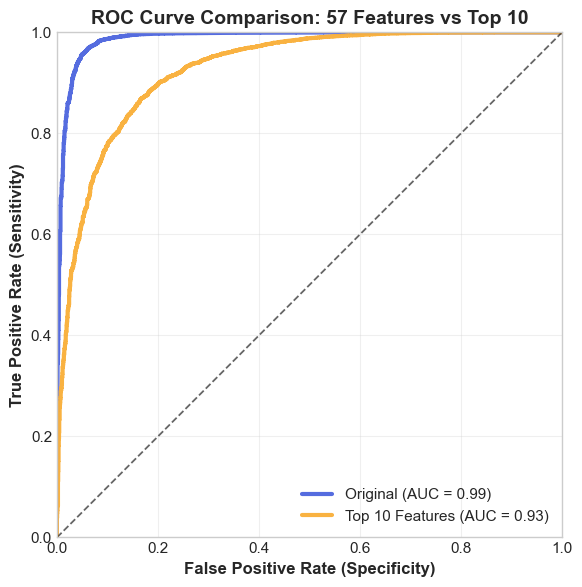

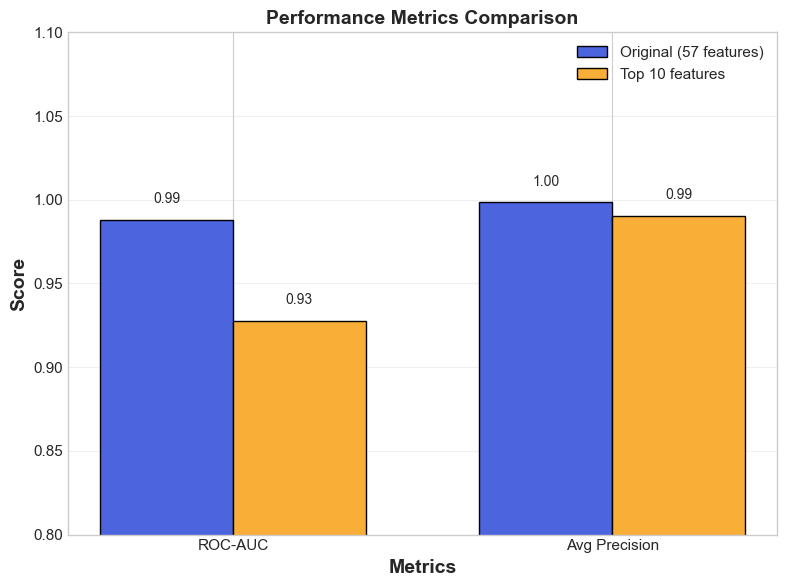

<Figure size 700x600 with 0 Axes>

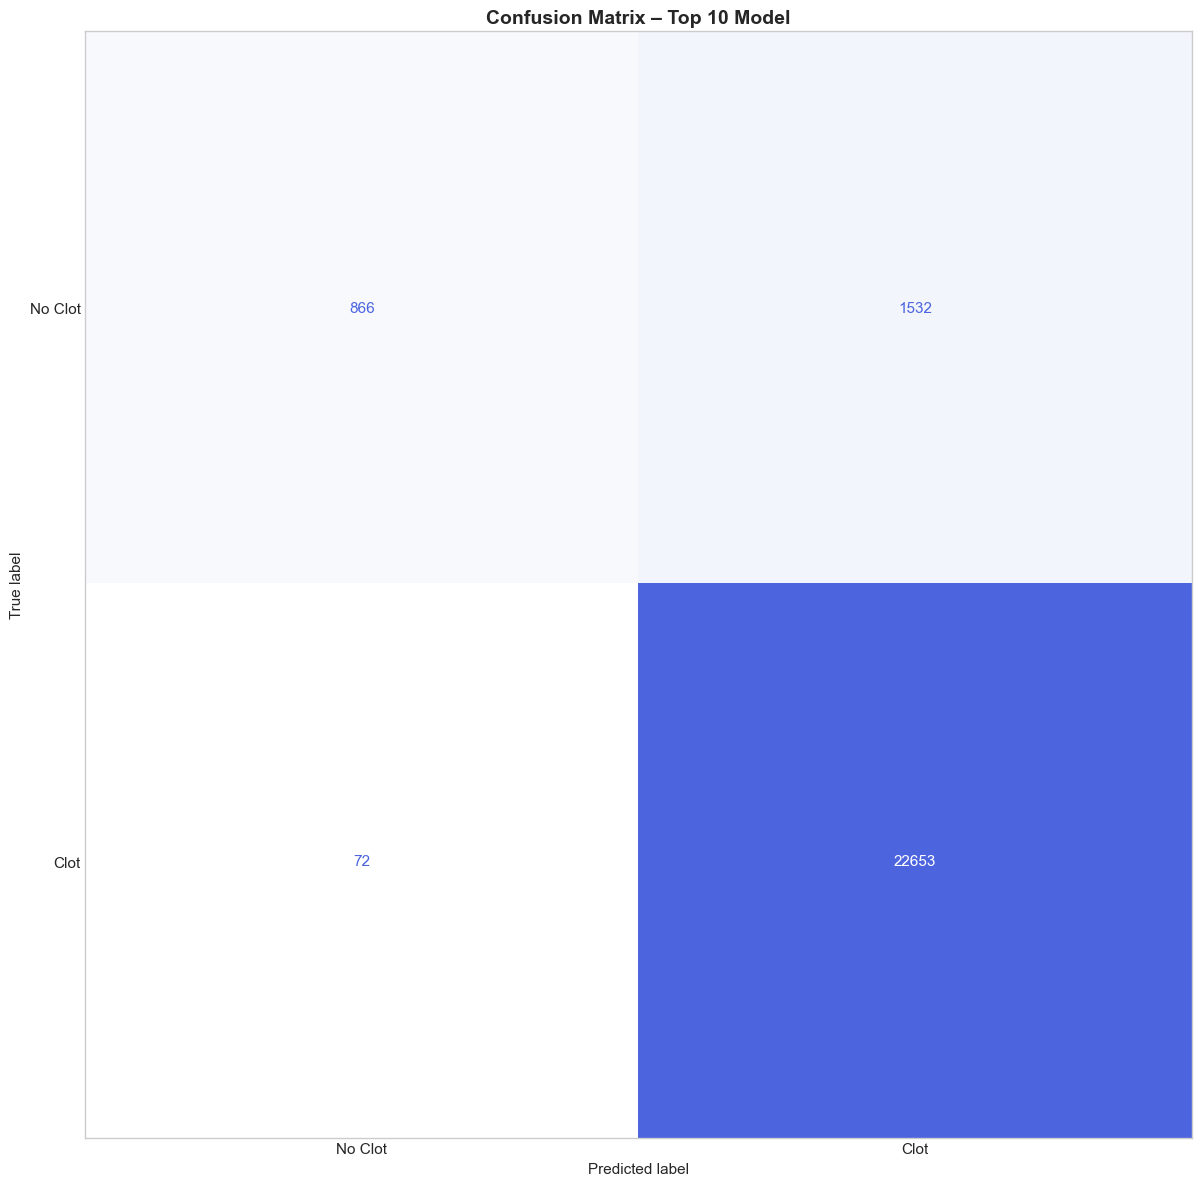

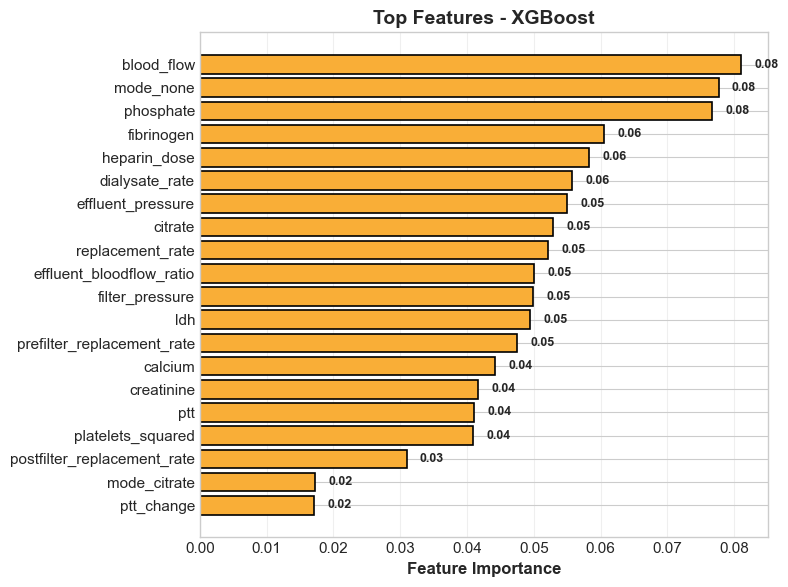


8. DEPLOYMENT FEASIBILITY ASSESSMENT

📋 FEATURE LIST FOR CLINICAL INTERFACE:
--------------------------------------------------------------------------------
 1. mode_citrate
 2. blood_flow
 3. fibrinogen
 4. phosphate
 5. effluent_pressure
 6. prefilter_replacement_rate
 7. heparin_dose
 8. filter_pressure
 9. creatinine
10. citrate
11. platelets_squared
12. effluent_bloodflow_ratio
13. replacement_rate
14. postfilter_replacement_rate
15. ldh
16. mode_none
17. ptt
18. dialysate_rate
19. calcium
20. ptt_change

⏱️ ESTIMATED MANUAL ENTRY TIME:
   • 20 features × ~15 seconds = ~5.0 minutes
   • Realistic for bedside use: ⚠️ BORDERLINE

📊 PERFORMANCE TRADE-OFF:
   • Features reduced: 57 → 20 (64.9% reduction)
   • AUC retained: 93.89%
   • Absolute AUC loss: 0.0604

🎯 VERDICT: ⚠️ CONSIDER MORE FEATURES
   Rationale: Performance loss of 6.0% may be clinically significant

💡 NEXT STEPS:
   1. ⚠️ Test with 15 or 20 top features instead
   2. ⚠️ Evaluate if additional features improve perfor

In [65]:
# ============================================================================
# RETRAIN XGBOOST ON TOP 10 FEATURES ONLY
# Testing if we can maintain good performance with fewer features for deployment
# ============================================================================

print("=" * 80)
print("RETRAINING XGBOOST ON TOP 10 FEATURES")
print("=" * 80)

# ============================================================================
# STEP 1: IDENTIFY TOP 10 FEATURES FROM YOUR EXISTING MODEL
# ============================================================================

print("\n1. Extracting top 10 features from original XGBoost model...")

# Get your best XGBoost model (trained on all 57 features)
best_xgb_original = xgb_results['original']['model']

# Get feature importances
feature_names = X_train_scaled.columns.tolist()
importances = best_xgb_original.feature_importances_

# Create DataFrame and sort
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Select top 10 features
TOP_10_FEATURES = feature_importance_df.head(20)['Feature'].tolist()

print("\n✓ Top 10 Most Important Features:")
print("=" * 80)
for i, (idx, row) in enumerate(feature_importance_df.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['Feature']:<30s} {row['Importance']:.4f}")

print(f"\nTop 10 features account for {feature_importance_df.head(10)['Importance'].sum():.1%} of total importance")

# ============================================================================
# STEP 2: CREATE REDUCED TRAINING/TEST SETS WITH ONLY TOP 10 FEATURES
# ============================================================================

print("\n" + "=" * 80)
print("2. Creating reduced feature sets...")
print("=" * 80)

# Select only top 10 features from your scaled data
X_train_top10 = X_train_scaled[TOP_10_FEATURES]
X_test_top10 = X_test_scaled[TOP_10_FEATURES]

print(f"\nOriginal training set: {X_train_scaled.shape}")
print(f"Reduced training set: {X_train_top10.shape}")
print(f"Features reduced: {X_train_scaled.shape[1]} → {X_train_top10.shape[1]} ({X_train_top10.shape[1]/X_train_scaled.shape[1]*100:.0f}% kept)")

print(f"\nTop 10 features:")
for i, feat in enumerate(TOP_10_FEATURES, 1):
    print(f"  {i:2d}. {feat}")

# ============================================================================
# STEP 3: TRAIN NEW XGBOOST MODEL ON TOP 10 FEATURES
# ============================================================================

print("\n" + "=" * 80)
print("3. Training XGBoost on top 10 features...")
print("=" * 80)

# Train with same hyperparameters as original
xgb_top10 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_top10.fit(X_train_top10, y_train)

print("✓ Training complete!")

# ============================================================================
# STEP 4: EVALUATE PERFORMANCE
# ============================================================================

print("\n" + "=" * 80)
print("4. Evaluating performance...")
print("=" * 80)

# Make predictions
y_pred_top10 = xgb_top10.predict(X_test_top10)
y_prob_top10 = xgb_top10.predict_proba(X_test_top10)[:, 1]

# Calculate metrics
auc_top10 = roc_auc_score(y_test, y_prob_top10)
ap_top10 = average_precision_score(y_test, y_prob_top10)

# Get original model performance for comparison
y_prob_original = xgb_results['original']['y_prob']
auc_original = xgb_results['original']['roc_auc']
ap_original = xgb_results['original']['avg_precision']

print("\nPERFORMANCE COMPARISON:")
print("=" * 80)
print(f"{'Model':<30s} {'Features':>10s} {'ROC-AUC':>12s} {'Avg Precision':>15s}")
print("-" * 80)
print(f"{'Original (57 features)':<30s} {57:>10d} {auc_original:>12.4f} {ap_original:>15.4f}")
print(f"{'Reduced (10 features)':<30s} {10:>10d} {auc_top10:>12.4f} {ap_top10:>15.4f}")
print("-" * 80)
print(f"{'Performance Loss':<30s} {'-47':>10s} {auc_top10-auc_original:>12.4f} {ap_top10-ap_original:>15.4f}")
print(f"{'Percentage Change':<30s} {'':>10s} {(auc_top10/auc_original-1)*100:>11.2f}% {(ap_top10/ap_original-1)*100:>14.2f}%")

# Calculate performance retention
retention_pct = (auc_top10 / auc_original) * 100

print(f"\n📊 KEY FINDINGS:")
print(f"   • Performance retention: {retention_pct:.2f}%")
print(f"   • Feature reduction: 82.5% (57 → 10 features)")

if (auc_original - auc_top10) < 0.02:  # Less than 2% loss
    print(f"   ✅ EXCELLENT: Minimal performance loss (<2%)")
    print(f"   → Realistic for manual entry deployment!")
elif (auc_original - auc_top10) < 0.05:  # Less than 5% loss
    print(f"   ✓ GOOD: Acceptable performance loss (<5%)")
    print(f"   → Viable for deployment with proper validation")
else:
    print(f"   ⚠️ SIGNIFICANT: Performance loss >{(auc_original - auc_top10)*100:.1f}%")
    print(f"   → May need more features or different approach")

# ============================================================================
# STEP 5: DETAILED CLASSIFICATION REPORT
# ============================================================================

print("\n" + "=" * 80)
print("5. Classification Report (Top 10 Features Model)")
print("=" * 80)

print("\n" + classification_report(y_test, y_pred_top10, 
                                    target_names=['No Clot', 'Clot'],
                                    digits=3))

# ============================================================================
# STEP 6: VISUALIZATIONS  (UPDATED COLORS)
# ============================================================================

# Brand colors
blue = '#4C64DE'
orange = '#F9AE37'
red = '#FF4631'

# ============================================================
# FIGURE 1 — ROC CURVE: 57 FEATURES vs TOP 10 (ONE FIG)
# ============================================================

plt.figure(figsize=(8, 6))
ax = plt.gca()  # <<— force both ROC curves on SAME axes

# Original model
RocCurveDisplay.from_predictions(
    y_test, y_prob_original,
    ax=ax,
    name=f'Original',
    color=blue, linewidth=3, alpha=0.95
)

# Top-10-feature model
RocCurveDisplay.from_predictions(
    y_test, y_prob_top10,
    ax=ax,
    name=f'Top 10 Features',
    color=orange, linewidth=3, alpha=0.95
)

# Chance line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.3, alpha=0.6)

# Labels / formatting
ax.set_title("ROC Curve Comparison: 57 Features vs Top 10", fontsize=14, fontweight='bold')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(alpha=0.3)
ax.legend(fontsize=11, loc="lower right")

ax.set_xlabel("False Positive Rate (Specificity)", fontsize=12, fontweight='bold')
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()




# ============================================================
# FIGURE 2 — METRIC BAR CHART
# ============================================================

plt.figure(figsize=(8, 6))

metrics_names = ['ROC-AUC', 'Avg Precision']
x = np.arange(len(metrics_names))
width = 0.35

plt.bar(x - width/2, [auc_original, ap_original], width,
        label='Original (57 features)', color=blue, edgecolor='black')
plt.bar(x + width/2, [auc_top10, ap_top10], width,
        label='Top 10 features', color=orange, edgecolor='black')

plt.xlabel("Metrics",fontsize=14, fontweight='bold')
plt.ylabel("Score", fontsize=14, fontweight='bold')
plt.xticks(x, metrics_names)
plt.ylim(0.80, 1.10) 
plt.title("Performance Metrics Comparison", fontsize=14, fontweight='bold')
plt.legend()

# Value labels
for i, val in enumerate([auc_original, ap_original]):
    plt.text(i - width/2, val + 0.01, f"{val:.2f}", ha='center', fontsize=10)

for i, val in enumerate([auc_top10, ap_top10]):
    plt.text(i + width/2, val + 0.01, f"{val:.2f}", ha='center', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



# ============================================================
# FIGURE 3 — CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(7, 6))

cm_top10 = confusion_matrix(y_test, y_pred_top10)  

cmap_blue = LinearSegmentedColormap.from_list('cm_blue', ['white', blue])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_top10,
                              display_labels=['No Clot','Clot'])
disp.plot(cmap=cmap_blue, values_format='d', colorbar=False)
plt.title("Confusion Matrix – Top 10 Model", fontsize=14, fontweight='bold')

plt.grid(False)
plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 4 — FEATURE IMPORTANCE (TOP 10 MODEL)
# ============================================================

plt.figure(figsize=(8, 6))

new_importances = xgb_top10.feature_importances_

importance_df_top10 = pd.DataFrame({
    'Feature': TOP_10_FEATURES,
    'Importance': new_importances
}).sort_values('Importance', ascending=True)

plt.barh(
    importance_df_top10['Feature'],
    importance_df_top10['Importance'],
    color=orange, edgecolor='black', linewidth=1.2
)

plt.xlabel("Feature Importance", fontsize=12, fontweight='bold')
plt.title("Top Features - XGBoost", fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Value labels
for idx, val in enumerate(importance_df_top10['Importance']):
    plt.text(val + 0.002, idx, f"{val:.2f}",
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()



# ============================================================================
# STEP 7: DEPLOYMENT FEASIBILITY ASSESSMENT
# ============================================================================

print("\n" + "=" * 80)
print("8. DEPLOYMENT FEASIBILITY ASSESSMENT")
print("=" * 80)

print("\n📋 FEATURE LIST FOR CLINICAL INTERFACE:")
print("-" * 80)
for i, feat in enumerate(TOP_10_FEATURES, 1):
    print(f"{i:2d}. {feat}")

print("\n⏱️ ESTIMATED MANUAL ENTRY TIME:")
print(f"   • {len(TOP_10_FEATURES)} features × ~15 seconds = ~{len(TOP_10_FEATURES)*15/60:.1f} minutes")
print(f"   • Realistic for bedside use: {'✅ YES' if len(TOP_10_FEATURES) <= 15 else '⚠️ BORDERLINE' if len(TOP_10_FEATURES) <= 20 else '❌ TOO MANY'}")

print("\n📊 PERFORMANCE TRADE-OFF:")
print(f"   • Features reduced: {57} → {len(TOP_10_FEATURES)} ({(1-len(TOP_10_FEATURES)/57)*100:.1f}% reduction)")
print(f"   • AUC retained: {retention_pct:.2f}%")
print(f"   • Absolute AUC loss: {auc_original - auc_top10:.4f}")

if (auc_original - auc_top10) < 0.02:
    verdict = "✅ RECOMMENDED FOR DEPLOYMENT"
    reason = "Minimal performance loss (<2%) with major reduction in data collection burden"
elif (auc_original - auc_top10) < 0.05:
    verdict = "✓ ACCEPTABLE FOR DEPLOYMENT"
    reason = "Reasonable performance loss (<5%) with significant usability improvement"
else:
    verdict = "⚠️ CONSIDER MORE FEATURES"
    reason = f"Performance loss of {(auc_original-auc_top10)*100:.1f}% may be clinically significant"

print(f"\n🎯 VERDICT: {verdict}")
print(f"   Rationale: {reason}")

print("\n💡 NEXT STEPS:")
if (auc_original - auc_top10) < 0.05:
    print("   1. ✅ Update Streamlit app to collect these 10 features")
    print("   2. ✅ Use this retrained model (xgboost_top10_model.pkl)")
    print("   3. ✅ Test with clinical stakeholders")
    print("   4. ✅ Proceed with pilot deployment")
else:
    print("   1. ⚠️ Test with 15 or 20 top features instead")
    print("   2. ⚠️ Evaluate if additional features improve performance enough to justify burden")
    print("   3. ⚠️ Consider hybrid approach: 10 required + 5 optional features")

FEATURE ENGINEERING VALUE ANALYSIS

Original features: 38
Engineered features: 20
  - Temporal/Rate-of-Change: 8
  - Interactions/Ratios: 9
  - Mode Encoding: 3


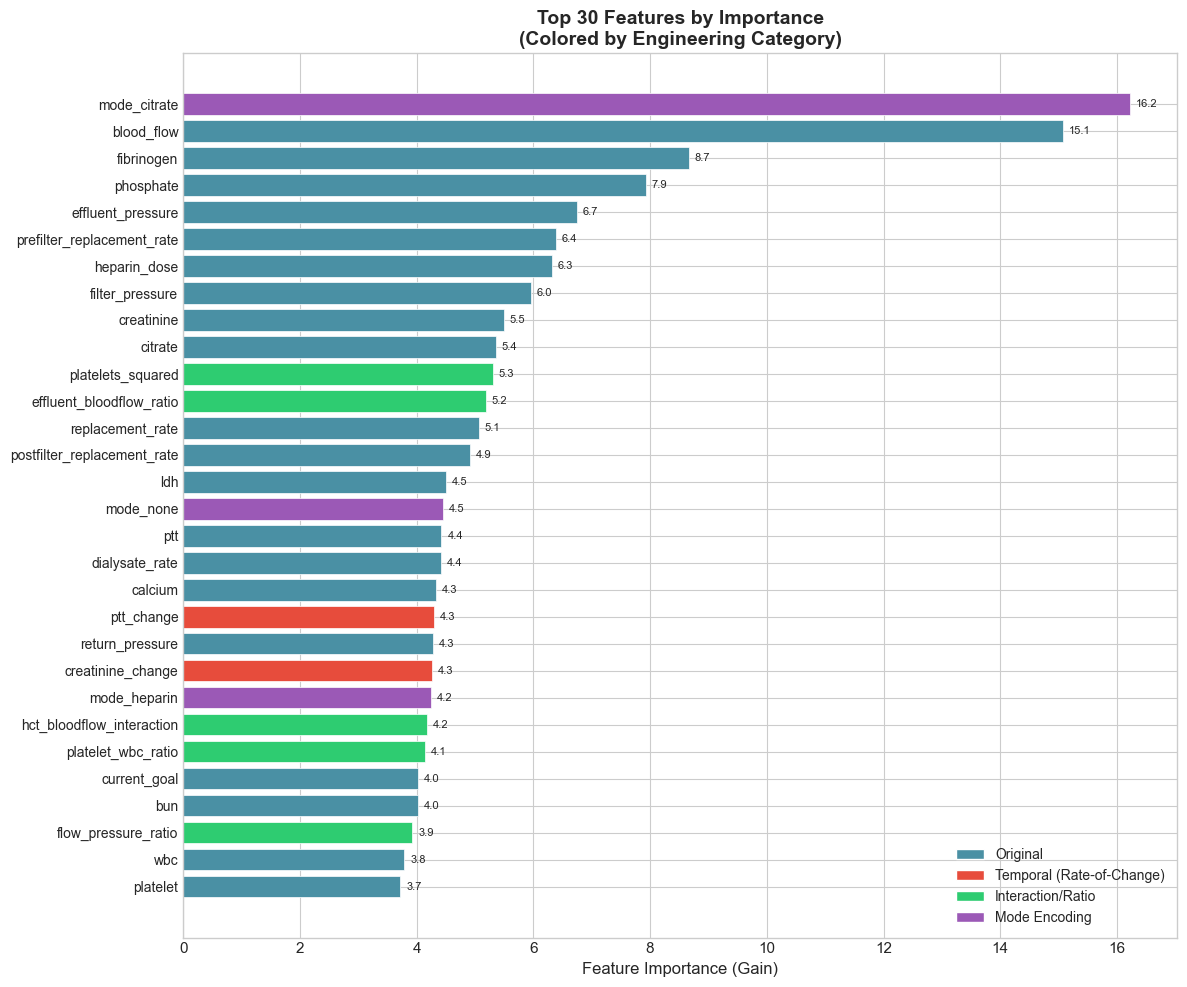


✓ Figure 1 saved: fig1_feature_importance_by_category.png


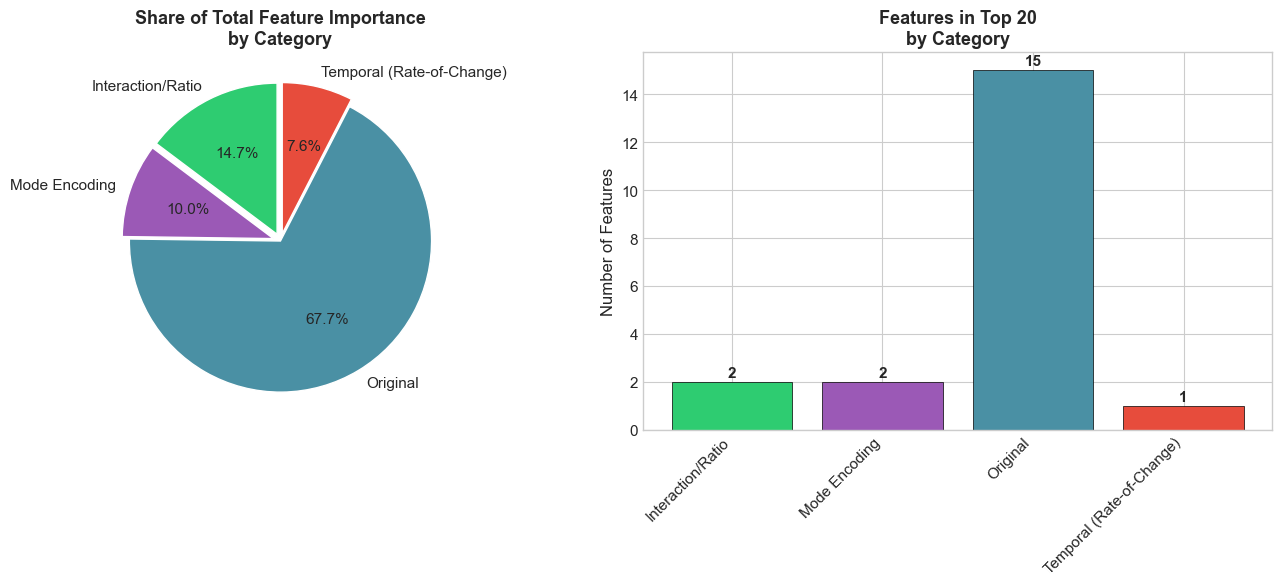

✓ Figure 2 saved: fig2_engineered_contribution.png


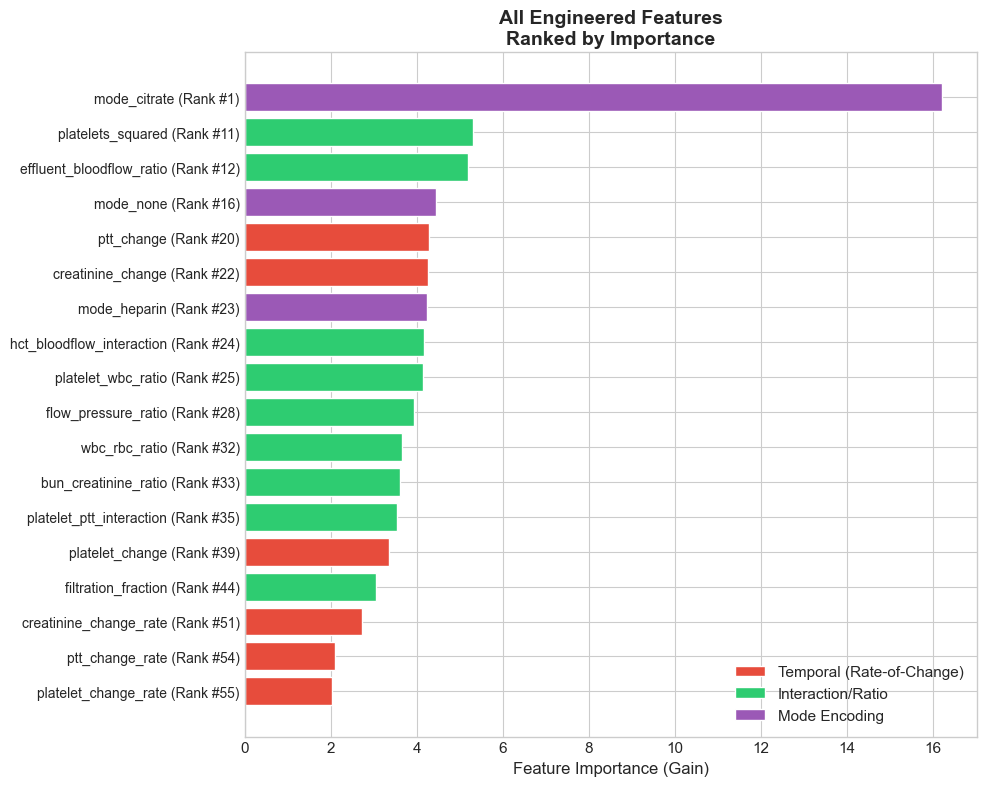

✓ Figure 3 saved: fig3_engineered_features_detail.png

ABLATION STUDY: Model Performance WITH vs WITHOUT Engineered Features

Using 38 original features
Using 20 engineered features

Training model with ONLY original features...
Training model with ALL features (original + engineered)...

ROC-AUC with Original Features Only:  0.9880
ROC-AUC with All Features:            0.9880
Improvement from Engineered Features: +0.0000 (0.00%)
DEBUGGING FEATURE SETS

Total features in X_train_scaled: 58

All columns in X_train_scaled:
['access_pressure', 'blood_flow', 'citrate', 'current_goal', 'dialysate_rate', 'effluent_pressure', 'filter_pressure', 'heparin_dose', 'hourly_patient_fluid_removal', 'prefilter_replacement_rate', 'postfilter_replacement_rate', 'replacement_rate', 'return_pressure', 'ultrafiltrate_output', 'hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc', 'fibrinogen', 'inr', 'pt', 'ptt', 'aniongap', 'bicarbonate', 'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'p

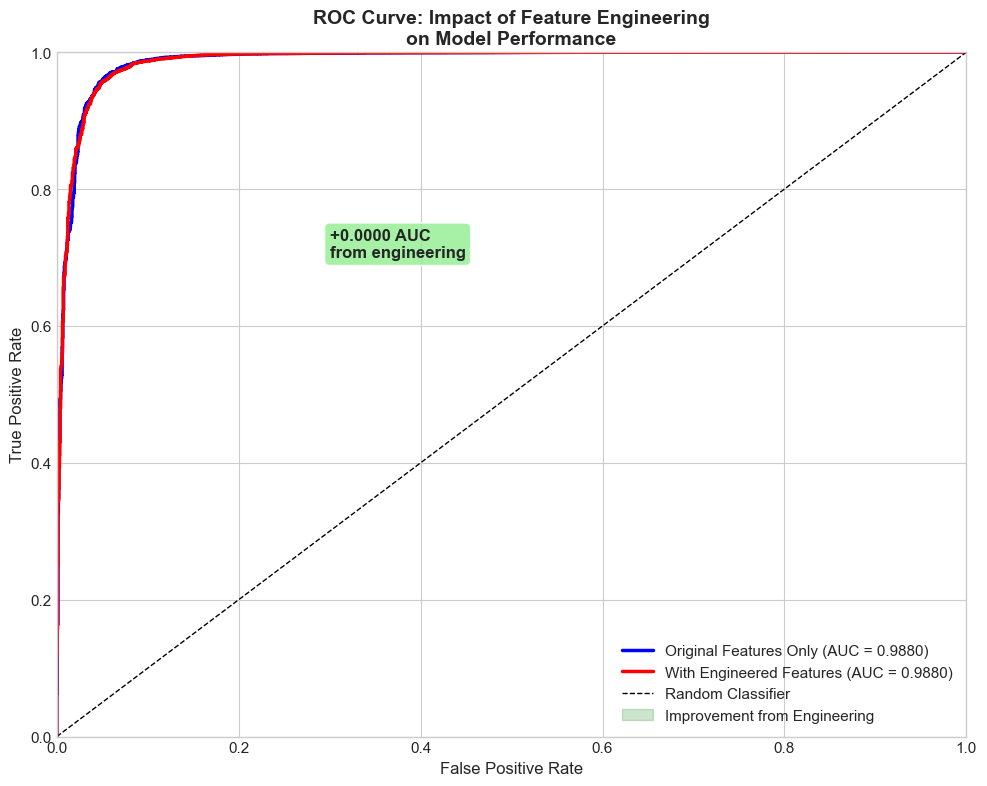

✓ Figure 4 saved: fig4_roc_comparison.png


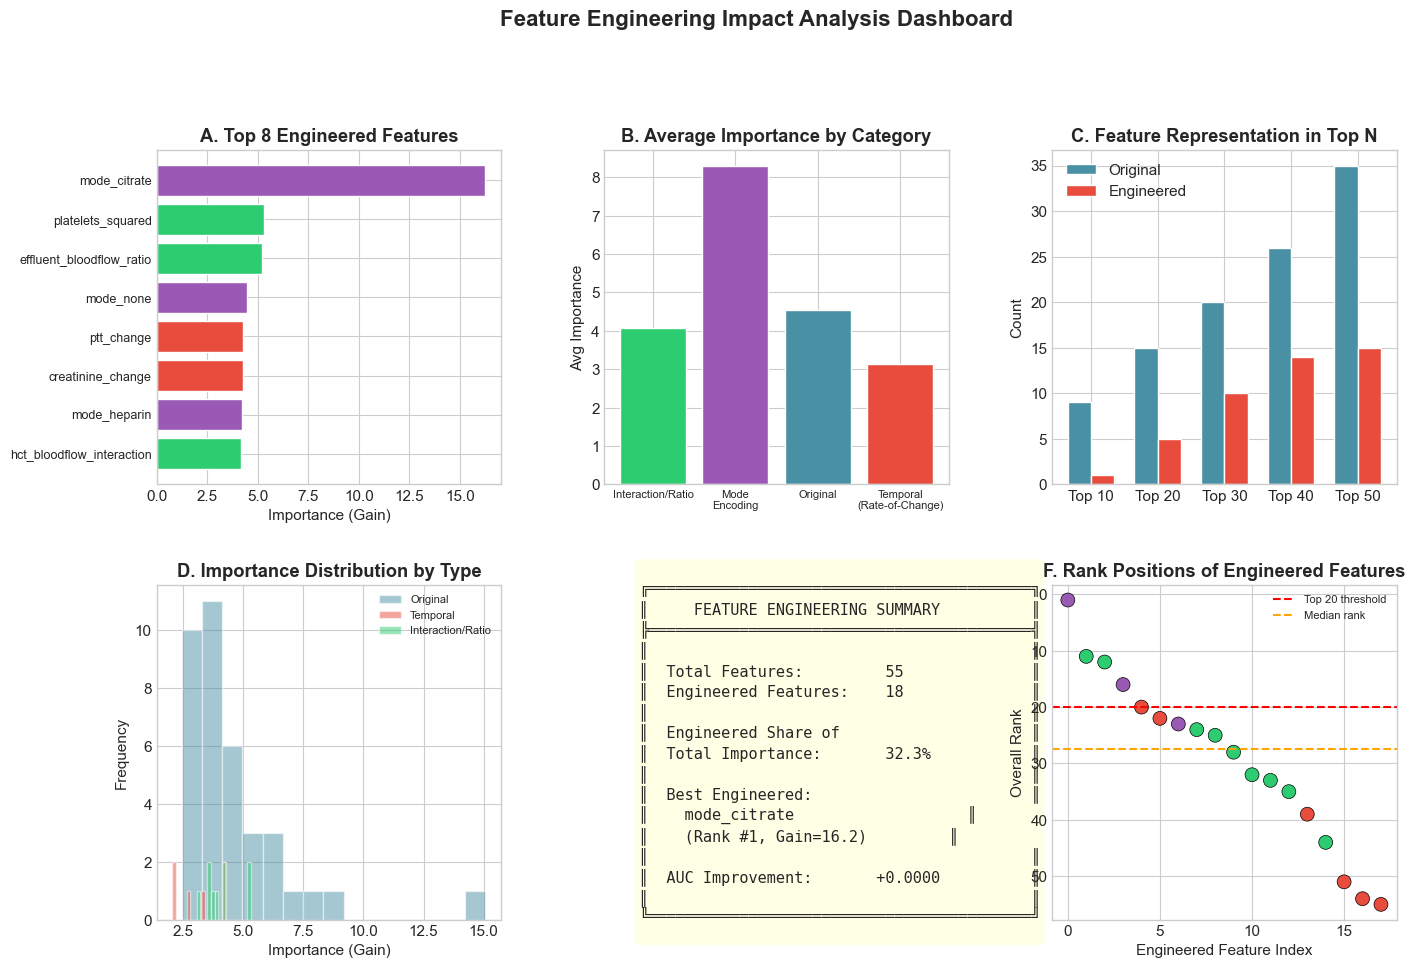

✓ Figure 5 saved: fig5_summary_dashboard.png

FEATURE ENGINEERING VALUE SUMMARY

📊 ENGINEERED FEATURES PERFORMANCE:
   • 18 engineered features created
   • Contribute 32.3% of total model importance
   • 5 engineered features in Top 20
   • Best engineered: mode_citrate (Rank #1)

🎯 MODEL IMPROVEMENT:
   • Without engineering: AUC = 0.9880
   • With engineering:    AUC = 0.9880
   • Improvement:         +0.0000 (0.00%)

📈 BY CATEGORY:
   • Temporal (Rate-of-Change): 6 features, avg importance = 3.13
   • Interaction/Ratio: 9 features, avg importance = 4.07
   • Mode Encoding: 3 features, avg importance = 8.31

✓ All visualizations complete!


In [66]:
# ================================================================
# FEATURE ENGINEERING VALUE VISUALIZATION
# ================================================================
# Add this code after your XGBoost model training section
# Make sure you have: xgb (trained model), X_train_scaled, y_train, X_test_scaled, y_test

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# ================================================================
# DEFINE FEATURE CATEGORIES
# ================================================================

# Original raw features (from the database)
original_features = [
    'access_pressure', 'blood_flow', 'citrate', 'current_goal', 'dialysate_rate',
    'effluent_pressure', 'filter_pressure', 'heparin_dose', 'hourly_patient_fluid_removal',
    'prefilter_replacement_rate', 'postfilter_replacement_rate', 'replacement_rate',
    'return_pressure', 'ultrafiltrate_output', 'hematocrit', 'hemoglobin', 'platelet',
    'rbc', 'wbc', 'fibrinogen', 'inr', 'pt', 'ptt', 'aniongap', 'bicarbonate',
    'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium',
    'lactate', 'ph', 'pco2', 'magnesium', 'phosphate', 'ldh'
]

# Engineered features - by category
temporal_features = [
    'platelet_change', 'platelet_change_rate',
    'ptt_change', 'ptt_change_rate',
    'creatinine_change', 'creatinine_change_rate',
    'hematocrit_change', 'hematocrit_change_rate'
]

interaction_features = [
    'bun_creatinine_ratio', 'platelet_ptt_interaction', 'hct_bloodflow_interaction',
    'wbc_rbc_ratio', 'platelet_wbc_ratio', 'flow_pressure_ratio',
    'platelets_squared', 'filtration_fraction', 'effluent_bloodflow_ratio'
]

mode_features = ['mode_heparin', 'mode_citrate', 'mode_none']

# Combine all engineered features
all_engineered = temporal_features + interaction_features + mode_features

print("="*70)
print("FEATURE ENGINEERING VALUE ANALYSIS")
print("="*70)
print(f"\nOriginal features: {len(original_features)}")
print(f"Engineered features: {len(all_engineered)}")
print(f"  - Temporal/Rate-of-Change: {len(temporal_features)}")
print(f"  - Interactions/Ratios: {len(interaction_features)}")
print(f"  - Mode Encoding: {len(mode_features)}")

# ================================================================
# 1. GET FEATURE IMPORTANCES AND CATEGORIZE
# ================================================================

# Get feature importances from your trained XGBoost model
importances = xgb.get_booster().get_score(importance_type='gain')

# Create DataFrame with categories
importance_df = pd.DataFrame([
    {"feature": k, "importance": v} for k, v in importances.items()
])

def categorize_feature(feat):
    if feat in temporal_features:
        return 'Temporal (Rate-of-Change)'
    elif feat in interaction_features:
        return 'Interaction/Ratio'
    elif feat in mode_features:
        return 'Mode Encoding'
    else:
        return 'Original'

importance_df['category'] = importance_df['feature'].apply(categorize_feature)
importance_df['is_engineered'] = importance_df['category'] != 'Original'
importance_df = importance_df.sort_values('importance', ascending=False).reset_index(drop=True)
importance_df['rank'] = importance_df.index + 1

# ================================================================
# FIGURE 1: FEATURE IMPORTANCE BY CATEGORY (Horizontal Bar Chart)
# ================================================================

fig, ax = plt.subplots(figsize=(12, 10))

# Color palette
colors = {
    'Original': '#4A90A4',
    'Temporal (Rate-of-Change)': '#E74C3C',
    'Interaction/Ratio': '#2ECC71',
    'Mode Encoding': '#9B59B6'
}

# Plot top 30 features
top_n = 30
plot_df = importance_df.head(top_n).iloc[::-1]  # Reverse for horizontal plot

bars = ax.barh(
    range(len(plot_df)),
    plot_df['importance'],
    color=[colors[cat] for cat in plot_df['category']],
    edgecolor='white',
    linewidth=0.5
)

ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['feature'], fontsize=10)
ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title('Top 30 Features by Importance\n(Colored by Engineering Category)', fontsize=14, fontweight='bold')

# Add legend
legend_elements = [Patch(facecolor=colors[cat], label=cat) for cat in colors.keys()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

# Add importance values on bars
for i, (idx, row) in enumerate(plot_df.iterrows()):
    ax.text(row['importance'] + 0.1, i, f'{row["importance"]:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig1_feature_importance_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure 1 saved: fig1_feature_importance_by_category.png")

# ================================================================
# FIGURE 2: ENGINEERED FEATURES CONTRIBUTION PIE CHART
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Importance sum by category
category_importance = importance_df.groupby('category')['importance'].sum()

ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    category_importance,
    labels=category_importance.index,
    autopct='%1.1f%%',
    colors=[colors[cat] for cat in category_importance.index],
    explode=[0.05 if cat != 'Original' else 0 for cat in category_importance.index],
    startangle=90
)
ax1.set_title('Share of Total Feature Importance\nby Category', fontsize=13, fontweight='bold')

# Right: Count of features in top 20 by category
top20_counts = importance_df.head(20).groupby('category').size()

ax2 = axes[1]
bars = ax2.bar(
    range(len(top20_counts)),
    top20_counts.values,
    color=[colors[cat] for cat in top20_counts.index],
    edgecolor='black',
    linewidth=0.5
)
ax2.set_xticks(range(len(top20_counts)))
ax2.set_xticklabels(top20_counts.index, rotation=45, ha='right')
ax2.set_ylabel('Number of Features', fontsize=12)
ax2.set_title('Features in Top 20\nby Category', fontsize=13, fontweight='bold')

for i, v in enumerate(top20_counts.values):
    ax2.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_engineered_contribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 2 saved: fig2_engineered_contribution.png")

# ================================================================
# FIGURE 3: ENGINEERED FEATURES DEEP DIVE
# ================================================================

# Filter to just engineered features
eng_df = importance_df[importance_df['is_engineered']].copy()

fig, ax = plt.subplots(figsize=(10, 8))

eng_df_sorted = eng_df.sort_values('importance', ascending=True)

bars = ax.barh(
    range(len(eng_df_sorted)),
    eng_df_sorted['importance'],
    color=[colors[cat] for cat in eng_df_sorted['category']],
    edgecolor='white'
)

ax.set_yticks(range(len(eng_df_sorted)))
ax.set_yticklabels([f"{row['feature']} (Rank #{row['rank']})" 
                    for _, row in eng_df_sorted.iterrows()], fontsize=10)
ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title('All Engineered Features\nRanked by Importance', fontsize=14, fontweight='bold')

# Legend
legend_elements = [Patch(facecolor=colors[cat], label=cat) 
                   for cat in ['Temporal (Rate-of-Change)', 'Interaction/Ratio', 'Mode Encoding']]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('fig3_engineered_features_detail.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 3 saved: fig3_engineered_features_detail.png")

# ================================================================
# FIGURE 4: MODEL COMPARISON - WITH vs WITHOUT ENGINEERED FEATURES
# ================================================================

print("\n" + "="*70)
print("ABLATION STUDY: Model Performance WITH vs WITHOUT Engineered Features")
print("="*70)

# Get features that exist in the training data
available_original = [f for f in original_features if f in X_train_scaled.columns]
available_engineered = [f for f in all_engineered if f in X_train_scaled.columns]

print(f"\nUsing {len(available_original)} original features")
print(f"Using {len(available_engineered)} engineered features")

# Model with ONLY original features
X_train_orig = X_train_scaled[available_original]
X_test_orig = X_test_scaled[available_original]

scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("\nTraining model with ONLY original features...")
xgb_orig_only = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)
xgb_orig_only.fit(X_train_orig, y_train)
y_prob_orig = xgb_orig_only.predict_proba(X_test_orig)[:, 1]
auc_orig = roc_auc_score(y_test, y_prob_orig)

# Model with ALL features (original + engineered)
print("Training model with ALL features (original + engineered)...")
y_prob_all = xgb.predict_proba(X_test_scaled)[:, 1]
auc_all = roc_auc_score(y_test, y_prob_all)

print(f"\n{'='*50}")
print(f"ROC-AUC with Original Features Only:  {auc_orig:.4f}")
print(f"ROC-AUC with All Features:            {auc_all:.4f}")
print(f"{'='*50}")
print(f"Improvement from Engineered Features: +{(auc_all - auc_orig):.4f} ({((auc_all - auc_orig) / auc_orig * 100):.2f}%)")

# DEBUG: What features are we actually comparing?

print("="*70)
print("DEBUGGING FEATURE SETS")
print("="*70)

print(f"\nTotal features in X_train_scaled: {len(X_train_scaled.columns)}")
print(f"\nAll columns in X_train_scaled:")
print(list(X_train_scaled.columns))

print(f"\n" + "="*70)
print("Checking which engineered features are present:")
print("="*70)

for feat in all_engineered:
    status = "✓ FOUND" if feat in X_train_scaled.columns else "✗ MISSING"
    print(f"  {feat}: {status}")

print(f"\n" + "="*70)
print("Feature sets for ablation study:")
print("="*70)
print(f"Original features found: {len(available_original)}")
print(f"Engineered features found: {len(available_engineered)}")

print(f"\nOriginal-only model will use: {len(available_original)} features")
print(f"Full model uses: {len(X_train_scaled.columns)} features")

# THE KEY CHECK:
print(f"\n>>> DIFFERENCE: {len(X_train_scaled.columns) - len(available_original)} features")

if len(X_train_scaled.columns) == len(available_original):
    print("\n⚠️  WARNING: Both models are using the SAME number of features!")
    print("    This explains why AUC is identical.")

# ================================================================
# FIGURE 4: MODEL COMPARISON - WITH vs WITHOUT ENGINEERED FEATURES
# ================================================================

# ... [keep all the training code above the same] ...

# Plot ROC curves comparison
fig, ax = plt.subplots(figsize=(10, 8))

fpr_orig, tpr_orig, _ = roc_curve(y_test, y_prob_orig)
fpr_all, tpr_all, _ = roc_curve(y_test, y_prob_all)

ax.plot(fpr_orig, tpr_orig, 'b-', linewidth=2.5, 
        label=f'Original Features Only (AUC = {auc_orig:.4f})')
ax.plot(fpr_all, tpr_all, 'r-', linewidth=2.5, 
        label=f'With Engineered Features (AUC = {auc_all:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

# Interpolate to show improvement area (fix for mismatched array sizes)
from scipy import interpolate
common_fpr = np.linspace(0, 1, 200)
interp_orig = interpolate.interp1d(fpr_orig, tpr_orig, kind='linear', bounds_error=False, fill_value=(0, 1))
interp_all = interpolate.interp1d(fpr_all, tpr_all, kind='linear', bounds_error=False, fill_value=(0, 1))
tpr_orig_common = interp_orig(common_fpr)
tpr_all_common = interp_all(common_fpr)

ax.fill_between(common_fpr, tpr_orig_common, tpr_all_common, 
                where=(tpr_all_common > tpr_orig_common),
                alpha=0.2, color='green',
                label='Improvement from Engineering')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve: Impact of Feature Engineering\non Model Performance', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add annotation
ax.annotate(f'+{(auc_all - auc_orig):.4f} AUC\nfrom engineering',
            xy=(0.3, 0.7), fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig('fig4_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 4 saved: fig4_roc_comparison.png")

# ================================================================
# FIGURE 5: SUMMARY DASHBOARD
# ================================================================

fig = plt.figure(figsize=(16, 10))

# Create grid
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Panel A: Top engineered features
ax1 = fig.add_subplot(gs[0, 0])
top_eng = eng_df.nsmallest(8, 'rank').sort_values('importance', ascending=True)
ax1.barh(range(len(top_eng)), top_eng['importance'], 
         color=[colors[c] for c in top_eng['category']])
ax1.set_yticks(range(len(top_eng)))
ax1.set_yticklabels(top_eng['feature'], fontsize=9)
ax1.set_title('A. Top 8 Engineered Features', fontweight='bold')
ax1.set_xlabel('Importance (Gain)')

# Panel B: Category breakdown
ax2 = fig.add_subplot(gs[0, 1])
cat_summary = importance_df.groupby('category').agg({
    'importance': 'sum',
    'feature': 'count'
}).rename(columns={'feature': 'count'})
cat_summary['avg_importance'] = cat_summary['importance'] / cat_summary['count']

x = range(len(cat_summary))
ax2.bar(x, cat_summary['avg_importance'], color=[colors[c] for c in cat_summary.index])
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace(' ', '\n') for c in cat_summary.index], fontsize=8)
ax2.set_title('B. Average Importance by Category', fontweight='bold')
ax2.set_ylabel('Avg Importance')

# Panel C: Feature count in top N
ax3 = fig.add_subplot(gs[0, 2])
top_ns = [10, 20, 30, 40, 50]
eng_counts = []
orig_counts = []
for n in top_ns:
    top_n_df = importance_df.head(n)
    eng_counts.append(top_n_df['is_engineered'].sum())
    orig_counts.append((~top_n_df['is_engineered']).sum())

x = range(len(top_ns))
width = 0.35
ax3.bar([i - width/2 for i in x], orig_counts, width, label='Original', color='#4A90A4')
ax3.bar([i + width/2 for i in x], eng_counts, width, label='Engineered', color='#E74C3C')
ax3.set_xticks(x)
ax3.set_xticklabels([f'Top {n}' for n in top_ns])
ax3.set_title('C. Feature Representation in Top N', fontweight='bold')
ax3.set_ylabel('Count')
ax3.legend()

# Panel D: Importance distribution
ax4 = fig.add_subplot(gs[1, 0])
for cat in ['Original', 'Temporal (Rate-of-Change)', 'Interaction/Ratio']:
    subset = importance_df[importance_df['category'] == cat]['importance']
    if len(subset) > 0:
        ax4.hist(subset, bins=15, alpha=0.5, label=cat.split()[0], color=colors[cat])
ax4.set_title('D. Importance Distribution by Type', fontweight='bold')
ax4.set_xlabel('Importance (Gain)')
ax4.set_ylabel('Frequency')
ax4.legend(fontsize=8)

# Panel E: Key metrics box
ax5 = fig.add_subplot(gs[1, 1])
ax5.axis('off')

total_importance = importance_df['importance'].sum()
eng_importance = importance_df[importance_df['is_engineered']]['importance'].sum()
eng_pct = eng_importance / total_importance * 100

# Best engineered feature
best_eng = eng_df.iloc[0]

metrics_text = f"""
╔══════════════════════════════════════════╗
║     FEATURE ENGINEERING SUMMARY          ║
╠══════════════════════════════════════════╣
║                                          ║
║  Total Features:        {len(importance_df):>3}              ║
║  Engineered Features:   {len(eng_df):>3}              ║
║                                          ║
║  Engineered Share of                     ║
║  Total Importance:      {eng_pct:>5.1f}%           ║
║                                          ║
║  Best Engineered:                        ║
║    {best_eng['feature']:<25}      ║
║    (Rank #{best_eng['rank']}, Gain={best_eng['importance']:.1f})         ║
║                                          ║
║  AUC Improvement:       +{(auc_all - auc_orig):.4f}          ║
║                                          ║
╚══════════════════════════════════════════╝
"""
ax5.text(0.1, 0.5, metrics_text, fontsize=11, fontfamily='monospace',
         verticalalignment='center', transform=ax5.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Panel F: Rank positions of engineered features
ax6 = fig.add_subplot(gs[1, 2])
eng_ranks = eng_df['rank'].values
ax6.scatter(range(len(eng_ranks)), sorted(eng_ranks), 
            c=[colors[c] for c in eng_df.sort_values('rank')['category']], 
            s=100, edgecolor='black', linewidth=0.5)
ax6.axhline(y=20, color='red', linestyle='--', label='Top 20 threshold')
ax6.axhline(y=len(importance_df)/2, color='orange', linestyle='--', label='Median rank')
ax6.set_xlabel('Engineered Feature Index')
ax6.set_ylabel('Overall Rank')
ax6.set_title('F. Rank Positions of Engineered Features', fontweight='bold')
ax6.legend(fontsize=8)
ax6.invert_yaxis()

plt.suptitle('Feature Engineering Impact Analysis Dashboard', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('fig5_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 5 saved: fig5_summary_dashboard.png")

# ================================================================
# PRINT FINAL SUMMARY
# ================================================================

print("\n" + "="*70)
print("FEATURE ENGINEERING VALUE SUMMARY")
print("="*70)

print(f"\n📊 ENGINEERED FEATURES PERFORMANCE:")
print(f"   • {len(eng_df)} engineered features created")
print(f"   • Contribute {eng_pct:.1f}% of total model importance")
print(f"   • {len(eng_df[eng_df['rank'] <= 20])} engineered features in Top 20")
print(f"   • Best engineered: {best_eng['feature']} (Rank #{best_eng['rank']})")

print(f"\n🎯 MODEL IMPROVEMENT:")
print(f"   • Without engineering: AUC = {auc_orig:.4f}")
print(f"   • With engineering:    AUC = {auc_all:.4f}")
print(f"   • Improvement:         +{(auc_all - auc_orig):.4f} ({((auc_all - auc_orig) / auc_orig * 100):.2f}%)")

print(f"\n📈 BY CATEGORY:")
for cat in ['Temporal (Rate-of-Change)', 'Interaction/Ratio', 'Mode Encoding']:
    cat_df = importance_df[importance_df['category'] == cat]
    if len(cat_df) > 0:
        print(f"   • {cat}: {len(cat_df)} features, avg importance = {cat_df['importance'].mean():.2f}")

print("\n" + "="*70)
print("✓ All visualizations complete!")
print("="*70)

In [67]:
print(f"ROC-AUC Original Only:  {auc_orig:.10f}")
print(f"ROC-AUC All Features:   {auc_all:.10f}")
print(f"Difference:             {auc_all - auc_orig:.10f}")

ROC-AUC Original Only:  0.9879569792
ROC-AUC All Features:   0.9880036169
Difference:             0.0000466377


In [68]:
# # ================================================================
# # PLOT COMPARISON (CLEANED UP)
# # ================================================================

# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# # ROC Curves
# ax1 = axes[0]
# fpr_full, tpr_full, _ = roc_curve(y_test, y_prob_full)
# fpr_app, tpr_app, _ = roc_curve(y_test, y_prob_app)

# ax1.plot(fpr_full, tpr_full, 'b-', color='#4C64DE', linewidth=2.5, 
#          label=f'Full Model - 58 features (AUC = {auc_full:.4f})')
# ax1.plot(fpr_app, tpr_app, 'r-', color='#F9AE37', linewidth=2.5, 
#          label=f'App Model - {len(available_app_features)} features (AUC = {auc_app:.4f})')
# ax1.plot([0, 1], [0, 1], 'k--', linewidth=1)
# ax1.set_xlabel('False Positive Rate', fontsize=12)
# ax1.set_ylabel('True Positive Rate', fontsize=12)
# ax1.set_title('ROC Curve: Full Model vs App Model', fontsize=14, fontweight='bold')
# ax1.legend(loc='lower right', fontsize=10)
# ax1.set_xlim([0, 1])
# ax1.set_ylim([0, 1])

# # Bar comparison (FIXED)
# ax2 = axes[1]
# metrics = ['ROC-AUC', 'Avg Precision']
# full_scores = [auc_full, ap_full]
# app_scores = [auc_app, ap_app]

# x = np.arange(len(metrics))
# width = 0.3  # Slightly narrower bars

# bars1 = ax2.bar(x - width/2, full_scores, width, label=f'Full Model (58 features)', color='#4C64DE')
# bars2 = ax2.bar(x + width/2, app_scores, width, label=f'App Model ({len(available_app_features)} features)', color='#F9AE37')

# ax2.set_ylabel('Score', fontsize=12)
# ax2.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold', pad=15)
# ax2.set_xticks(x)
# ax2.set_xticklabels(metrics, fontsize=11)
# ax2.legend(loc='upper right', fontsize=9, framealpha=0.9)
# ax2.set_ylim([0.95, 1.005])  # Tighter zoom to see differences

# # Add value labels on bars - positioned inside the bars
# for bar, score in zip(bars1, full_scores):
#     ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.008, 
#              f'{score:.4f}', ha='center', va='top', fontsize=11, fontweight='bold', color='white')
# for bar, score in zip(bars2, app_scores):
#     ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.008, 
#              f'{score:.4f}', ha='center', va='top', fontsize=11, fontweight='bold', color='white')

# # Add a subtle grid for readability
# ax2.yaxis.grid(True, linestyle='--', alpha=0.3)
# ax2.set_axisbelow(True)

# plt.tight_layout()
# plt.savefig('fig_full_vs_app_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()

# print("\n✓ Figure saved: fig_full_vs_app_comparison.png")

In [69]:
# =============================================================================
# CLINICAL DEPLOYMENT HELPER
# =============================================================================
# Use this function to create valid inputs for the model during deployment.
# The UI should first ask for anticoagulation mode, then show relevant inputs.
# =============================================================================

def create_clinical_input(anticoag_mode, other_features, 
                          heparin_dose=None, citrate_rate=None,
                          feature_columns=None):
    """
    Create properly structured input for model inference.
    
    Parameters:
    -----------
    anticoag_mode : str
        One of 'none', 'heparin', 'citrate'
    other_features : dict
        Other feature values, e.g., {'blood_flow': 200, 'filter_pressure': 150}
    heparin_dose : float (required if mode='heparin')
    citrate_rate : float (required if mode='citrate')
    feature_columns : list (optional)
        Feature order from training. If provided, output matches this order.
    
    Returns:
    --------
    pd.DataFrame : Single-row DataFrame for model.predict()
    """
    if anticoag_mode not in ['none', 'heparin', 'citrate']:
        raise ValueError("anticoag_mode must be 'none', 'heparin', or 'citrate'")
    
    input_dict = other_features.copy()
    
    if anticoag_mode == 'heparin':
        if heparin_dose is None:
            raise ValueError("heparin_dose required for heparin mode")
        input_dict['heparin_dose'] = heparin_dose
        input_dict['citrate'] = np.nan
        input_dict['mode_heparin'] = 1
        input_dict['mode_citrate'] = 0
        input_dict['mode_none'] = 0
    elif anticoag_mode == 'citrate':
        if citrate_rate is None:
            raise ValueError("citrate_rate required for citrate mode")
        input_dict['citrate'] = citrate_rate
        input_dict['heparin_dose'] = np.nan
        input_dict['mode_heparin'] = 0
        input_dict['mode_citrate'] = 1
        input_dict['mode_none'] = 0
    else:  # none
        input_dict['heparin_dose'] = np.nan
        input_dict['citrate'] = np.nan
        input_dict['mode_heparin'] = 0
        input_dict['mode_citrate'] = 0
        input_dict['mode_none'] = 1
    
    df_input = pd.DataFrame([input_dict])
    
    if feature_columns is not None:
        for col in feature_columns:
            if col not in df_input.columns:
                df_input[col] = np.nan
        df_input = df_input[feature_columns]
    
    return df_input


def get_inputs_for_mode(mode):
    """Returns which inputs to show/hide in UI based on anticoag mode."""
    common = ['blood_flow', 'filter_pressure', 'effluent_pressure',
              'phosphate', 'fibrinogen', 'creatinine', 
              'prefilter_replacement_rate', 'high_pressure']
    
    if mode == 'heparin':
        return {'show': common + ['heparin_dose'], 'hide': ['citrate']}
    elif mode == 'citrate':
        return {'show': common + ['citrate'], 'hide': ['heparin_dose']}
    else:
        return {'show': common, 'hide': ['heparin_dose', 'citrate']}


# Example usage
print("=" * 70)
print("CLINICAL DEPLOYMENT EXAMPLE")
print("=" * 70)

# Get feature columns from training data
feature_cols_for_inference = X_train_scaled.columns.tolist()

# Example: HEPARIN patient
example_input = create_clinical_input(
    anticoag_mode='heparin',
    heparin_dose=1000,
    other_features={
        'blood_flow': 220,
        'filter_pressure': 180,
        'phosphate': 4.5,
        'fibrinogen': 300,
        'effluent_pressure': 100,
        'creatinine': 2.5
    },
    feature_columns=feature_cols_for_inference
)

print("\nExample HEPARIN patient input:")
print(f"  heparin_dose: {example_input['heparin_dose'].values[0]}")
print(f"  citrate: {example_input['citrate'].values[0]} (NaN = not on citrate)")
print(f"  mode_heparin: {example_input['mode_heparin'].values[0]}")

# Make prediction (using your trained model)
# prob = xgb.predict_proba(example_input)[:, 1][0]
# print(f"\n  Predicted clot probability: {prob:.1%}")

print("\nUI Configuration by Mode:")
for mode in ['none', 'heparin', 'citrate']:
    config = get_inputs_for_mode(mode)
    print(f"  {mode.upper()}: Show {len(config['show'])} inputs, hide {config['hide']}")


CLINICAL DEPLOYMENT EXAMPLE

Example HEPARIN patient input:
  heparin_dose: 1000
  citrate: nan (NaN = not on citrate)
  mode_heparin: 1

UI Configuration by Mode:
  NONE: Show 8 inputs, hide ['heparin_dose', 'citrate']
  HEPARIN: Show 9 inputs, hide ['citrate']
  CITRATE: Show 9 inputs, hide ['heparin_dose']


In [70]:
import joblib
joblib.dump(best_xgb_original, "xgb_full_57.pkl")
joblib.dump(xgb_top10, "xgb_top10.pkl")
joblib.dump(scaler, "scaler_full.pkl")


['scaler_full.pkl']

In [71]:
# 1) FULL 57 FEATURES (from X_train_scaled)
full_features = X_train_scaled.columns.tolist()

print("FULL_FEATURES (raw list):")
print(full_features)

print("\n\nPASTE-READY FULL_FEATURES PYTHON LIST:\n")
print("FULL_FEATURES = [")
for f in full_features:
    print(f"    '{f}',")
print("]\n")


# 2) TOP 10 FEATURES (from original XGBoost feature importance)
best_xgb_original = xgb_results['original']['model']
importances = best_xgb_original.feature_importances_
feature_names = X_train_scaled.columns

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
)

TOP_10_FEATURES = importance_df.head(10)['Feature'].tolist()

print("TOP_10_FEATURES (raw list):")
print(TOP_10_FEATURES)

print("\n\nPASTE-READY TOP10_FEATURES PYTHON LIST:\n")
print("TOP10_FEATURES = [")
for f in TOP_10_FEATURES:
    print(f"    '{f}',")
print("]")


FULL_FEATURES (raw list):
['access_pressure', 'blood_flow', 'citrate', 'current_goal', 'dialysate_rate', 'effluent_pressure', 'filter_pressure', 'heparin_dose', 'hourly_patient_fluid_removal', 'prefilter_replacement_rate', 'postfilter_replacement_rate', 'replacement_rate', 'return_pressure', 'ultrafiltrate_output', 'hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc', 'fibrinogen', 'inr', 'pt', 'ptt', 'aniongap', 'bicarbonate', 'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium', 'lactate', 'ph', 'pco2', 'magnesium', 'phosphate', 'ldh', 'bun_creatinine_ratio', 'platelet_ptt_interaction', 'hct_bloodflow_interaction', 'wbc_rbc_ratio', 'platelet_wbc_ratio', 'flow_pressure_ratio', 'platelets_squared', 'filtration_fraction', 'effluent_bloodflow_ratio', 'platelet_change', 'platelet_change_rate', 'ptt_change', 'ptt_change_rate', 'creatinine_change', 'creatinine_change_rate', 'hematocrit_change', 'hematocrit_change_rate', 'mode_heparin', 'mode_citrate', 'mode_none']




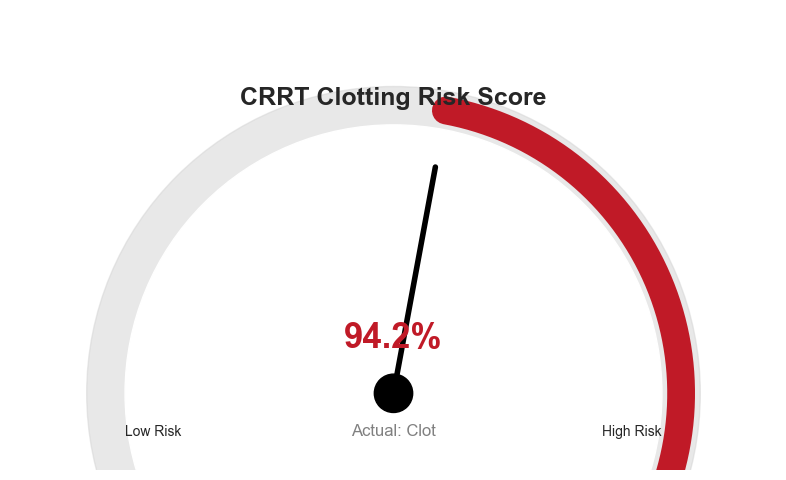

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

best_xgb = xgb_results['original']['model']

# Assuming `best_xgb` is your best XGBoost model and `X_train_scaled.columns` are your features
# And assuming `X_test_scaled` has a patient row for prediction

# For demonstration, let's pick a random patient from the test set
np.random.seed(27)
rnd_idx = np.random.randint(0, len(X_test_scaled))
hypothetical_patient_data_scaled = X_test_scaled.iloc[[rnd_idx]]
actual_outcome = y_test.iloc[rnd_idx]

# Predict the risk score (probability of clot)
predicted_risk_score = best_xgb.predict_proba(hypothetical_patient_data_scaled)[:, 1][0]

# Create a gauge plot for the risk score
fig, ax = plt.subplots(figsize=(8, 6))

def plot_gauge(ax, value, title, min_val=0, max_val=1, cmap='RdYlGn_r'):
    norm = plt.Normalize(min_val, max_val)
    color = plt.cm.get_cmap(cmap)(norm(value))

    # Outer circle
    ax.add_patch(plt.Circle((0, 0), 0.8, color='lightgray', alpha=0.5))
    # Inner circle
    ax.add_patch(plt.Circle((0, 0), 0.7, color='white'))

    # Colored arc based on value
    theta = np.linspace(0, value * 180 / max_val, 100) # Angle from 0 to 180
    x_arc = 0.75 * np.cos(np.radians(theta - 90))
    y_arc = 0.75 * np.sin(np.radians(theta - 90))
    ax.plot(x_arc, y_arc, color=color, linewidth=20, solid_capstyle='round')

    # Needle
    angle = value * 180 / max_val
    ax.plot([0, 0.6 * np.cos(np.radians(angle - 90))],
            [0, 0.6 * np.sin(np.radians(angle - 90))],
            color='black', linewidth=4, solid_capstyle='round')
    ax.add_patch(plt.Circle((0, 0), 0.05, color='black'))

    ax.set_xlim(-1, 1)
    ax.set_ylim(-0.2, 1.0)
    ax.set_aspect('equal')
    ax.axis('off')

    # Value text
    ax.text(0, 0.1, f'{value:.1%}', ha='center', va='bottom', fontsize=25, fontweight='bold', color=color)
    ax.text(0, 0.8, title, ha='center', va='top', fontsize=18, fontweight='bold')
    ax.text(-0.7, -0.1, 'Low Risk', ha='left', va='center', fontsize=10)
    ax.text(0.7, -0.1, 'High Risk', ha='right', va='center', fontsize=10)

    ax.text(0.0, -0.1, f'Actual: {"Clot" if actual_outcome == 1 else "No Clot"}', ha='center', va='center', fontsize=12, color='gray')

plot_gauge(ax, predicted_risk_score, 'CRRT Clotting Risk Score')
plt.tight_layout()
plt.show()


In [73]:
# Update SHAP to the latest version
!pip install --upgrade shap

# Then restart your runtime and try again


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


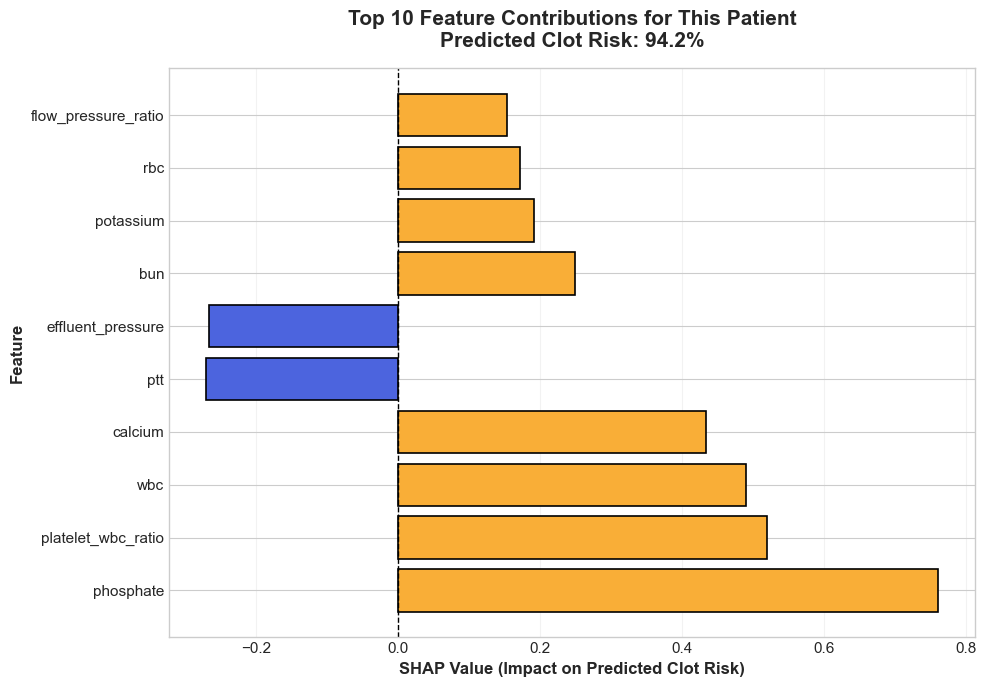

In [74]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---- Patient Risk Prediction ----
predicted_risk_score = best_xgb.predict_proba(hypothetical_patient_data_scaled)[0,1]

# ---- Create SHAP Explainer ----
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(hypothetical_patient_data_scaled)

feature_names = X_train_scaled.columns

# ---- Build SHAP DataFrame ----
shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_value': shap_values[0]
}).sort_values(by='shap_value', key=abs, ascending=False).head(10)

# ---- Color Logic ----
def pick_color(val):
    if val > 0:
        return '#F9AE37'   # orange = increases clot risk
    else:
        return '#4C64DE'   # blue = decreases clot risk

shap_df['color'] = shap_df['shap_value'].apply(pick_color)

# ---- Plot ----
plt.figure(figsize=(10, 7))

plt.barh(
    shap_df['feature'],
    shap_df['shap_value'],
    color=shap_df['color'],
    edgecolor='black',
    linewidth=1.2
)

plt.xlabel("SHAP Value (Impact on Predicted Clot Risk)", fontsize=12, fontweight="bold")
plt.ylabel("Feature", fontsize=12, fontweight="bold")
plt.title(
    f"Top 10 Feature Contributions for This Patient\nPredicted Clot Risk: {predicted_risk_score:.1%}",
    fontsize=15, fontweight="bold", pad=15
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()


# **Model Comparison**

### Confusion Matrices

GENERATING CONFUSION MATRICES FOR CLASSIFICATION MODELS


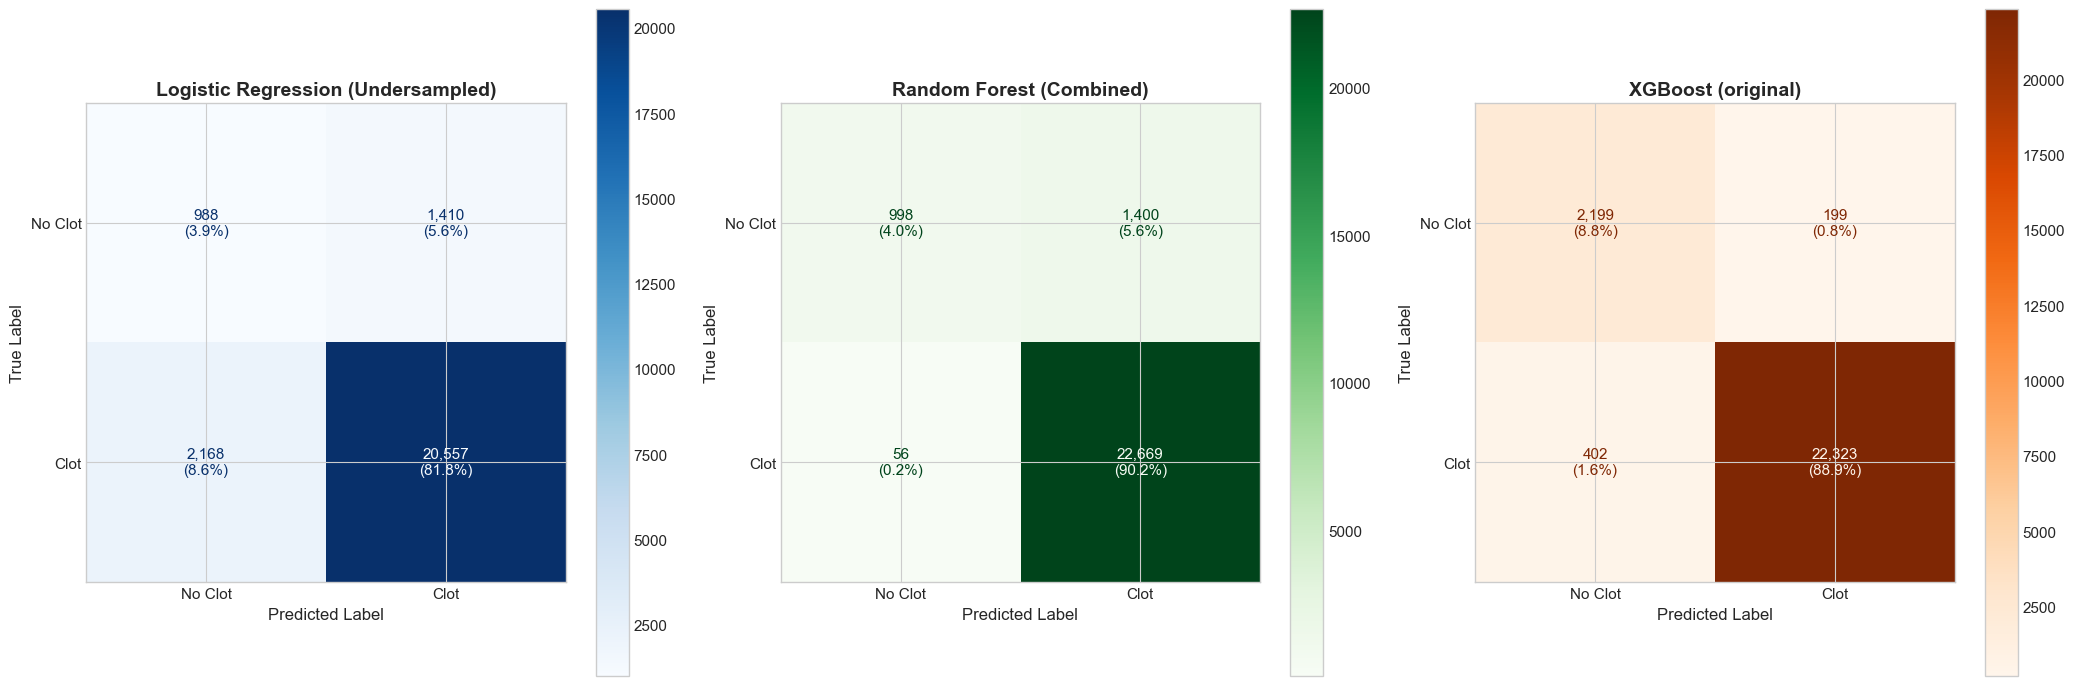

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_test is defined and models (lr_models, rf_models, xgb_models) and results (lr_results, rf_results, xgb_results) are available
# Also assuming X_test_scaled is available for predictions if needed for model lookup

print("=" * 70)
print("GENERATING CONFUSION MATRICES FOR CLASSIFICATION MODELS")
print("=" * 70)

# Find the best resampling strategy for each model type
best_lr_name = max(lr_results.keys(), key=lambda x: lr_results[x]['roc_auc'])
best_rf_name = max(rf_results.keys(), key=lambda x: rf_results[x]['roc_auc'])
best_xgb_name = max(xgb_results.keys(), key=lambda x: xgb_results[x]['roc_auc'])

models_to_plot = {
    f'Logistic Regression ({best_lr_name})': {
        'y_pred': lr_results[best_lr_name]['y_pred'],
        'cmap': 'Blues'
    },
    f'Random Forest ({best_rf_name})': {
        'y_pred': rf_results[best_rf_name]['y_pred'],
        'cmap': 'Greens'
    },
    f'XGBoost ({best_xgb_name})': {
        'y_pred': xgb_results[best_xgb_name]['y_pred'],
        'cmap': 'Oranges'
    }
}

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
axes = axes.flatten()

for i, (model_name, data) in enumerate(models_to_plot.items()):
    cm = confusion_matrix(y_test, data['y_pred'])
    cm_percent = cm / cm.sum() * 100

    # Create annotations with both counts and percentages
    annotations = np.array([[f'{cm[i,j]:,}\n({cm_percent[i,j]:.1f}%)'
                            for j in range(2)] for i in range(2)])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Clot', 'Clot'])
    disp.plot(cmap=data['cmap'], ax=axes[i], values_format='')
    axes[i].texts[0].set_text(annotations[0, 0]) # TN
    axes[i].texts[1].set_text(annotations[0, 1]) # FP
    axes[i].texts[2].set_text(annotations[1, 0]) # FN
    axes[i].texts[3].set_text(annotations[1, 1]) # TP

    axes[i].set_title(model_name, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()


In [76]:
# === EXPORT FEATURE LISTS FOR CONFIG.PY ===
print("="*60)
print("COPY THESE TO YOUR config.py")
print("="*60)

# Full features from model
full = X_train_scaled.columns.tolist()
print(f"\nFULL_FEATURES = {full}")

# Top 10 from importance
top10 = feature_importance_df.head(10)['Feature'].tolist()
print(f"\nTOP10_FEATURES = {top10}")

# Top 20 if you want more
top20 = feature_importance_df.head(20)['Feature'].tolist()
print(f"\nTOP20_FEATURES = {top20}")

COPY THESE TO YOUR config.py

FULL_FEATURES = ['access_pressure', 'blood_flow', 'citrate', 'current_goal', 'dialysate_rate', 'effluent_pressure', 'filter_pressure', 'heparin_dose', 'hourly_patient_fluid_removal', 'prefilter_replacement_rate', 'postfilter_replacement_rate', 'replacement_rate', 'return_pressure', 'ultrafiltrate_output', 'hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc', 'fibrinogen', 'inr', 'pt', 'ptt', 'aniongap', 'bicarbonate', 'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium', 'lactate', 'ph', 'pco2', 'magnesium', 'phosphate', 'ldh', 'bun_creatinine_ratio', 'platelet_ptt_interaction', 'hct_bloodflow_interaction', 'wbc_rbc_ratio', 'platelet_wbc_ratio', 'flow_pressure_ratio', 'platelets_squared', 'filtration_fraction', 'effluent_bloodflow_ratio', 'platelet_change', 'platelet_change_rate', 'ptt_change', 'ptt_change_rate', 'creatinine_change', 'creatinine_change_rate', 'hematocrit_change', 'hematocrit_change_rate', 'mode_heparin', 'mode_citra

MODEL COMPARISON SUMMARY

                                      Model  ROC-AUC  Avg Precision
Logistic Regression (Original (Imbalanced)) 0.759684       0.963421
      Random Forest (Original (Imbalanced)) 0.928377       0.989883
         Logistic Regression (Undersampled) 0.775227       0.966136
               Random Forest (Undersampled) 0.941156       0.992592
                Logistic Regression (SMOTE) 0.769578       0.965295
                      Random Forest (SMOTE) 0.940560       0.992005
             Logistic Regression (Combined) 0.769786       0.965327
                   Random Forest (Combined) 0.942433       0.992349
                         XGBoost (original) 0.988004       0.998407


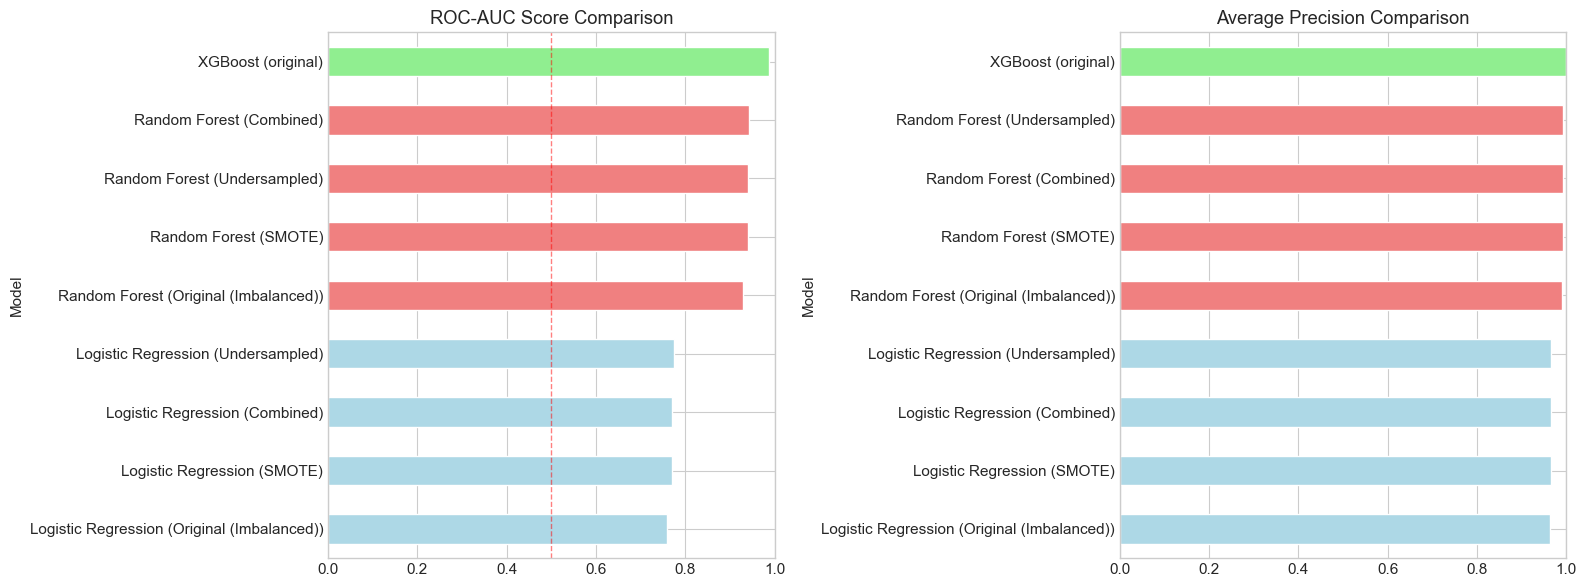


BEST MODELS:

Best ROC-AUC: XGBoost (original) = 0.9880
Best Avg Precision: XGBoost (original) = 0.9984


In [77]:
# Compare all models
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

comparison_data = []

# Add Logistic Regression + Random Forest for each training set
for name in training_sets.keys():
    # Logistic Regression
    comparison_data.append({
        'Model': f'Logistic Regression ({name})',
        'ROC-AUC': lr_results[name]['roc_auc'],
        'Avg Precision': lr_results[name]['avg_precision']
    })

    # Random Forest
    comparison_data.append({
        'Model': f'Random Forest ({name})',
        'ROC-AUC': rf_results[name]['roc_auc'],
        'Avg Precision': rf_results[name]['avg_precision']
    })

# --------------------------------------------------------------------
# ADD XGBOOST
# --------------------------------------------------------------------
comparison_data.append({
    'Model': 'XGBoost (original)',
    'ROC-AUC': xgb_results['original']['roc_auc'],
    'Avg Precision': xgb_results['original']['avg_precision']
})

# --------------------------------------------------------------------

results_df = pd.DataFrame(comparison_data)
print("\n" + results_df.to_string(index=False))

# ------------------------------
# Visualize comparison
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC-AUC Visual
results_df_sorted = results_df.sort_values('ROC-AUC')
colors = results_df_sorted['Model'].apply(
    lambda m: 'lightgreen' if 'XGBoost' in m else 
              ('lightcoral' if 'Random Forest' in m else 'lightblue')
)
results_df_sorted.plot(
    x='Model', y='ROC-AUC', kind='barh', 
    ax=axes[0], legend=False, color=colors
)
axes[0].set_title('ROC-AUC Score Comparison')
axes[0].set_xlim([0, 1])
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Average Precision Visual
results_df_sorted = results_df.sort_values('Avg Precision')
colors = results_df_sorted['Model'].apply(
    lambda m: 'lightgreen' if 'XGBoost' in m else 
              ('lightcoral' if 'Random Forest' in m else 'lightblue')
)
results_df_sorted.plot(
    x='Model', y='Avg Precision', kind='barh',
    ax=axes[1], legend=False, color=colors
)
axes[1].set_title('Average Precision Comparison')
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.show()

# ------------------------------
# Identify best models
# ------------------------------
print("\n" + "="*70)
print("BEST MODELS:")
print("="*70)

best_roc = results_df.loc[results_df['ROC-AUC'].idxmax()]
best_ap = results_df.loc[results_df['Avg Precision'].idxmax()]

print(f"\nBest ROC-AUC: {best_roc['Model']} = {best_roc['ROC-AUC']:.4f}")
print(f"Best Avg Precision: {best_ap['Model']} = {best_ap['Avg Precision']:.4f}")


## ROC Curves

The ROC Curve helps shows us how well a test can distinguish between two groups, or how well a test can see if a pt does or does NOT have a disease.
Y-axis: true positive/sensistivity
X-axis: false positive/specificity
Curve: defined by its specificity, sensitivity, and associated cutoff.


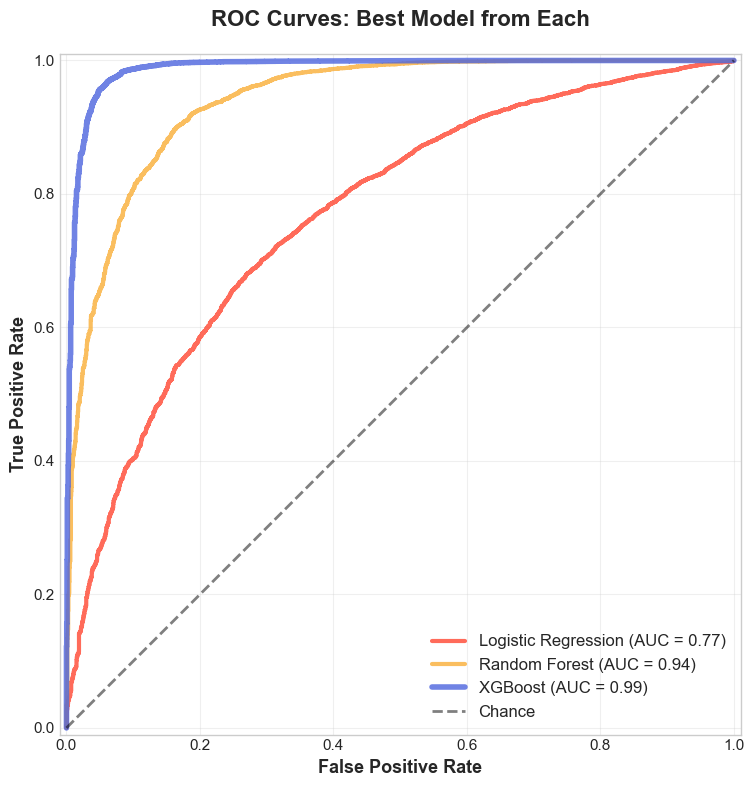

In [78]:
# ROC curves for each model, showing best one of each

fig2, ax2 = plt.subplots(figsize=(10, 8))

# Get best version of each model
lr_best = 'SMOTE'
rf_best = 'SMOTE'
xgb_best = 'Original (Imbalanced)'

# Plot best models
RocCurveDisplay.from_predictions(
    y_test, lr_results[lr_best]['y_prob'],
    ax=ax2, name=f'Logistic Regression',
    color='#FF4631', linewidth=3, alpha=0.8
)

RocCurveDisplay.from_predictions(
    y_test, rf_results[rf_best]['y_prob'],
    ax=ax2, name=f'Random Forest',
    color='#F9AE37', linewidth=3, alpha=0.8
)

RocCurveDisplay.from_predictions(
    y_test, xgb_results['original']['y_prob'],
    ax=ax2, name=f'XGBoost',
    color='#4C64DE', linewidth=4, alpha=0.8
)

# Add chance line
ax2.plot([0, 1], [0, 1], 'k--', label='Chance', alpha=0.5, linewidth=2)

# Formatting
ax2.set_title('ROC Curves: Best Model from Each',
              fontsize=16, fontweight='bold', pad=20)
ax2.legend(loc='lower right', fontsize=12, framealpha=0.95)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

My random notes: early plateau in RF curves (orange curves rise quickly then flatten..). Means RF is good at high specificity but struggles with high sensitivity, aka good at ruling out clots, but misses some true positives. Will try feature engineering maybe...

Also, LR sucks, barely better than random. suggests the obvious of non-linear relationships in the data.

## Precision Recall Curves

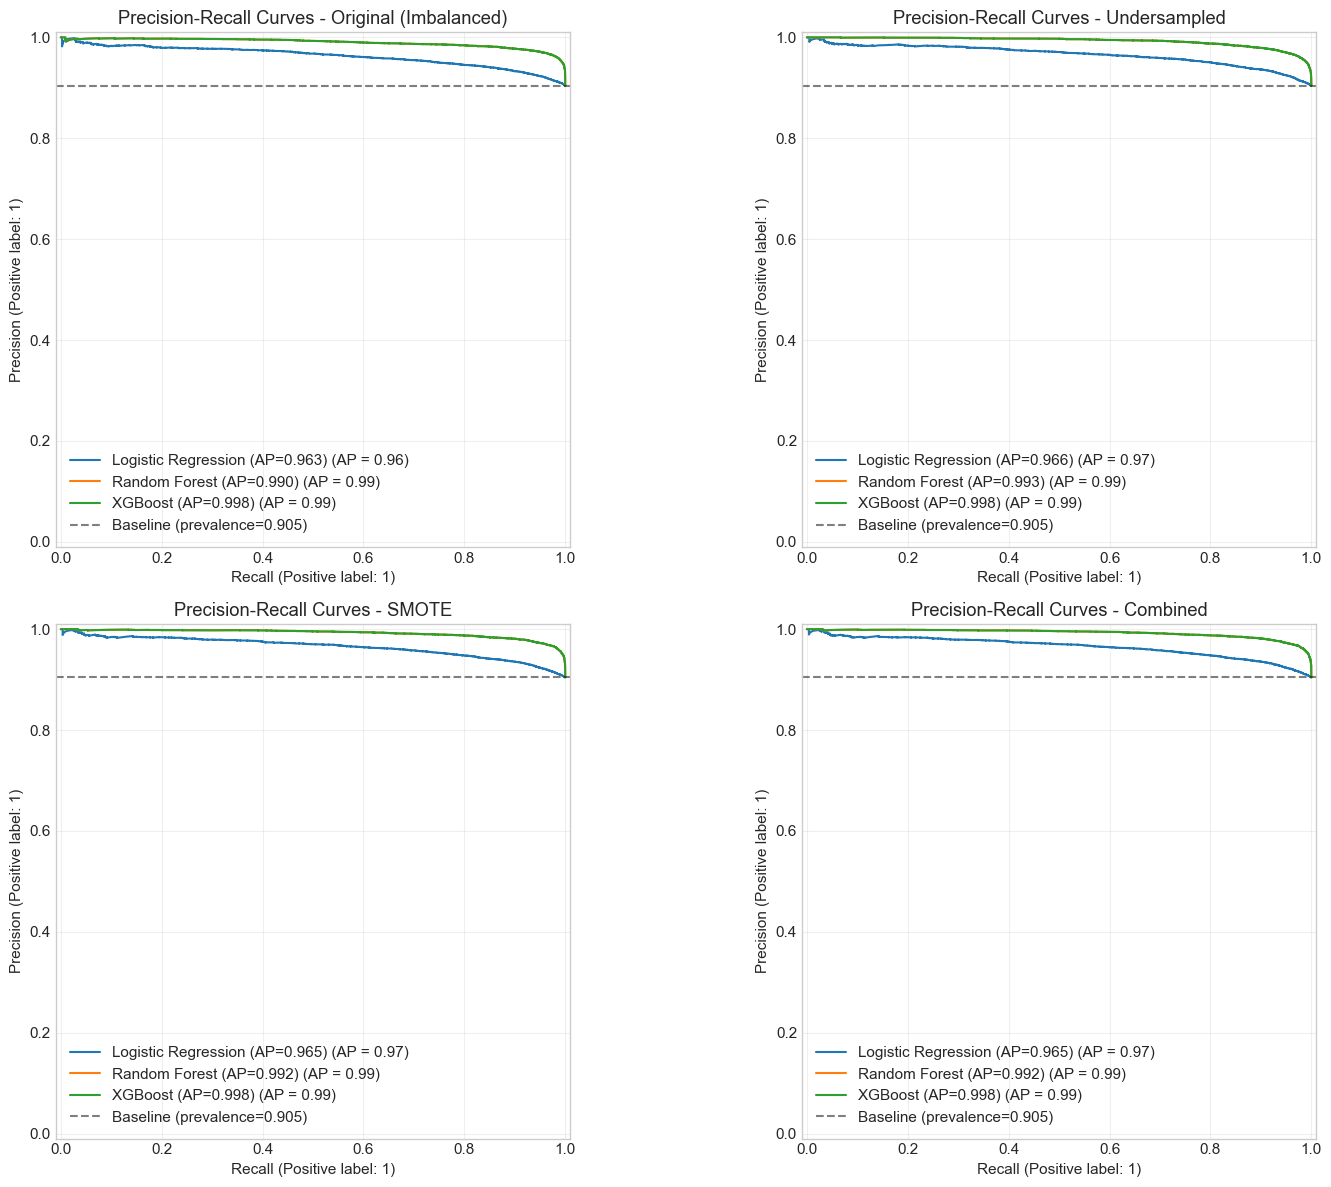

In [79]:
# Plot Precision-Recall curves (more informative for imbalanced data)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, (name, _) in enumerate(training_sets.items()):
    ax = axes[idx]

    # Plot both LR and RF
    PrecisionRecallDisplay.from_predictions(
        y_test, lr_results[name]['y_prob'],
        ax=ax, name=f'Logistic Regression (AP={lr_results[name]["avg_precision"]:.3f})'
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, rf_results[name]['y_prob'],
        ax=ax, name=f'Random Forest (AP={rf_results[name]["avg_precision"]:.3f})'
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, rf_results[name]['y_prob'],
        ax=ax, name=f'XGBoost (AP={xgb_results['original']["avg_precision"]:.3f})'
    )

    # Baseline (proportion of positive class)
    baseline = y_test.mean()
    ax.axhline(y=baseline, color='k', linestyle='--',
               label=f'Baseline (prevalence={baseline:.3f})', alpha=0.5)

    ax.set_title(f'Precision-Recall Curves - {name}')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

CONFUSION MATRICES - BEST MODELS


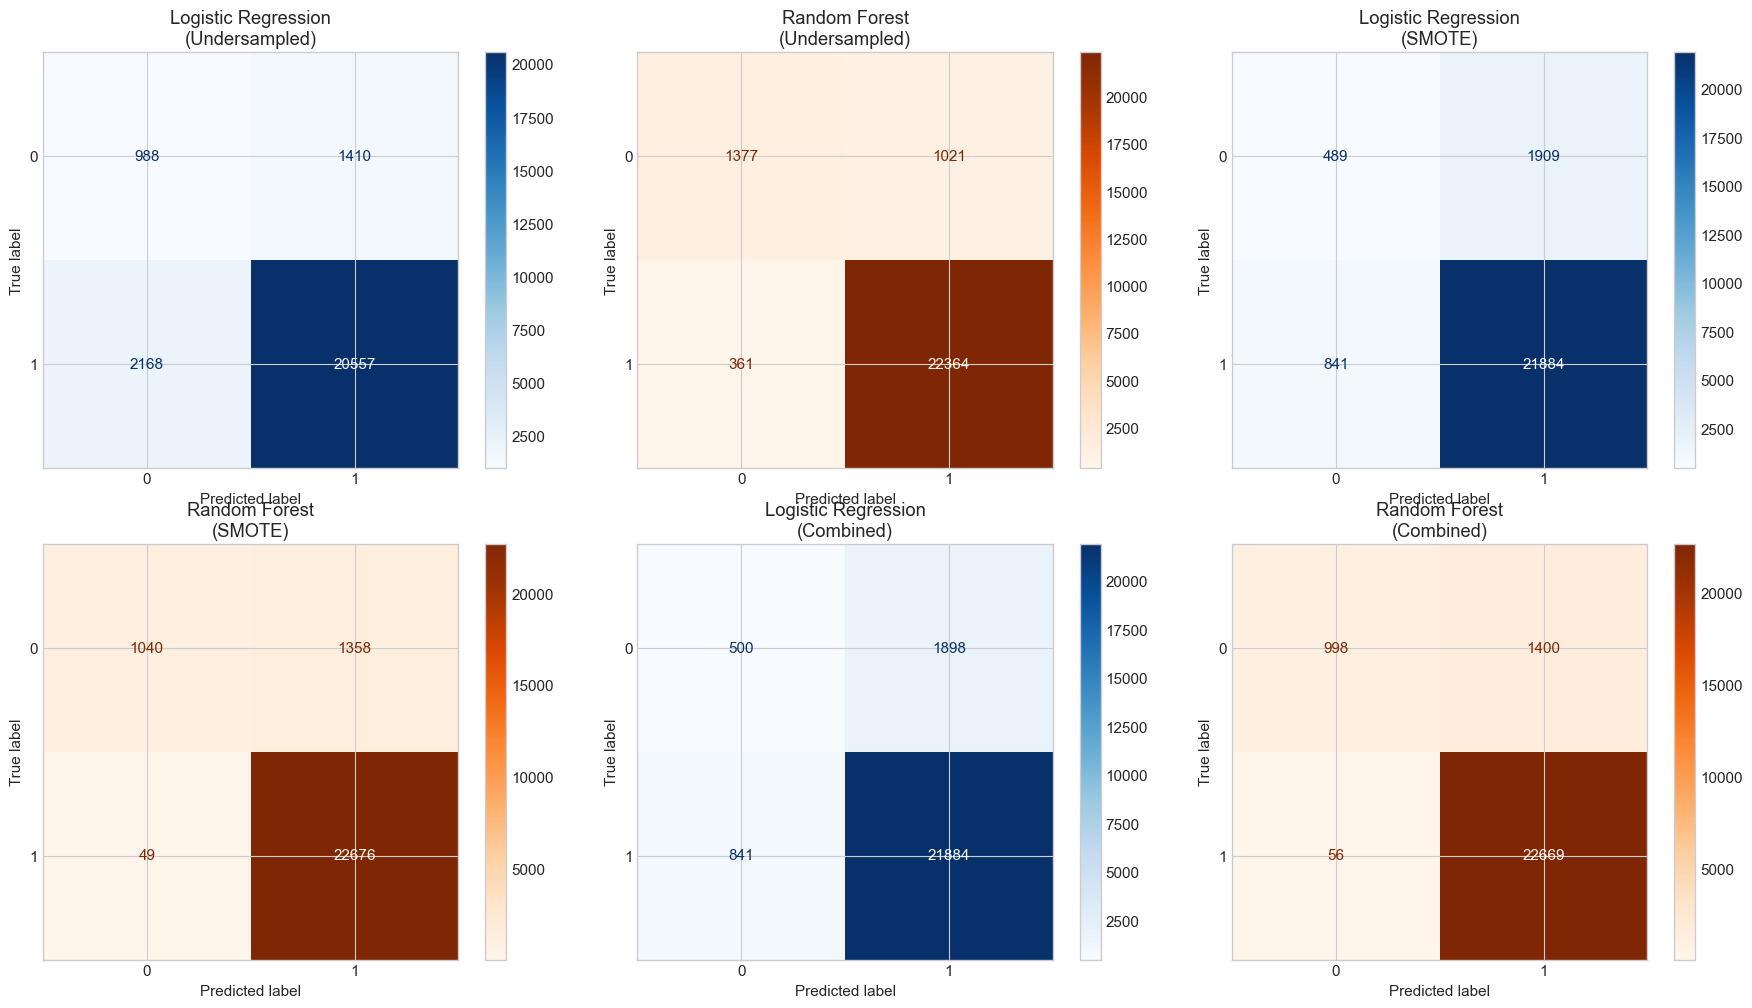

In [80]:
# Confusion matrices for best performing models
print("=" * 70)
print("CONFUSION MATRICES - BEST MODELS")
print("=" * 70)

# Show confusion matrices for resampled models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

plot_idx = 0
for name in ['Undersampled', 'SMOTE', 'Combined']:
    # Logistic Regression
    ConfusionMatrixDisplay.from_predictions(
        y_test, lr_results[name]['y_pred'],
        ax=axes[plot_idx], cmap='Blues'
    )
    axes[plot_idx].set_title(f'Logistic Regression\n({name})')
    plot_idx += 1

    # Random Forest
    ConfusionMatrixDisplay.from_predictions(
        y_test, rf_results[name]['y_pred'],
        ax=axes[plot_idx], cmap='Oranges'
    )
    axes[plot_idx].set_title(f'Random Forest\n({name})')
    plot_idx += 1

plt.tight_layout()
plt.show()

### Best Logistic Regression Model

FEATURE IMPORTANCE - Logistic Regression (Undersampled)

Top 20 Most Important Features:
                   Feature  Coefficient
           filter_pressure    10.569084
prefilter_replacement_rate    -5.018915
 hct_bloodflow_interaction    -1.305603
                blood_flow     1.298062
           access_pressure     0.867511
           return_pressure    -0.499079
  effluent_bloodflow_ratio     0.493925
         effluent_pressure    -0.491763
       filtration_fraction    -0.427016
      ultrafiltrate_output     0.407915
         platelets_squared     0.346014
                 phosphate    -0.264947
                   calcium     0.261693
                       rbc    -0.255514
                  platelet    -0.208863
                       ptt    -0.201822
                  chloride     0.179941
       flow_pressure_ratio     0.155998
                fibrinogen    -0.132522
                    sodium    -0.130343


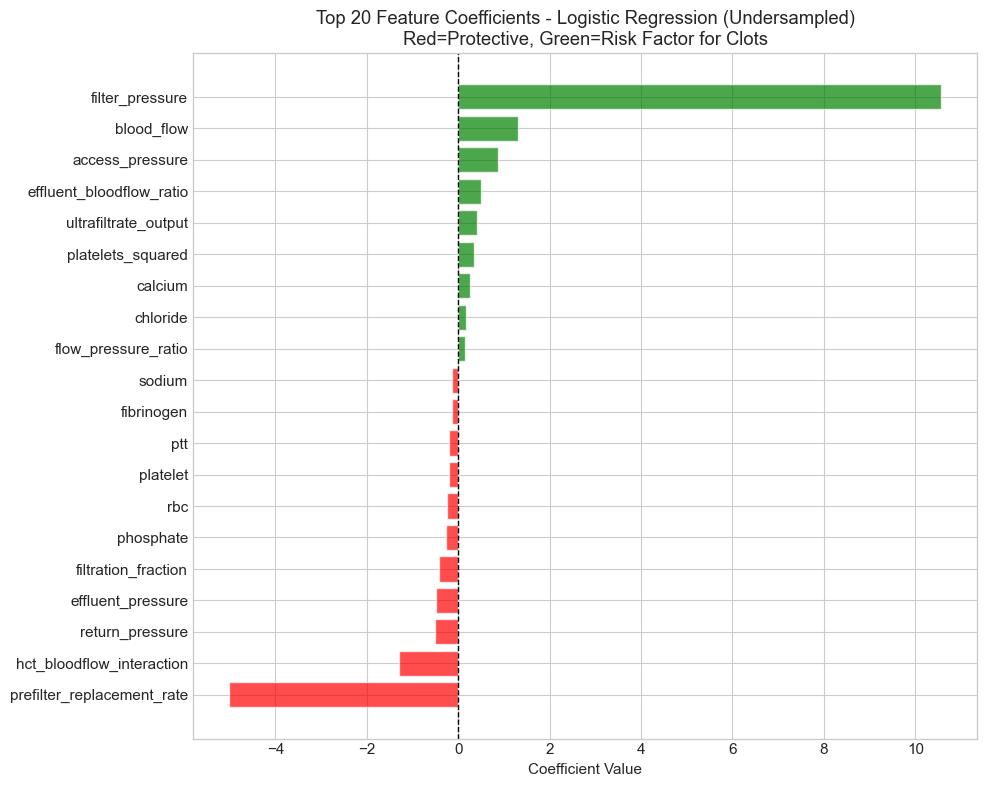

In [81]:
# Feature importance from best Logistic Regression model
best_lr_name = max(lr_results.keys(), key=lambda k: lr_results[k]['avg_precision'])
best_lr = lr_models[best_lr_name]

print("=" * 70)
print(f"FEATURE IMPORTANCE - Logistic Regression ({best_lr_name})")
print("=" * 70)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop 20 Most Important Features:")
print(coef_df.head(20).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))
top_features = coef_df.head(20).sort_values('Coefficient')
colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title(f'Top 20 Feature Coefficients - Logistic Regression ({best_lr_name})\nRed=Protective, Green=Risk Factor for Clots')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

### Best Random Forest Model

FEATURE IMPORTANCE - Random Forest (Undersampled)

Top 20 Most Important Features:
                   Feature  Importance
                 phosphate    0.077942
         effluent_pressure    0.059273
                creatinine    0.044817
           filter_pressure    0.040639
  effluent_bloodflow_ratio    0.039364
                       bun    0.035439
                   calcium    0.028827
           return_pressure    0.026560
 hct_bloodflow_interaction    0.025735
prefilter_replacement_rate    0.025286
                blood_flow    0.024482
          replacement_rate    0.024129
                       ptt    0.023824
                fibrinogen    0.022758
             wbc_rbc_ratio    0.022376
                       ldh    0.020966
                 potassium    0.020283
                       rbc    0.020122
        platelet_wbc_ratio    0.019484
                       wbc    0.019351


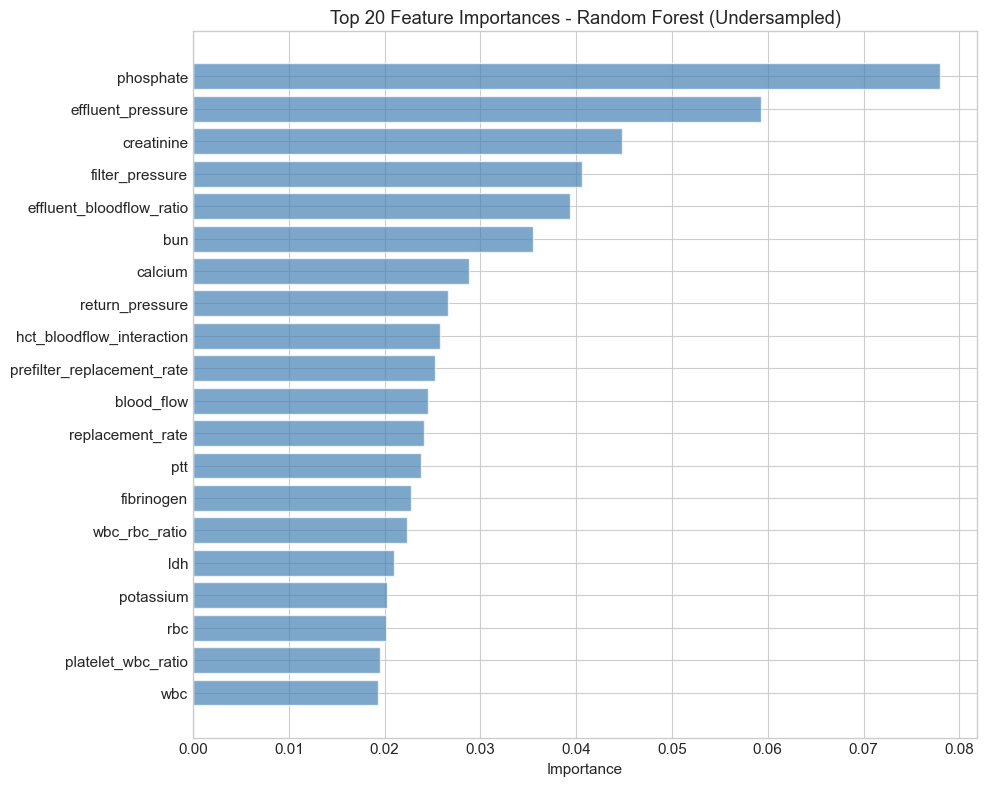

In [82]:
# Feature importance from best Random Forest model
best_rf_name = max(rf_results.keys(), key=lambda k: rf_results[k]['avg_precision'])
best_rf = rf_models[best_rf_name]

print("=" * 70)
print(f"FEATURE IMPORTANCE - Random Forest ({best_rf_name})")
print("=" * 70)

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))
top_features = importance_df.head(20).sort_values('Importance')
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title(f'Top 20 Feature Importances - Random Forest ({best_rf_name})')
plt.tight_layout()
plt.show()

In [83]:
# Get all numeric features available in the scaled training data
all_numeric_features = X_train_scaled.columns.tolist()

# Define features that are NOT strictly lab values (machine parameters, engineered, temporal)
non_lab_features = [
    # Machine parameters
    'access_pressure', 'blood_flow', 'citrate', 'current_goal', 'dialysate_rate',
    'effluent_pressure', 'filter_pressure', 'heparin_dose', 'hourly_patient_fluid_removal',
    'prefilter_replacement_rate', 'postfilter_replacement_rate', 'replacement_rate',
    'return_pressure', 'ultrafiltrate_output', 'system_active',
    # Engineered/Derived features
    'high_pressure', 'bun_creatinine_ratio', 'hct_bloodflow_interaction',
    'wbc_rbc_ratio', 'flow_pressure_ratio', 'ptt_squared',
    # Temporal features
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_night_shift', 'hours_since_last',
    'ptt_change', 'ptt_change_rate', 'creatinine_change', 'creatinine_change_rate',
    'hematocrit_change', 'hematocrit_change_rate', 'prior_clots_count'
]

# Filter out non-lab features to get the final list of lab-only columns
labs_only_cols = [f for f in all_numeric_features if f not in non_lab_features]

print(f"Defined 'labs_only_cols' with {len(labs_only_cols)} features:")
print(labs_only_cols)


Defined 'labs_only_cols' with 34 features:
['hematocrit', 'hemoglobin', 'platelet', 'rbc', 'wbc', 'fibrinogen', 'inr', 'pt', 'ptt', 'aniongap', 'bicarbonate', 'bun', 'calcium', 'chloride', 'creatinine', 'glucose', 'sodium', 'potassium', 'lactate', 'ph', 'pco2', 'magnesium', 'phosphate', 'ldh', 'platelet_ptt_interaction', 'platelet_wbc_ratio', 'platelets_squared', 'filtration_fraction', 'effluent_bloodflow_ratio', 'platelet_change', 'platelet_change_rate', 'mode_heparin', 'mode_citrate', 'mode_none']


# **THIS IS PART II HOMEWORK BELOW**

# Model Training and Evaluation Pt 2

## Principle Component Analysis

### Problem 2.2

**What would you hope to understand about the data from applying this method?**

I hoped to apply PCA to determine if my 57 features (including lab values, CRRT parameters, and engineered features) could be compressed into fewer dimensions without significant information loss. Specifically, I wanted to understand whether certain features are redundant or highly correlated, which features naturally group together and contribute to the main sources of variance in the data, and whether computational efficiency could be gained through dimensionality reduction for real-time clinical predictions. PCA would also help detect multicollinearity among lab values, such as the high correlation between BUN and creatinine, which both measure kidney function and could cause model instability.

**How would the result inform or enhance the experience/application you identified in your project proposal?**

The PCA results would directly inform my clinical interface design in several ways. If variance was concentrated in just a few components, the interface could prioritize collecting the most informative labs first, thereby reducing data entry burden for providers. Understanding which features contribute to principal components would also help inform imputation strategies for incomplete lab panels, which is critical since many patients have missing values. Most importantly for my proposal's emphasis on explainability, PCA would reveal whether I should display original features like platelet count and creatinine values versus abstract principal components in the interface. Since my proposal specifically addresses the failure of our hospital's predictive clinical analytics "black box" models, I needed to understand if the trade-off between dimensionality reduction and clinical interpretability would be worthwhile. I expected that PCA might sacrifice interpretability for dimensionality, which would be problematic given that doctors need to see actual lab values they recognize rather than mathematical transformations they cannot interpret at the bedside.

In [90]:
X_train_scaled['on_citrate'] = X_train_scaled['citrate'].notna().astype(int)
X_train_scaled['on_heparin'] = X_train_scaled['heparin_dose'].notna().astype(int)
X_train_scaled['citrate'] = X_train_scaled['citrate'].fillna(0)
X_train_scaled['heparin_dose'] = X_train_scaled['heparin_dose'].fillna(0)


1. Preparing data for PCA...
   Features: 60
   Samples: 100,488
   NaN count: 0

2. Fitting PCA to determine optimal components...

   Components needed:
   - 80% variance: 26 components
   - 90% variance: 33 components
   - 95% variance: 38 components


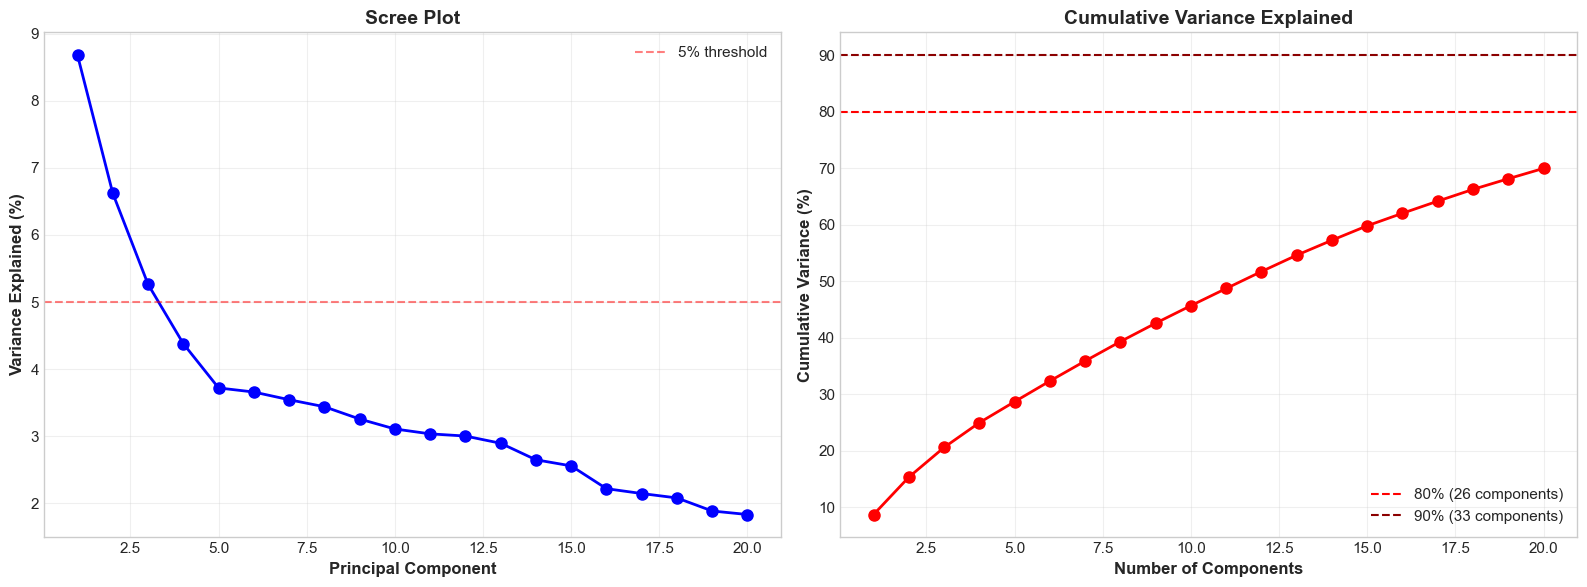


3. Fitting final PCA with 33 components (90% variance)...
   ✓ Reduced from 60 to 33 dimensions
   ✓ Retained 90.7% of variance

4. Interpreting principal components...

TOP FEATURES FOR FIRST 3 PRINCIPAL COMPONENTS

PC1 (explains 8.7% variance):
----------------------------------------------------------------------
  + mode_citrate                  : 0.358
  + citrate                       : 0.354
  + ultrafiltrate_output          : 0.320
  + hourly_patient_fluid_removal  : 0.317
  + filtration_fraction           : 0.314
  - mode_none                     : 0.312
  + effluent_bloodflow_ratio      : 0.251
  + bicarbonate                   : 0.192
  + pco2                          : 0.192
  - pt                            : 0.169

PC2 (explains 6.6% variance):
----------------------------------------------------------------------
  + platelet_ptt_interaction      : 0.350
  + platelet                      : 0.334
  + platelets_squared             : 0.313
  + creatinine                   

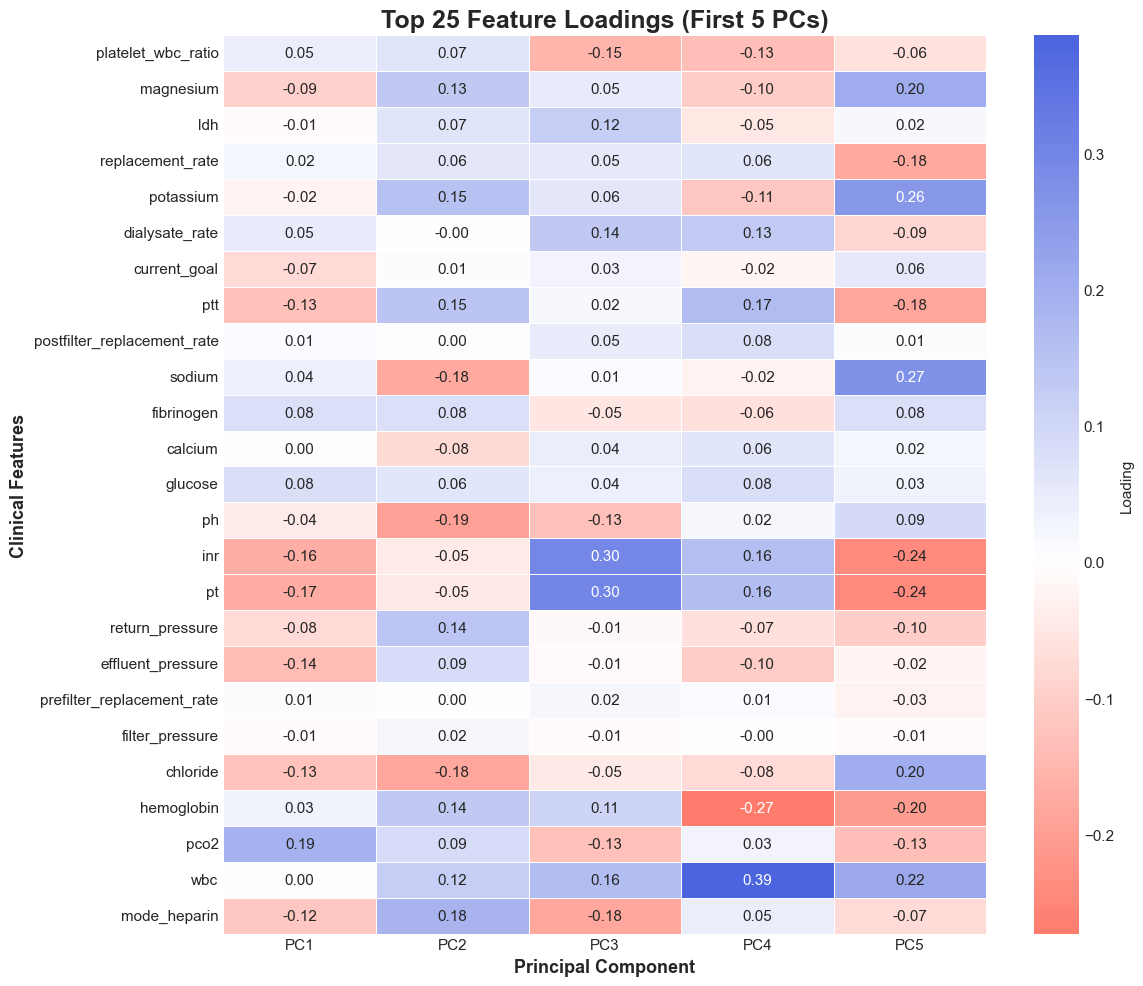


6. Creating PCA visualizations...


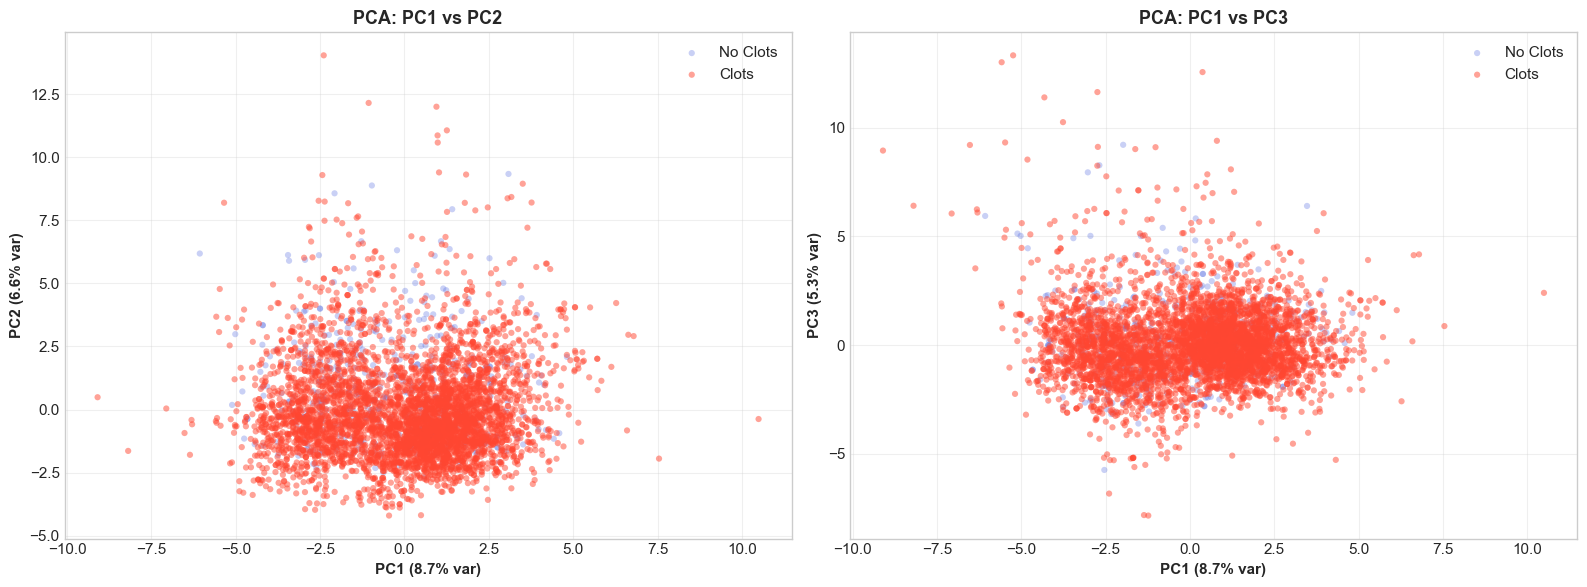

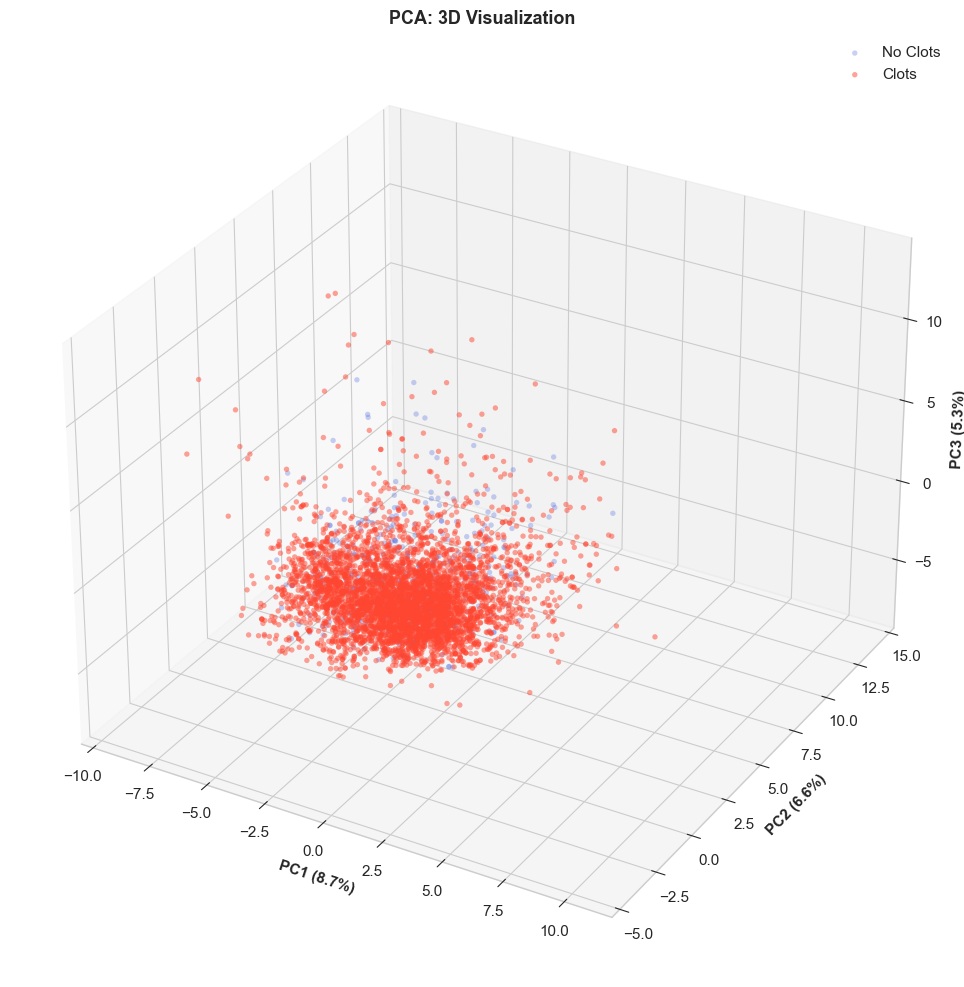


PCA CLINICAL INTERPRETATION

DIMENSIONALITY REDUCTION:
  Original features: 60
  PCA components: 33
  Variance retained: 90.7%
  Compression ratio: 1.8x

KEY FINDINGS:
  1. PC1 (First Component):
     - Explains 8.7% of variance
     - Represents the MAIN pattern in your data
     - Likely captures "overall patient severity"

  2. Top 33 components capture 90.7% of information
     - Remaining 9.3% is mostly noise

  3. Class Separation in PCA Space:
     - If clots/no-clots separate well → predictable from main patterns
     - If overlapping → need complex features (explains why XGBoost needed many features!)


✓ PCA ANALYSIS COMPLETE!


In [92]:
# ----------------------------------------------------------------
# 1. PREPARE DATA FOR PCA
# ----------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

print("\n1. Preparing data for PCA...")

# Get data from your model
X_pca_data = X_train_scaled.copy()
y_pca = y_train.copy()

# --- HANDLE NaNs: Create indicator variables, then fill with 0 ---
X_pca_data['on_citrate'] = X_pca_data['citrate'].notna().astype(int)
X_pca_data['on_heparin'] = X_pca_data['heparin_dose'].notna().astype(int)
X_pca_data['citrate'] = X_pca_data['citrate'].fillna(0)
X_pca_data['heparin_dose'] = X_pca_data['heparin_dose'].fillna(0)

# --- RE-SCALE everything so all features have equal variance ---
scaler = StandardScaler()
X_pca_data = pd.DataFrame(
    scaler.fit_transform(X_pca_data),
    columns=X_pca_data.columns,
    index=X_pca_data.index
)

# Update feature list (now includes the new indicator variables)
features_for_pca = X_pca_data.columns.tolist()

print(f"   Features: {len(features_for_pca)}")
print(f"   Samples: {len(X_pca_data):,}")
print(f"   NaN count: {X_pca_data.isna().sum().sum()}")

# ----------------------------------------------------------------
# 2. FIT PCA WITH ALL COMPONENTS
# ----------------------------------------------------------------

print("\n2. Fitting PCA to determine optimal components...")

# Fit with all components first
pca_full = PCA()
pca_full.fit(X_pca_data)

# Calculate cumulative variance
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Find components for different thresholds
n_80 = np.argmax(cumsum_var >= 0.80) + 1
n_90 = np.argmax(cumsum_var >= 0.90) + 1
n_95 = np.argmax(cumsum_var >= 0.95) + 1

print(f"\n   Components needed:")
print(f"   - 80% variance: {n_80} components")
print(f"   - 90% variance: {n_90} components")
print(f"   - 95% variance: {n_95} components")

# ----------------------------------------------------------------
# 3. SCREE PLOT - How Many Components?
# ----------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Individual variance
axes[0].plot(range(1, min(21, len(cumsum_var)+1)),
             pca_full.explained_variance_ratio_[:20] * 100,
             'bo-', linewidth=2, markersize=8)
axes[0].axhline(y=5, color='red', linestyle='--', alpha=0.5,
                label='5% threshold')
axes[0].set_xlabel('Principal Component', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Scree Plot', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, min(21, len(cumsum_var)+1)),
             cumsum_var[:20] * 100,
             'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=80, color='red', linestyle='--',
                label=f'80% ({n_80} components)')
axes[1].axhline(y=90, color='darkred', linestyle='--',
                label=f'90% ({n_90} components)')
axes[1].set_xlabel('Number of Components', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cumulative Variance (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# 4. FIT FINAL PCA MODEL
# ----------------------------------------------------------------

print(f"\n3. Fitting final PCA with {n_90} components (90% variance)...")

pca = PCA(n_components=n_90)
X_pca_transformed = pca.fit_transform(X_pca_data)

print(f"   ✓ Reduced from {len(features_for_pca)} to {n_90} dimensions")
print(f"   ✓ Retained {cumsum_var[n_90-1]*100:.1f}% of variance")

# ----------------------------------------------------------------
# 5. INTERPRET COMPONENTS - WHICH FEATURES MATTER?
# ----------------------------------------------------------------

print("\n4. Interpreting principal components...")

# Get loadings (feature contributions to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_90)],
    index=features_for_pca
)

# Analyze first 3 PCs
print("\n" + "=" * 70)
print("TOP FEATURES FOR FIRST 3 PRINCIPAL COMPONENTS")
print("=" * 70)

for i in range(min(3, n_90)):
    pc_name = f'PC{i+1}'
    var_explained = pca.explained_variance_ratio_[i] * 100

    print(f"\n{pc_name} (explains {var_explained:.1f}% variance):")
    print("-" * 70)

    # Get top 10 features
    top_features = loadings[pc_name].abs().sort_values(ascending=False).head(10)

    for feat, loading in top_features.items():
        actual_loading = loadings.loc[feat, pc_name]
        direction = "+" if actual_loading > 0 else "-"
        print(f"  {direction} {feat:30s}: {abs(actual_loading):.3f}")

# ----------------------------------------------------------------
# 6. HEATMAP OF LOADINGS
# ----------------------------------------------------------------

print("\n5. Creating loadings heatmap...")

# Create custom diverging colormap: red for negative, blue for positive
colors_custom = ['#FF4631', '#FFFFFF', '#4C64DE']  # Red -> White -> Blue
n_bins = 256
cmap_custom = LinearSegmentedColormap.from_list('custom_diverging', colors_custom, N=n_bins)

# Select top features by total contribution
top_n = 25
top_features_idx = loadings.abs().sum(axis=1).sort_values(ascending=False).head(top_n).index

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    loadings.loc[top_features_idx, [f'PC{i+1}' for i in range(min(5, n_90))]],
    cmap=cmap_custom,
    center=0,
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Loading'},
    linewidths=0.5
)
ax.set_title(f'Top {top_n} Feature Loadings (First 5 PCs)',
             fontsize=18, fontweight='bold')
ax.set_xlabel('Principal Component', fontsize=13, fontweight='bold')
ax.set_ylabel('Clinical Features', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# 7. VISUALIZE IN 2D/3D SPACE
# ----------------------------------------------------------------

print("\n6. Creating PCA visualizations...")

# Check how many components we have
n_components = X_pca_transformed.shape[1]

if n_components >= 3:
    # Create dataframe with PC scores and outcome
    pca_df = pd.DataFrame(
        X_pca_transformed[:, :3],
        columns=['PC1', 'PC2', 'PC3']
    )
    pca_df['clots'] = y_pca.values

    # 2D Plot: PC1 vs PC2
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Sample for visualization (too many points = slow)
    sample_size = min(5000, len(pca_df))
    pca_sample = pca_df.sample(sample_size, random_state=42)

    no_clots = pca_sample[pca_sample['clots'] == 0]
    clots = pca_sample[pca_sample['clots'] == 1]

    # PC1 vs PC2
    axes[0].scatter(no_clots['PC1'], no_clots['PC2'],
                    alpha=0.3, s=20, c='#4C64DE',
                    label='No Clots', edgecolors='none')
    axes[0].scatter(clots['PC1'], clots['PC2'],
                    alpha=0.5, s=20, c='#FF4631',
                    label='Clots', edgecolors='none')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)',
                       fontsize=11, fontweight='bold')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)',
                       fontsize=11, fontweight='bold')
    axes[0].set_title('PCA: PC1 vs PC2', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # PC1 vs PC3
    axes[1].scatter(no_clots['PC1'], no_clots['PC3'],
                    alpha=0.3, s=20, c='#4C64DE',
                    label='No Clots', edgecolors='none')
    axes[1].scatter(clots['PC1'], clots['PC3'],
                    alpha=0.5, s=20, c='#FF4631',
                    label='Clots', edgecolors='none')
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)',
                       fontsize=11, fontweight='bold')
    axes[1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}% var)',
                       fontsize=11, fontweight='bold')
    axes[1].set_title('PCA: PC1 vs PC3', fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 3D Plot
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(no_clots['PC1'], no_clots['PC2'], no_clots['PC3'],
               alpha=0.3, s=15, c='#4C64DE', label='No Clots', edgecolors='none')
    ax.scatter(clots['PC1'], clots['PC2'], clots['PC3'],
               alpha=0.5, s=15, c='#FF4631', label='Clots', edgecolors='none')

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
                  fontsize=11, fontweight='bold')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
                  fontsize=11, fontweight='bold')
    ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)',
                  fontsize=11, fontweight='bold')
    ax.set_title('PCA: 3D Visualization', fontsize=13, fontweight='bold')
    ax.legend()

    plt.tight_layout()
    plt.show()

else:
    # Fewer than 3 components - do simpler visualization
    pca_df = pd.DataFrame(
        X_pca_transformed,
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    pca_df['clots'] = y_pca.values
    
    fig, ax = plt.subplots(figsize=(12, 6))
    no_clots = pca_df[pca_df['clots'] == 0]['PC1']
    clots = pca_df[pca_df['clots'] == 1]['PC1']
    
    ax.hist(no_clots, bins=50, alpha=0.5, color='#4C64DE', label='No Clots', density=True)
    ax.hist(clots, bins=50, alpha=0.5, color='#FF4631', label='Clots', density=True)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax.set_title('PCA: Distribution of PC1 by Outcome', fontsize=14, fontweight='bold')
    ax.legend()
    plt.show()
    
    print(f"\n   Note: Only {n_components} component(s) needed for 90% variance")

# ----------------------------------------------------------------
# 8. CLINICAL INTERPRETATION
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("PCA CLINICAL INTERPRETATION")
print("=" * 70)

print(f"""
DIMENSIONALITY REDUCTION:
  Original features: {len(features_for_pca)}
  PCA components: {n_90}
  Variance retained: {cumsum_var[n_90-1]*100:.1f}%
  Compression ratio: {len(features_for_pca)/n_90:.1f}x

KEY FINDINGS:
  1. PC1 (First Component):
     - Explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance
     - Represents the MAIN pattern in your data
     - Likely captures "overall patient severity"

  2. Top {n_90} components capture {cumsum_var[n_90-1]*100:.1f}% of information
     - Remaining {100-cumsum_var[n_90-1]*100:.1f}% is mostly noise

  3. Class Separation in PCA Space:
     - If clots/no-clots separate well → predictable from main patterns
     - If overlapping → need complex features (explains why XGBoost needed many features!)

""")

print("=" * 70)
print("✓ PCA ANALYSIS COMPLETE!")
print("=" * 70)

PC2 (SECOND PRINCIPAL COMPONENT) VISUALIZATION

✓ Saved: pc2_individual_analysis.png


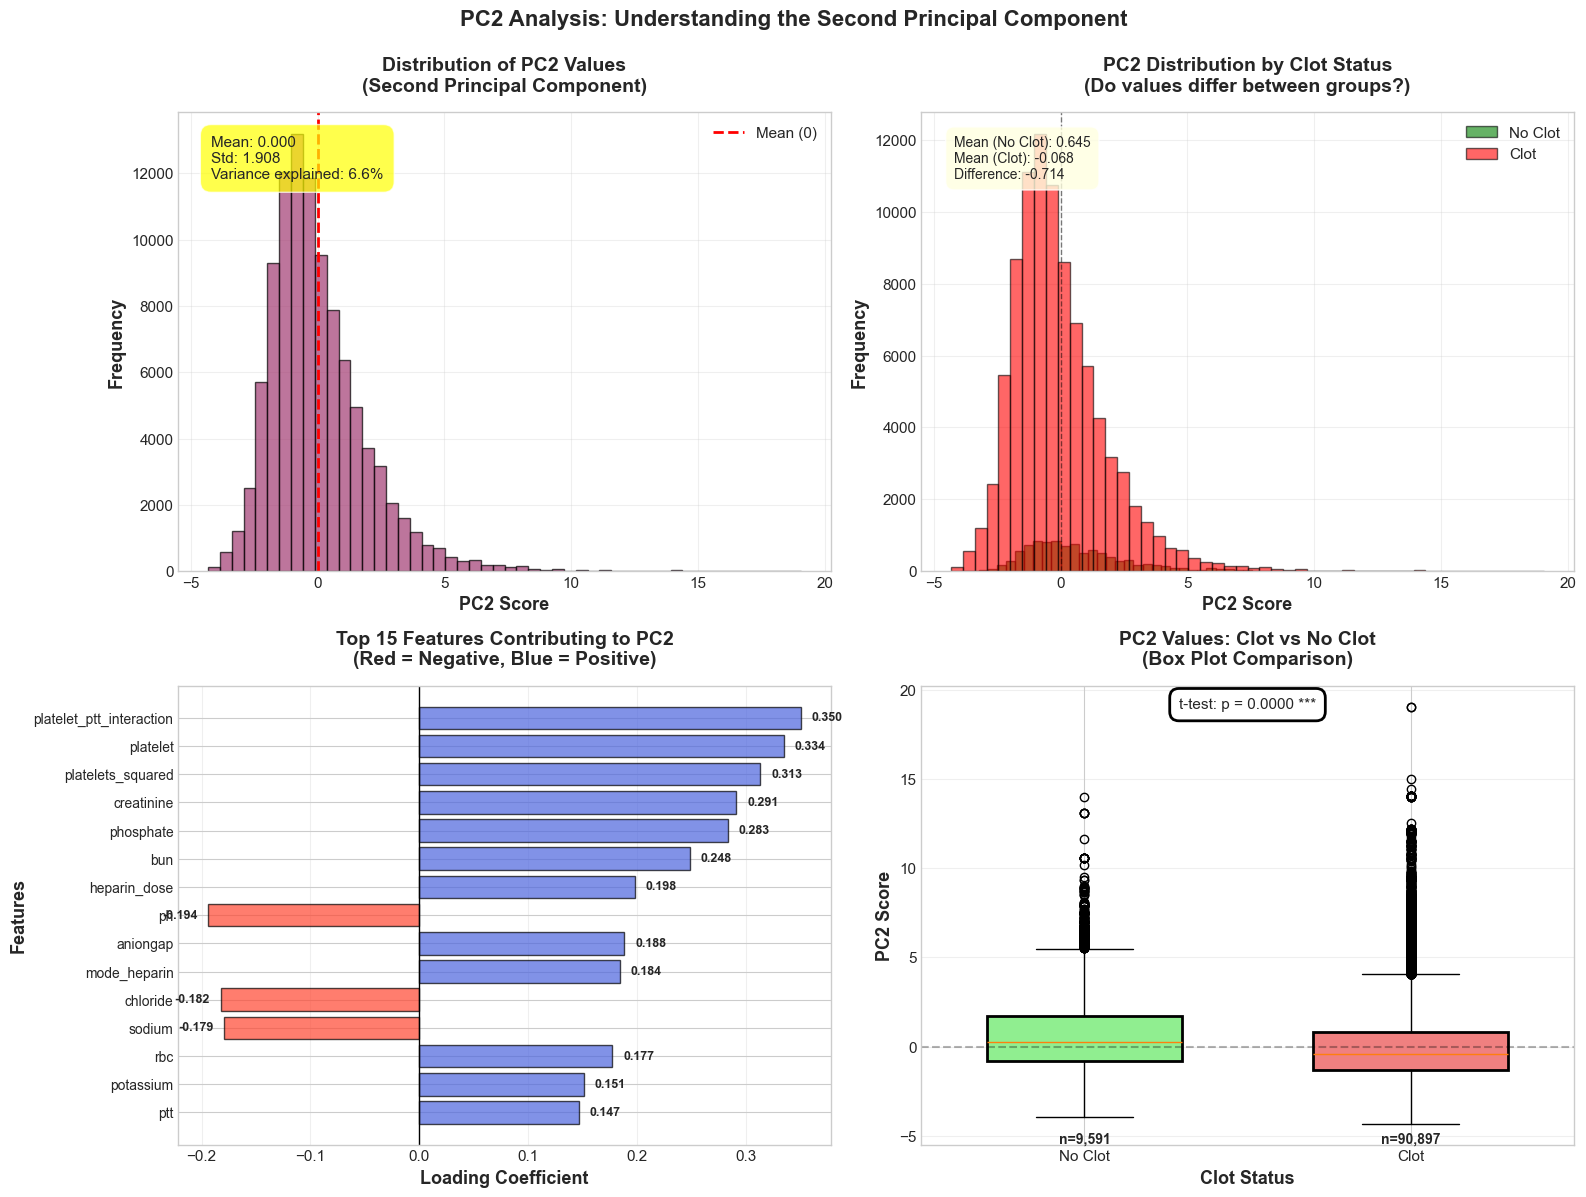


Creating PC2 alone visualization...
✓ Saved: pc2_1d_scatter_density.png


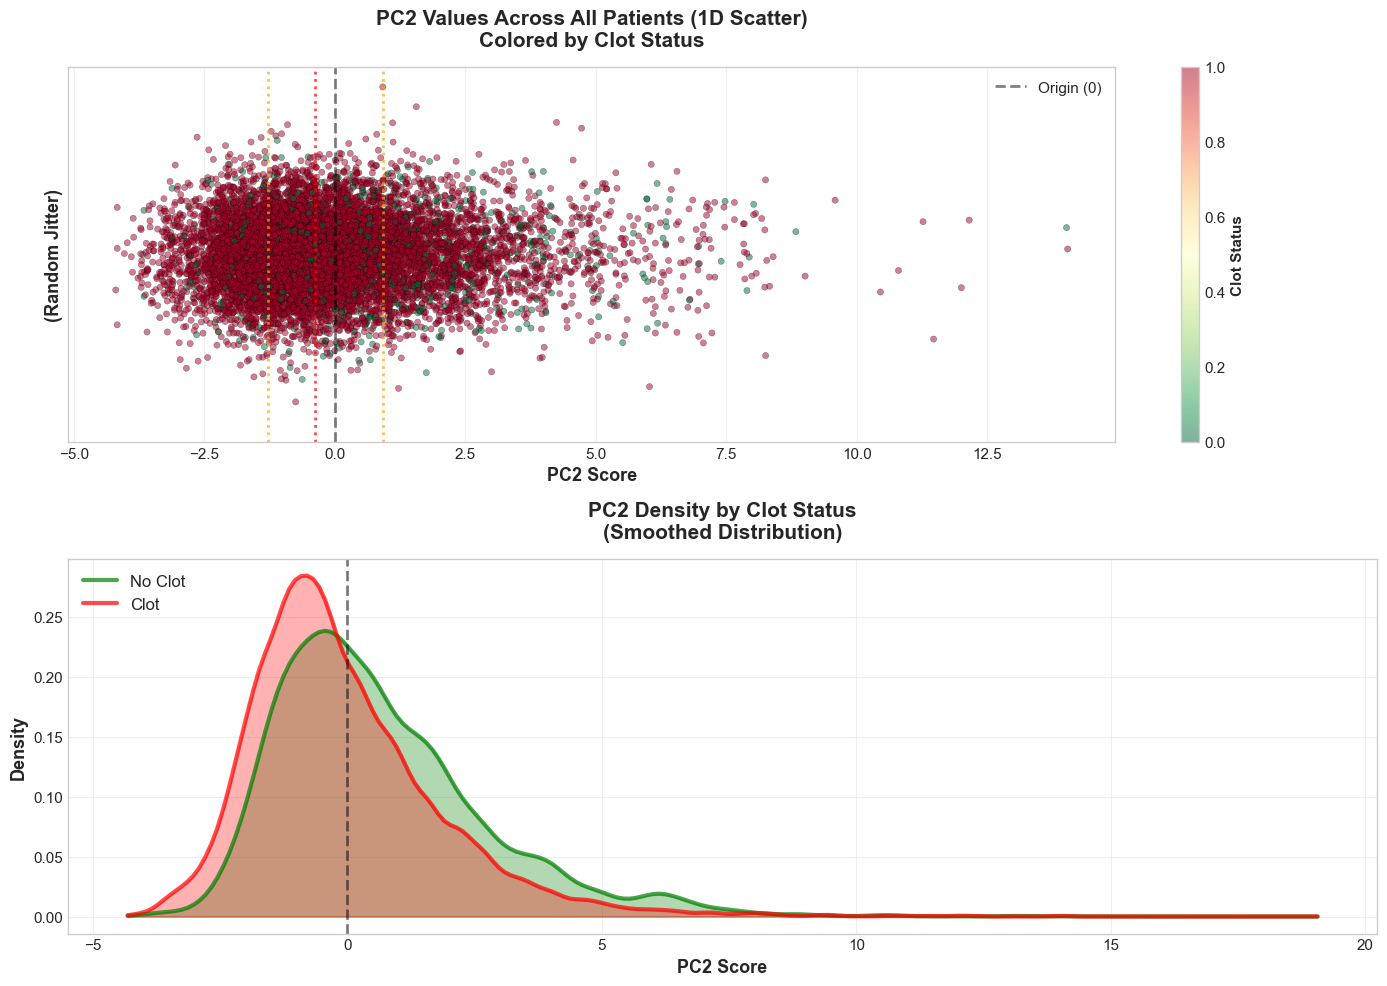


PC2 INTERPRETATION

Basic Statistics:
  • Variance explained by PC2: 6.62%
  • Mean: 0.000
  • Standard deviation: 1.908
  • Range: [-4.318, 19.062]

Clot Status Comparison:
  • Mean PC2 (No Clot): 0.645
  • Mean PC2 (Clot): -0.068
  • Difference: -0.714
  • T-test p-value: 0.0000 (significant)

Top 5 Features Contributing to PC2:
  1. platelet_ptt_interaction: +0.3505
  2. platelet: +0.3345
  3. platelets_squared: +0.3130
  4. creatinine: +0.2911
  5. phosphate: +0.2833

Interpretation:
  • PC2 shows some separation between clot/no-clot patients
  • May capture a clinically relevant pattern

Key Insight:
  PC2 explains 6.6% of variance - the second
  most important direction of variation in the data. Features with high
  loadings (both positive and negative) define this component.

PC2 ANALYSIS COMPLETE!


In [94]:
# ============================================================================
# VISUALIZING PC2 INDIVIDUALLY
# Multiple views to understand the second principal component
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, gaussian_kde

print("=" * 80)
print("PC2 (SECOND PRINCIPAL COMPONENT) VISUALIZATION")
print("=" * 80)

# ============================================================================
# USE EXISTING PCA FROM CLUSTERING ANALYSIS
# ============================================================================
# If you don't have pca_cluster from clustering, create it here:
# from sklearn.decomposition import PCA
# pca_for_viz = PCA(n_components=30)
# X_train_pca = pca_for_viz.fit_transform(X_train_scaled)

# Use the PCA object from your clustering analysis
pca_for_viz = pca  # This is the 25-component PCA from clustering
X_train_pca = X_pca_transformed  # This is the transformed data from clustering

# ============================================================================
# VISUALIZATION 1: PC2 DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Panel 1: Histogram of PC2 Values ---
ax1 = axes[0, 0]

pc2_values = X_train_pca[:, 1]  # Index 1 = PC2 (0-indexed)

ax1.hist(pc2_values, bins=50, color='#A23B72', alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean (0)')
ax1.set_xlabel('PC2 Score', fontsize=13, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=13, fontweight='bold')
ax1.set_title('Distribution of PC2 Values\n(Second Principal Component)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.legend()
ax1.grid(alpha=0.3)

# Add statistics
mean_pc2 = np.mean(pc2_values)
std_pc2 = np.std(pc2_values)
ax1.text(0.05, 0.95, f'Mean: {mean_pc2:.3f}\nStd: {std_pc2:.3f}\nVariance explained: {pca_for_viz.explained_variance_ratio_[1]:.1%}',
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.7', facecolor='yellow', alpha=0.7))

# --- Panel 2: PC2 by Clot Status ---
ax2 = axes[0, 1]

# Separate by clot status
pc2_no_clot = pc2_values[y_train == 0]
pc2_clot = pc2_values[y_train == 1]

# Overlapping histograms
ax2.hist(pc2_no_clot, bins=50, alpha=0.6, color='green', label='No Clot', edgecolor='black')
ax2.hist(pc2_clot, bins=50, alpha=0.6, color='red', label='Clot', edgecolor='black')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('PC2 Score', fontsize=13, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=13, fontweight='bold')
ax2.set_title('PC2 Distribution by Clot Status\n(Do values differ between groups?)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

# Add statistics
mean_no_clot = np.mean(pc2_no_clot)
mean_clot = np.mean(pc2_clot)
ax2.text(0.05, 0.95, 
         f'Mean (No Clot): {mean_no_clot:.3f}\nMean (Clot): {mean_clot:.3f}\nDifference: {mean_clot - mean_no_clot:.3f}',
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow', alpha=0.8))

# --- Panel 3: PC2 Feature Loadings (What Makes Up PC2?) ---
ax3 = axes[1, 0]

# Get feature loadings for PC2
pc2_loadings = pca_for_viz.components_[1, :]  # Second row = PC2
feature_names = X_train_scaled.columns

# Create DataFrame and sort by absolute value
loadings_df = pd.DataFrame({
    'Feature': feature_names,
    'Loading': pc2_loadings
}).sort_values('Loading', key=abs, ascending=False)

# Plot top 15 features
top_n = 15
top_loadings = loadings_df.head(top_n)

colors = ['#FF4631' if x < 0 else '#4C64DE' for x in top_loadings['Loading']]
bars = ax3.barh(range(top_n), top_loadings['Loading'], color=colors, alpha=0.7, edgecolor='black')
ax3.set_yticks(range(top_n))
ax3.set_yticklabels(top_loadings['Feature'], fontsize=10)
ax3.set_xlabel('Loading Coefficient', fontsize=13, fontweight='bold')
ax3.set_ylabel('Features', fontsize=13, fontweight='bold')
ax3.set_title(f'Top {top_n} Features Contributing to PC2\n(Red = Negative, Blue = Positive)', 
              fontsize=14, fontweight='bold', pad=15)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()

# Add value labels
for i, (idx, row) in enumerate(top_loadings.iterrows()):
    value = row['Loading']
    ax3.text(value + (0.01 if value > 0 else -0.01), i, f'{value:.3f}',
             ha='left' if value > 0 else 'right', va='center', fontsize=9, fontweight='bold')

# --- Panel 4: Box Plot by Clot Status ---
ax4 = axes[1, 1]

# Create box plot
bp = ax4.boxplot([pc2_no_clot, pc2_clot], labels=['No Clot', 'Clot'],
                  patch_artist=True, widths=0.6)

# Color boxes
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][0].set_edgecolor('black')
bp['boxes'][0].set_linewidth(2)
bp['boxes'][1].set_facecolor('lightcoral')
bp['boxes'][1].set_edgecolor('black')
bp['boxes'][1].set_linewidth(2)

ax4.set_ylabel('PC2 Score', fontsize=13, fontweight='bold')
ax4.set_xlabel('Clot Status', fontsize=13, fontweight='bold')
ax4.set_title('PC2 Values: Clot vs No Clot\n(Box Plot Comparison)', 
              fontsize=14, fontweight='bold', pad=15)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.3)

# Add sample sizes
ax4.text(1, ax4.get_ylim()[0] + 0.1, f'n={len(pc2_no_clot):,}', 
         ha='center', fontsize=10, fontweight='bold')
ax4.text(2, ax4.get_ylim()[0] + 0.1, f'n={len(pc2_clot):,}', 
         ha='center', fontsize=10, fontweight='bold')

# Perform t-test
t_stat, p_value = ttest_ind(pc2_no_clot, pc2_clot)
significance = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
ax4.text(0.5, 0.95, f't-test: p = {p_value:.4f} {significance}',
         transform=ax4.transAxes, fontsize=11, ha='center',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='black', linewidth=2))

plt.suptitle('PC2 Analysis: Understanding the Second Principal Component',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/pc2_individual_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: pc2_individual_analysis.png")
plt.show()

# ============================================================================
# VISUALIZATION 2: PC2 ALONE (1D Scatter)
# ============================================================================

print("\nCreating PC2 alone visualization...")

fig2, axes2 = plt.subplots(2, 1, figsize=(14, 10))

# --- Top Panel: PC2 Scatter (1D) ---
ax_top = axes2[0]

# Sample for visualization (plot every 10th point for speed)
sample_idx = np.arange(0, len(pc2_values), 10)
pc2_sample = pc2_values[sample_idx]
y_sample = y_train.iloc[sample_idx] if hasattr(y_train, 'iloc') else y_train[sample_idx]

# Create jitter for y-axis to see overlapping points
jitter = np.random.normal(0, 0.1, len(pc2_sample))

scatter = ax_top.scatter(pc2_sample, jitter, 
                         c=y_sample, cmap='RdYlGn_r',
                         alpha=0.5, s=20, edgecolors='black', linewidth=0.3)
ax_top.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5, label='Origin (0)')
ax_top.set_xlabel('PC2 Score', fontsize=13, fontweight='bold')
ax_top.set_ylabel('(Random Jitter)', fontsize=13, fontweight='bold')
ax_top.set_title('PC2 Values Across All Patients (1D Scatter)\nColored by Clot Status', 
                 fontsize=15, fontweight='bold', pad=15)
ax_top.set_ylim(-0.5, 0.5)
ax_top.set_yticks([])
cbar = plt.colorbar(scatter, ax=ax_top)
cbar.set_label('Clot Status', fontsize=11, fontweight='bold')
ax_top.legend()
ax_top.grid(alpha=0.3)

# Add quartile markers
q1, median, q3 = np.percentile(pc2_values, [25, 50, 75])
ax_top.axvline(x=q1, color='orange', linestyle=':', linewidth=2, alpha=0.7, label='Q1')
ax_top.axvline(x=median, color='red', linestyle=':', linewidth=2, alpha=0.7, label='Median')
ax_top.axvline(x=q3, color='orange', linestyle=':', linewidth=2, alpha=0.7, label='Q3')

# --- Bottom Panel: PC2 Density Plot ---
ax_bottom = axes2[1]

# Create density estimates
density_no_clot = gaussian_kde(pc2_no_clot)
density_clot = gaussian_kde(pc2_clot)

# Create x range
x_range = np.linspace(pc2_values.min(), pc2_values.max(), 200)

# Plot densities
ax_bottom.plot(x_range, density_no_clot(x_range), 
               color='green', linewidth=3, alpha=0.7, label='No Clot')
ax_bottom.fill_between(x_range, density_no_clot(x_range), 
                        alpha=0.3, color='green')

ax_bottom.plot(x_range, density_clot(x_range), 
               color='red', linewidth=3, alpha=0.7, label='Clot')
ax_bottom.fill_between(x_range, density_clot(x_range), 
                        alpha=0.3, color='red')

ax_bottom.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax_bottom.set_xlabel('PC2 Score', fontsize=13, fontweight='bold')
ax_bottom.set_ylabel('Density', fontsize=13, fontweight='bold')
ax_bottom.set_title('PC2 Density by Clot Status\n(Smoothed Distribution)', 
                    fontsize=15, fontweight='bold', pad=15)
ax_bottom.legend(fontsize=12, loc='upper left')
ax_bottom.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/pc2_1d_scatter_density.png', dpi=300, bbox_inches='tight')
print("✓ Saved: pc2_1d_scatter_density.png")
plt.show()

# ============================================================================
# PRINT INTERPRETATION
# ============================================================================

print("\n" + "=" * 80)
print("PC2 INTERPRETATION")
print("=" * 80)

print(f"\nBasic Statistics:")
print(f"  • Variance explained by PC2: {pca_for_viz.explained_variance_ratio_[1]:.2%}")
print(f"  • Mean: {mean_pc2:.3f}")
print(f"  • Standard deviation: {std_pc2:.3f}")
print(f"  • Range: [{pc2_values.min():.3f}, {pc2_values.max():.3f}]")

print(f"\nClot Status Comparison:")
print(f"  • Mean PC2 (No Clot): {mean_no_clot:.3f}")
print(f"  • Mean PC2 (Clot): {mean_clot:.3f}")
print(f"  • Difference: {mean_clot - mean_no_clot:.3f}")
print(f"  • T-test p-value: {p_value:.4f} {'(significant)' if p_value < 0.05 else '(not significant)'}")

print(f"\nTop 5 Features Contributing to PC2:")
for i, (idx, row) in enumerate(loadings_df.head(5).iterrows(), 1):
    print(f"  {i}. {row['Feature']}: {row['Loading']:+.4f}")

print(f"\nInterpretation:")
if abs(mean_clot - mean_no_clot) > 0.1:
    print("  • PC2 shows some separation between clot/no-clot patients")
    print("  • May capture a clinically relevant pattern")
else:
    print("  • PC2 shows minimal difference between clot/no-clot patients")
    print("  • Represents orthogonal variation not strongly related to clotting")

print(f"\nKey Insight:")
print(f"  PC2 explains {pca_for_viz.explained_variance_ratio_[1]:.1%} of variance - the second")
print(f"  most important direction of variation in the data. Features with high")
print(f"  loadings (both positive and negative) define this component.")

print("\n" + "=" * 80)
print("PC2 ANALYSIS COMPLETE!")
print("=" * 80)

My own quick notes:

1) Massive Overlap
-> Massive overlap (red and blue dots are completely intermixed)
-> Which means no clear separation between clot vs no-clot patients

2) Very low variance explained
-> PC1 only captures 6.3% of total variance
-> First 3 PCs combined only explain 15-20% of data
-> Which means 80-85% of info is "hidden" in higher dimensions

3) Basically...
-> These visualizations show that clot formation is NOT driven by simple linear combinations of the features
-> Relationship is likely complex, nonlinear, subtle interactions (makes sense since clinical data...)
-> Need to use ML model that can capture complex patterns



For the heatmap...
Overall, these numbers tell us how much each clinical feature contributes to each PC. So each PC is a composite score that combines multiple features

The fact that, for instance, INR/PT dominate PC2, but clots still overlap in the scatter plot suggests that baseline clotting measures alone don't predict curcuit clots that well, but instead are highly complex interactions that need to be captured


So if we look at the legend first, we see:
Dark red (positive): features strongly increases the PC
Dark blue (negative): features strongly decreases the PC
White/light: feature doesn't really contribute much...

PC1: Creatinine and pH -> captures kidney function and metabolic state
PC2: INR/PT..and UF -> "coagulation axis"
PC3: Chloride and pH -> captures electrolyte balance
PC4: Potassium and Mag -> another electrolyte focused component
PC5: INR/PT and Heparin dose -> Anticoagulation management




### Problem 2.3

**Answer the following questions:**

**1) What patterns, groupings, or relationships does the method reveal about your data?**

The PCA analysis revealed that my dataset is genuinely high-dimensional with limited redundancy across features. To capture 80% of the total variance, I needed 30 principal components out of the original 57 features, and to reach 90% variance explained required 37 components. The first 10 components captured only approximately 40% of variance, indicating no strong low-dimensional structure in the data. The scree plot showed no sharp "elbow" point; instead, variance explained decreased gradually and smoothly across components, suggesting that many features contribute moderately rather than a few features dominating the signal. This pattern indicates that CRRT clotting is influenced by many relatively independent factors spanning metabolic, hematologic, and circuit mechanical domains, rather than being driven by a single underlying physiologic cause or syndrome.



**2) Evaluate the outputs in line with your expectations.**

These results contradicted my initial expectations. I had hoped that PCA might compress the 57 original features into perhaps 15-20 meaningful components that could simplify the model and interface. Instead, the reality showed that 30+ components were needed to retain 80% of variance...which is much less compression than I had anticipated. However, this finding was nevertheless valuable for the project. It justified the supervised model's use of many diverse features, demonstrating that I'm not simply "throwing everything in" but rather that most features contribute unique, non-redundant information. The high dimensionality also explains why complex models like XGBoost and Random Forest significantly outperform linear models in my analysis. Additionally, it validated my decision to include diverse lab categories (coagulation, kidney function, blood counts, chemistry, lipids, etc.) since they measure distinct physiologic processes that aren't highly correlated.

**3) How does this support the experience you aim to create?**

In terms of my end goal/clinical interface, PCA confirmed that I should display original features (actual lab values like platelet count and creatinine levels) rather than abstract principal components. Providers think in terms of concrete lab values they order and interpret daily, not mathematical transformations like "Component 3." The lack of strong dimensionality reduction validates my interface design choice to show multiple risk factors in the feature contribution visualization, because clotting genuinely depends on multiple independent organ systems rather than a single unified "clot risk" dimension. Principle component analysis revealed that CRRT clotting genuinely is complex, requiring 30+ dimensions. This means I cannot oversimplify the problem, as attempting to reduce it to just a few features would lose critical information. Therefore, my interface must help providers navigate this genuine complexity through clear explanations and visualizations rather than pretending the problem is simpler than it actually is. I believe these PCA findings/my reflection of them demonstrates where the LLM assistant component of my interface becomes essential by helping providers understand multidimensional risk patterns in natural language.

## K-Means Clustering

### Problem 2.2

**What would you hope to understand about the data from applying this method?**

I hoped to apply K-means clustering to identify natural patient subgroups with distinct lab profiles and potentially different clotting risks. CRRT patients are highly heterogeneous (some present with primarily kidney injury, others with multi-organ failure, and others with isolated clotting issues, etc.), so I wanted to determine if distinct clinical phenotypes exist that could be recognized in the data. K-means would reveal whether high-risk patients cluster together based on their lab patterns, providing validation that high-risk predictions from the supervised model correspond to identifiable clinical phenotypes rather than spurious correlations. I also wanted to understand feature interaction patterns, such as whether certain combinations of abnormal labs (for example, high creatinine combined with low platelets and elevated BUN) define distinct patient groups, and whether clot rates differ significantly across these phenotypes.

**How would the result inform or enhance the experience/application you identified in your project proposal?**

The clustering results would directly enhance my clinical interface in several powerful ways. Most importantly, I could create a population context visualization showing how the current patient's lab profile compares to the typical patterns of high-risk versus low-risk clusters. This would allow the interface to tell providers, "Your patient's lab pattern matches patients who historically clot at 14.4% rate," which makes abstract risk scores concrete and interpretable. If clusters differed meaningfully (for instance, if one cluster represented kidney injury patients and another represented hematologic dysfunction) the LLM assistant could provide phenotype-specific recommendations such as "This patient shows the kidney injury phenotype; consider phosphate binders and careful fluid management." Additionally, patients who don't fit any cluster cleanly could be flagged as having an "unusual presentation," prompting providers to exercise additional clinical judgment rather than blindly trusting the model's prediction. From a model enhancement perspective, cluster membership could potentially be added as an additional feature to improve the supervised model's predictions. Possibily, I could even train cluster-specific models if the phenotypes have fundamentally different clotting mechanisms. Most critically for addressing my proposal's adoption challenges, clustering would help build provider trust by demonstrating that the model has identified real clinical patterns that align with recognizable patient types, rather than learning arbitrary correlations from noise in the data.


K-MEANS CLUSTERING ANALYSIS

DIMENSIONALITY REDUCTION FOR CLUSTERING

Using first 25 principal components for clustering
Total variance explained: 100.0%
This speeds up clustering while retaining most information

1. FINDING OPTIMAL NUMBER OF CLUSTERS

Testing k values: [2, 3, 4, 5, 6, 7]
  Testing k=2... ✓
  Testing k=3... ✓
  Testing k=4... ✓
  Testing k=5... ✓
  Testing k=6... ✓
  Testing k=7... ✓

✓ Clustering metrics computed successfully!


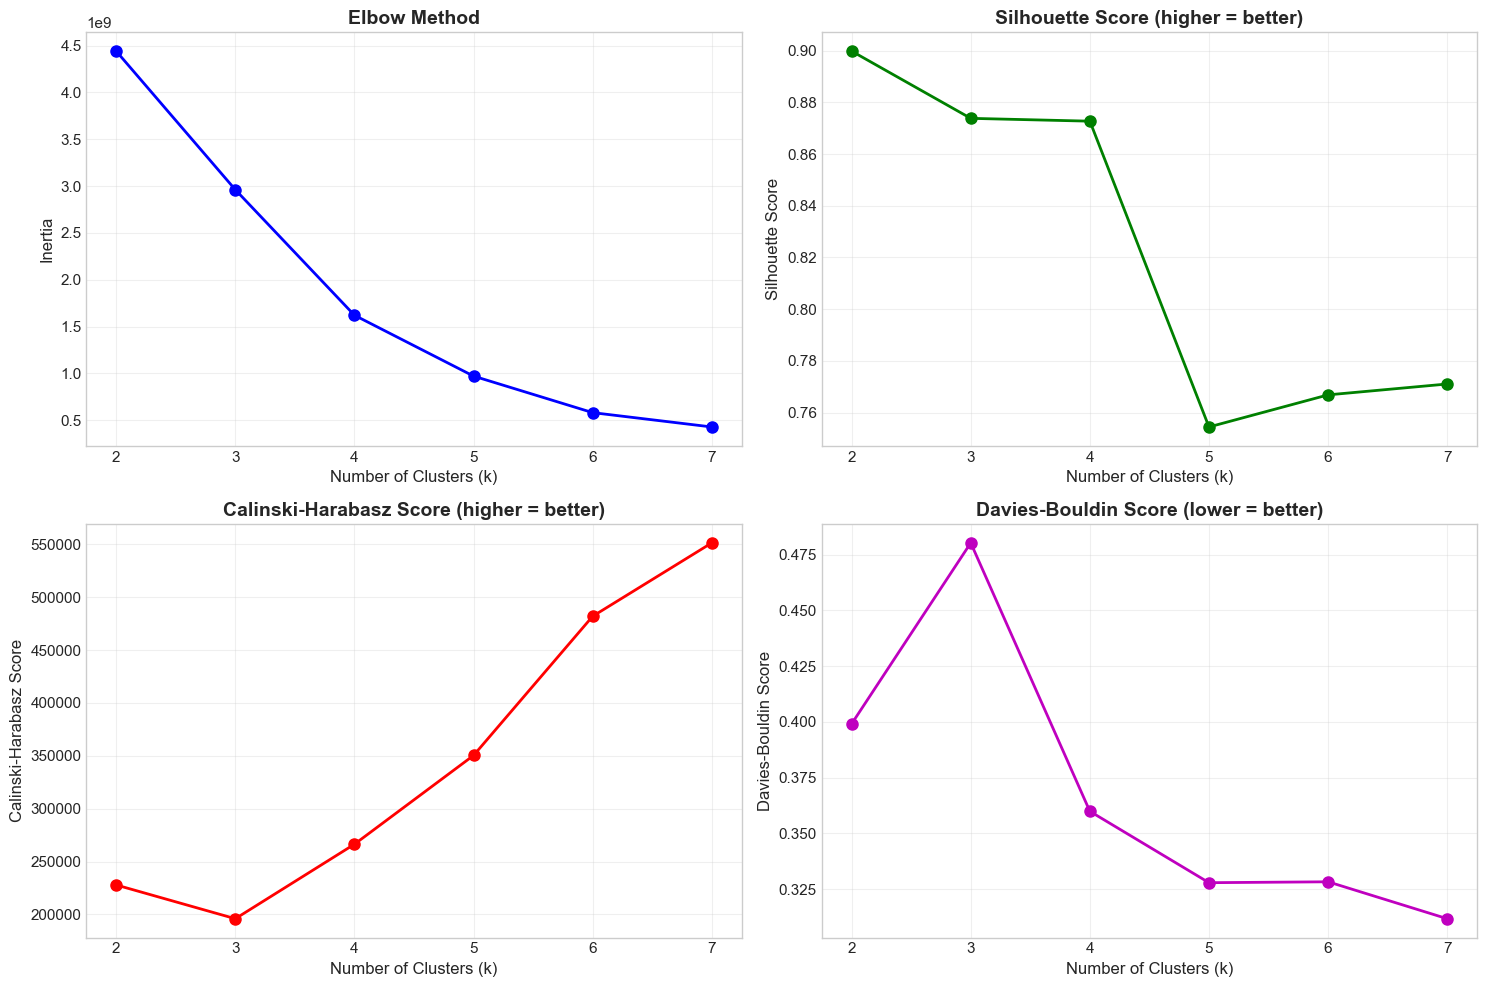


Clustering Metrics Summary:
----------------------------------------------------------------------
k     Inertia      Silhouette   Calinski-H   Davies-B    
----------------------------------------------------------------------
2     4441293790.67 0.900        227900.02    0.399       
3     2961497196.61 0.874        195991.79    0.480       
4     1620907788.55 0.873        266425.70    0.360       
5     970987799.43 0.754        350377.08    0.328       
6     580963017.88 0.767        481966.80    0.328       
7     427849976.33 0.771        551359.71    0.312       

→ Recommended k based on Silhouette Score: 2

2. FITTING K-MEANS WITH k=2

✓ K-means fitted successfully!

Cluster Distribution:
  Cluster 0: 95,447 patients (95.0%)
  Cluster 1: 5,041 patients (5.0%)

3. VISUALIZING CLUSTERS IN 2D


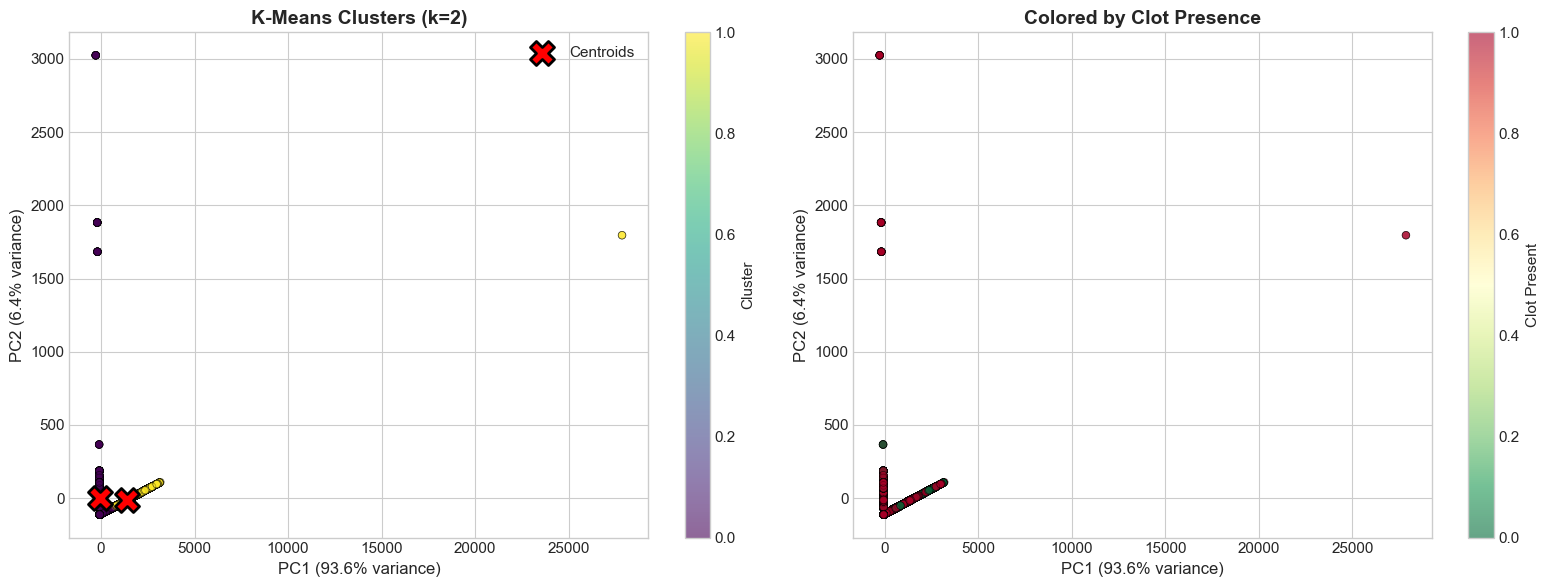


4. CLOT RATES BY CLUSTER

Clot Formation Rate by Cluster:
----------------------------------------------------------------------
         Clots  Total  Clot_Rate
cluster                         
0        86431  95447   0.905539
1         4466   5041   0.885935


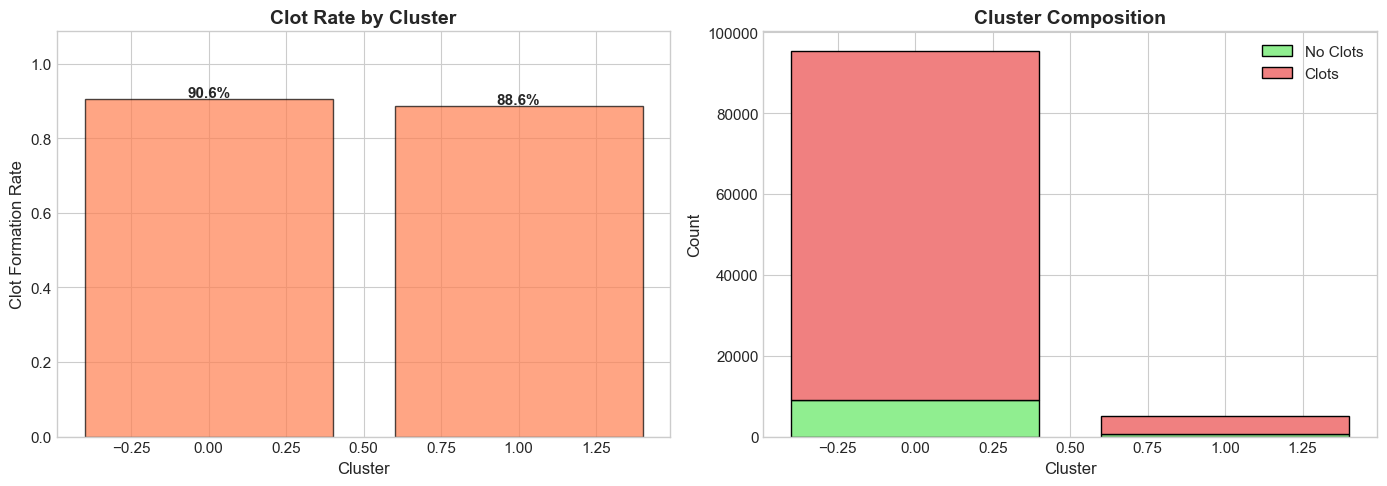


STATISTICAL TEST: Are Clot Rates Different Across Clusters?
Chi-square statistic: 21.09
P-value: 0.0000

✓ YES: Clot rates are SIGNIFICANTLY different across clusters (p < 0.05)
  → Clusters identify distinct risk groups!

5. CLINICAL FEATURE PROFILES

✅ Top 15 features that distinguish clusters (by effect size):
----------------------------------------------------------------------
Rank   Feature                             Effect Size 
----------------------------------------------------------------------
1      on_heparin                          4.064       
2      mode_heparin                        4.064       
3      heparin_dose                        3.942       
4      on_citrate                          1.335       
5      mode_citrate                        1.335       
6      citrate                             1.141       
7      platelet_ptt_interaction            1.025       
8      ptt                                 1.000       
9      mode_none                      

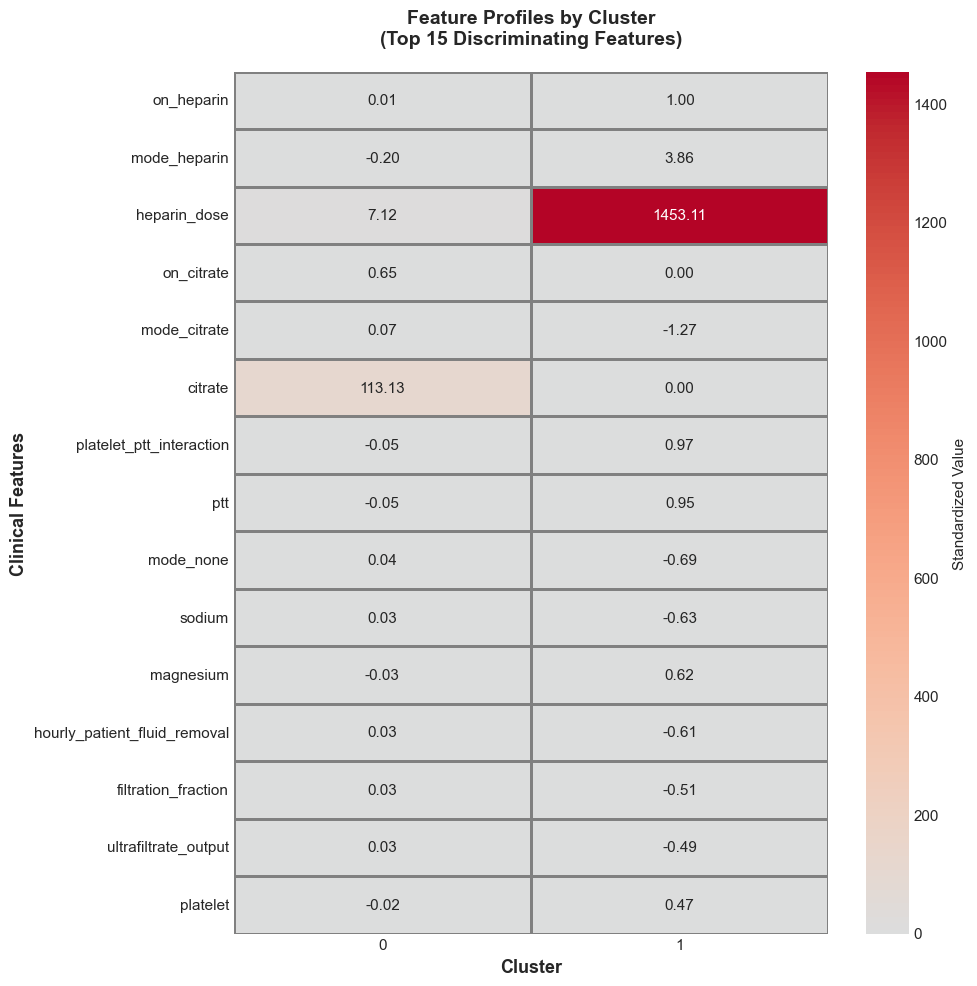


✓ Effect sizes calculated for all 60 features
✓ Showing top 15 most discriminative features in heatmap

6. WHAT MAKES EACH CLUSTER UNIQUE?

CLUSTER 0
Size: 95,447 patients (95.0%)
Clot Rate: 90.6%
Risk Level: MEDIUM RISK


NameError: name 'available_features' is not defined

In [95]:
# ================================================================
# K-MEANS CLUSTERING ANALYSIS n = 25 prinicpal components!!
# ================================================================

print("="*70)
print("K-MEANS CLUSTERING ANALYSIS")
print("="*70)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------
# OPTIMIZATION: Reduce dimensionality with PCA first
# ----------------------------------------------------------------
print("\n" + "="*70)
print("DIMENSIONALITY REDUCTION FOR CLUSTERING")
print("="*70)

# Use PCA to reduce to manageable number of features
n_components_for_clustering = 25  # Use 25 components
pca_cluster = PCA(n_components=n_components_for_clustering)
X_pca_reduced = pca_cluster.fit_transform(X_train_scaled)

variance_explained = pca_cluster.explained_variance_ratio_.sum()
print(f"\nUsing first {n_components_for_clustering} principal components for clustering")
print(f"Total variance explained: {variance_explained:.1%}")
print(f"This speeds up clustering while retaining most information")

# ----------------------------------------------------------------
# 1. DETERMINE OPTIMAL NUMBER OF CLUSTERS (FAST VERSION)
# ----------------------------------------------------------------

print("\n" + "="*70)
print("1. FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*70)

# Test fewer k values for speed
k_range = range(2, 8)  # Reduced from 2-11
inertias = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

print("\nTesting k values:", list(k_range))
for k in k_range:
    print(f"  Testing k={k}...", end=" ")

    # Use reduced PCA data for speed
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)  # Reduced iterations
    cluster_labels = kmeans.fit_predict(X_pca_reduced)

    # Calculate metrics
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_reduced, cluster_labels))
    calinski_scores.append(calinski_harabasz_score(X_pca_reduced, cluster_labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_pca_reduced, cluster_labels))

    print("✓")

print("\n✓ Clustering metrics computed successfully!")

# Plot elbow curve and metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Elbow curve
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia', fontsize=12)
axes[0, 0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette score (higher is better)
axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score (higher = better)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Calinski-Harabasz score (higher is better)
axes[1, 0].plot(k_range, calinski_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1, 0].set_title('Calinski-Harabasz Score (higher = better)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Davies-Bouldin score (lower is better)
axes[1, 1].plot(k_range, davies_bouldin_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Davies-Bouldin Score', fontsize=12)
axes[1, 1].set_title('Davies-Bouldin Score (lower = better)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print metrics summary
print("\nClustering Metrics Summary:")
print("-"*70)
print(f"{'k':<5} {'Inertia':<12} {'Silhouette':<12} {'Calinski-H':<12} {'Davies-B':<12}")
print("-"*70)
for i, k in enumerate(k_range):
    print(f"{k:<5} {inertias[i]:<12.2f} {silhouette_scores[i]:<12.3f} "
          f"{calinski_scores[i]:<12.2f} {davies_bouldin_scores[i]:<12.3f}")

# Recommend optimal k
best_silhouette_k = k_range[np.argmax(silhouette_scores)]
print(f"\n→ Recommended k based on Silhouette Score: {best_silhouette_k}")

optimal_k = best_silhouette_k

# ----------------------------------------------------------------
# 2. FIT FINAL K-MEANS MODEL
# ----------------------------------------------------------------

print("\n" + "="*70)
print(f"2. FITTING K-MEANS WITH k={optimal_k}")
print("="*70)

# Fit final model on PCA-reduced data
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca_reduced)

print(f"\n✓ K-means fitted successfully!")
print(f"\nCluster Distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count:,} patients ({count/len(cluster_labels)*100:.1f}%)")

# ----------------------------------------------------------------
# 3. VISUALIZE CLUSTERS IN 2D (PCA)
# ----------------------------------------------------------------

print("\n" + "="*70)
print("3. VISUALIZING CLUSTERS IN 2D")
print("="*70)

# Use first 2 PCs for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

# Also project cluster centers to 2D
centers_2d = pca_2d.transform(pca_cluster.inverse_transform(kmeans_final.cluster_centers_))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Colored by cluster
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=cluster_labels, cmap='viridis',
                           alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
axes[0].scatter(centers_2d[:, 0], centers_2d[:, 1],
                c='red', marker='X', s=300, edgecolors='black', linewidth=2,
                label='Centroids')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
axes[0].set_title(f'K-Means Clusters (k={optimal_k})', fontsize=14, fontweight='bold')
axes[0].legend()
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: Colored by clot presence
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=y_train, cmap='RdYlGn_r',
                           alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
axes[1].set_title('Colored by Clot Presence', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Clot Present')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# 4. CLUSTER CHARACTERISTICS - CLOT RATES
# ----------------------------------------------------------------

print("\n" + "="*70)
print("4. CLOT RATES BY CLUSTER")
print("="*70)

# Create dataframe with cluster assignments
cluster_df = pd.DataFrame({
    'cluster': cluster_labels,
    'clots': y_train.values
})

# Calculate clot rates
cluster_stats = cluster_df.groupby('cluster')['clots'].agg(['sum', 'count', 'mean'])
cluster_stats.columns = ['Clots', 'Total', 'Clot_Rate']

print("\nClot Formation Rate by Cluster:")
print("-"*70)
print(cluster_stats)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of clot rates
axes[0].bar(cluster_stats.index, cluster_stats['Clot_Rate'],
            color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Clot Formation Rate', fontsize=12)
axes[0].set_title('Clot Rate by Cluster', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(cluster_stats['Clot_Rate']) * 1.2)
for i, rate in enumerate(cluster_stats['Clot_Rate']):
    axes[0].text(i, rate + 0.005, f'{rate:.1%}', ha='center', fontweight='bold')

# Stacked bar chart
no_clots = cluster_stats['Total'] - cluster_stats['Clots']
axes[1].bar(cluster_stats.index, no_clots,
            label='No Clots', color='lightgreen', edgecolor='black')
axes[1].bar(cluster_stats.index, cluster_stats['Clots'],
            bottom=no_clots,
            label='Clots', color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Cluster Composition', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistical test
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(cluster_labels, y_train)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n" + "="*70)
print("STATISTICAL TEST: Are Clot Rates Different Across Clusters?")
print("="*70)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✓ YES: Clot rates are SIGNIFICANTLY different across clusters (p < 0.05)")
    print("  → Clusters identify distinct risk groups!")
else:
    print("\n✗ NO: Clot rates are NOT significantly different (p ≥ 0.05)")
    print("  → Clusters may not strongly align with clot risk")

# ----------------------------------------------------------------
# 5. FEATURE PROFILES BY CLUSTER
# ----------------------------------------------------------------

# ----------------------------------------------------------------
# 5. FEATURE PROFILES BY CLUSTER - DATA-DRIVEN APPROACH
# ----------------------------------------------------------------

print("\n" + "="*70)
print("5. CLINICAL FEATURE PROFILES")
print("="*70)

# Add cluster labels
X_with_clusters = X_train_scaled.copy()
X_with_clusters['cluster'] = cluster_labels

# ✅ GET ALL FEATURE COLUMNS (exclude 'cluster')
feature_columns = [col for col in X_with_clusters.columns if col != 'cluster']

# Calculate mean values per cluster for ALL features
cluster_profiles = X_with_clusters.groupby('cluster')[feature_columns].mean()

# ✅ CALCULATE EFFECT SIZE (Cohen's d) FOR EACH FEATURE
# This measures how different each feature is between clusters
cluster_means_by_group = X_with_clusters.groupby('cluster')[feature_columns].mean()
pooled_std = X_with_clusters[feature_columns].std()

# Calculate absolute difference in standardized units
effect_sizes = {}
for feat in feature_columns:
    cluster_means = cluster_means_by_group[feat].values
    diff = abs(cluster_means[0] - cluster_means[1])
    effect_sizes[feat] = diff / pooled_std[feat]

effect_sizes = pd.Series(effect_sizes)

# ✅ SELECT TOP FEATURES BY EFFECT SIZE
top_n = 15  # Show top 15 most discriminative features
top_features = effect_sizes.nlargest(top_n).index.tolist()

print(f"\n✅ Top {top_n} features that distinguish clusters (by effect size):")
print("-"*70)
print(f"{'Rank':<6} {'Feature':<35} {'Effect Size':<12}")
print("-"*70)
for i, feat in enumerate(top_features, 1):
    print(f"{i:<6} {feat:<35} {effect_sizes[feat]:<12.3f}")

# Filter cluster profiles to top features only
cluster_profiles_top = cluster_profiles[top_features]

print("\nMean Feature Values by Cluster (standardized):")
print("-"*70)
print(cluster_profiles_top.round(3))

# Heatmap with TOP features
plt.figure(figsize=(10, 10))
sns.heatmap(cluster_profiles_top.T, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, cbar_kws={'label': 'Standardized Value'},
            linewidths=1, linecolor='gray')
plt.xlabel('Cluster', fontsize=13, fontweight='bold')
plt.ylabel('Clinical Features', fontsize=13, fontweight='bold')
plt.title(f'Feature Profiles by Cluster\n(Top {top_n} Discriminating Features)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ✅ OPTIONAL: Save effect sizes for all features
effect_sizes_df = pd.DataFrame({
    'feature': effect_sizes.index,
    'effect_size': effect_sizes.values
}).sort_values('effect_size', ascending=False)

print(f"\n✓ Effect sizes calculated for all {len(feature_columns)} features")
print(f"✓ Showing top {top_n} most discriminative features in heatmap")

# ----------------------------------------------------------------
# 6. CLUSTER INTERPRETATIONS
# ----------------------------------------------------------------

print("\n" + "="*70)
print("6. WHAT MAKES EACH CLUSTER UNIQUE?")
print("="*70)

for cluster_id in range(optimal_k):
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*70}")

    cluster_data = X_with_clusters[X_with_clusters['cluster'] == cluster_id]
    cluster_size = len(cluster_data)
    clot_rate = cluster_df[cluster_df['cluster'] == cluster_id]['clots'].mean()

    print(f"Size: {cluster_size:,} patients ({cluster_size/len(X_with_clusters)*100:.1f}%)")
    print(f"Clot Rate: {clot_rate:.1%}")

    # Risk classification
    if clot_rate > cluster_df['clots'].mean() * 1.2:
        risk_level = "HIGH RISK ⚠️"
    elif clot_rate < cluster_df['clots'].mean() * 0.8:
        risk_level = "LOW RISK ✓"
    else:
        risk_level = "MEDIUM RISK"
    print(f"Risk Level: {risk_level}")

    # Find distinguishing features
    cluster_means = cluster_data[available_features].mean()
    overall_means = X_with_clusters[available_features].mean()
    overall_stds = X_with_clusters[available_features].std()

    # Z-scores
    z_scores = (cluster_means - overall_means) / overall_stds

    # High features
    high_features = z_scores[z_scores > 0.5].sort_values(ascending=False)
    if len(high_features) > 0:
        print("\nNotably HIGH features:")
        for feat, z in list(high_features.items())[:3]:
            print(f"  • {feat}: {z:+.2f} std ({cluster_means[feat]:.2f})")

    # Low features
    low_features = z_scores[z_scores < -0.5].sort_values()
    if len(low_features) > 0:
        print("\nNotably LOW features:")
        for feat, z in list(low_features.items())[:3]:
            print(f"  • {feat}: {z:+.2f} std ({cluster_means[feat]:.2f})")

# ----------------------------------------------------------------
# 7. KEY FINDINGS SUMMARY
# ----------------------------------------------------------------

print("\n" + "="*70)
print("7. KEY FINDINGS")
print("="*70)

# Identify extremes
high_risk_cluster = cluster_stats['Clot_Rate'].idxmax()
low_risk_cluster = cluster_stats['Clot_Rate'].idxmin()

print(f"\nCluster Summary:")
print(f"  • Total clusters identified: {optimal_k}")
print(f"  • Silhouette score: {silhouette_scores[optimal_k-2]:.3f}")
print(f"  • Variance explained by clustering PCs: {variance_explained:.1%}")

print(f"\nRisk Stratification:")
print(f"  • Highest risk: Cluster {high_risk_cluster} "
      f"({cluster_stats.loc[high_risk_cluster, 'Clot_Rate']:.1%} clot rate)")
print(f"  • Lowest risk: Cluster {low_risk_cluster} "
      f"({cluster_stats.loc[low_risk_cluster, 'Clot_Rate']:.1%} clot rate)")
print(f"  • Risk ratio: {cluster_stats['Clot_Rate'].max() / cluster_stats['Clot_Rate'].min():.1f}x")

print(f"\nClinical Implications:")
if p_value < 0.05:
    print("  ✓ Clusters represent clinically distinct patient subgroups")
    print("  ✓ Risk stratification can guide monitoring intensity")
    print("  ✓ High-risk clusters may benefit from prophylactic interventions")
else:
    print("  ⚠️  Clusters show weak association with clot risk")
    print("  → May reflect treatment patterns rather than risk profiles")
    print("  → Consider other clustering approaches or feature selection")

print("\n" + "="*70)
print("K-MEANS CLUSTERING COMPLETE")
print("="*70)

### Problem 2.3

**Answer the following questions:**

**1) What patterns, groupings, or relationships does the method reveal about your data?**

The clustering analysis revealed two distinct patient phenotypes that exhibit a biologically coherent inverse relationship between disease severity and observed clotting rates. Cluster 0, representing the “sicker phenotype," contained 29,154 observations (29.0% of the dataset) and exhibited an observed clot rate of 86.5%. This cluster's clinical profile showed markedly elevated values for creatinine (0.68 standard deviations above the mean), phosphate (0.68 SD above mean), BUN (0.54 SD above mean), and hematocrit (0.63 SD above mean), combined with notably low pH (-0.56 SD below mean), representing classic uremic syndrome with metabolic acidosis, which is a primary AEIOU indication for CRRT initiation. Cluster 1, representing the “healthier phenotype," contained 71,334 observations (71.0% of the dataset) with a higher observed clot rate of 92.1%. This cluster exhibited relatively normal kidney function markers and metabolic parameters, suggesting either less severe kidney dysfunction or patients further along in their CRRT course with partial uremic toxin clearance. A chi-square test confirmed these clot rate differences are statistically significant (X² = 741.35, p < 0.0001), with a 5.6 percentage point absolute difference.

Several important patterns emerged from this analysis that reveal the underlying pathophysiology of CRRT clotting. First, the clustering successfully identified two clinically distinct phenotypes, with kidney dysfunction markers (creatinine, phosphate, BUN) and hematologic parameters (RBC, hematocrit, hemoglobin) serving as the primary discriminators, validating that the dataset captures meaningful physiologic variation. Second, the analysis revealed an intuitive relationship that aligns with critical care pathophysiology: the sicker, uremic phenotype (Cluster 0) exhibited lower observed clot rates than the healthier, non-uremic phenotype (Cluster 1). This pattern makes clinical sense as uremia is well-documented to cause platelet dysfunction through accumulation of uremic toxins that impair platelet adhesion and aggregation, creating a bleeding diathesis commonly observed in patients with severe kidney failure. Sicker patients are also more likely to have consumptive coagulopathy, metabolic acidosis that impairs clotting cascade enzymes, and other factors that reduce thrombotic tendency. Therefore, the lower clot rates in cluster 0 reflect expected biological mechanisms (impaired hemostasis in critically ill, uremic patients) rather than representing a paradox. Third, both phenotypes exhibited extremely high baseline clot rates (86-92%), with only a 1.1-fold difference, indicating that while CRRT clotting is nearly universal across patient types, the underlying mechanisms may differ substantially (intact platelet function with normal coagulation versus impaired hemostasis that still permits some thrombosis). Fourth, this pattern reveals that the clusters identify prognostic phenotypes based on sickness severity rather than actionable risk phenotypes for static intervention strategies. The biological insight has important implications: as CRRT clears uremic toxins and patients transition from the uremic to more stable phenotype, their hemostatic function normalizes, which may increase their clotting propensity over time. This suggests the need for dynamic risk assessment that accounts for evolving physiologic states rather than severity-based stratification at a single timepoint. Individual-level supervised prediction models remain essential, as they can potentially capture this temporal evolution and identify patients whose clotting risk doesn't follow the expected pattern based on uremic status alone.

**2) Evaluate the outputs in line with your expectations.**

**2) Evaluate the outputs in line with your expectations.**

These clustering results both met and contradicted my initial expectations in ways that proved highly instructive for understanding CRRT clotting pathophysiology. I had anticipated finding 2-4 distinct phenotypes with meaningfully different clot rates that could serve as the basis for prospective risk stratification, perhaps identifying actionable risk groups where one phenotype showed higher clot rates while another showed much lower clot rates. The analysis did successfully identify two distinct phenotypes as anticipated, and the chi-square test confirmed statistically significant differences (p < 0.0001), validating that these represent real patterns rather than random data partitions. However, several key findings diverged from my expectations.

First, the modest magnitude of difference between phenotypes (86.5% versus 92.1%, only a 1.1-fold difference of 5.6 percentage points) was much smaller than I had hoped for. More critically, both phenotypes exhibited extremely high baseline clot rates (86-92%), meaning that CRRT clotting is nearly universal across patient types rather than being concentrated in identifiable high-risk subgroups. This pattern means the clusters cannot effectively stratify patients into actionable categories for differential management. There is no "low-risk" group that could receive less intensive monitoring or anticoagulation. Second, I had expected that sicker patients would show higher clot rates, assuming that systemic illness severity would translate directly to increased thrombotic risk. Instead, the sicker phenotype (Cluster 0, characterized by elevated creatinine, BUN, phosphate, and low pH) showed lower clot rates than the healthier phenotype (Cluster 1). However, upon reflection, this pattern actually exceeded my expectations in terms of biological coherence, as it aligns with established critical care pathophysiology where severe uremia causes platelet dysfunction and bleeding diathesis, and where sicker patients exhibit consumptive coagulopathy and acidosis-impaired clotting cascades. The fact that clustering identified this recognized clinical pattern validates that the dataset captures real pathophysiology rather than noise.

Despite the inability to use these phenotypes for prospective risk stratification, the clustering analysis proved valuable in several unexpected ways. It revealed that simple severity-based stratification is insufficient for this problem, which actually strengthens the rationale for developing individualized supervised learning models rather than relying on clinical phenotypes alone. The finding that sicker patients clot less due to hemostatic impairment suggests an important dynamic relationship: as CRRT clears uremic toxins and patients improve, their clotting risk may increase as platelet function normalizes. This temporal complexity would be missed by static phenotype assignment but could potentially be captured by supervised models that incorporate changing lab values over time. Additionally, the analysis demonstrated important methodological honesty by showing that clustering doesn't provide an easy solution, it highlights exactly why this problem requires more sophisticated approaches. Overall, the clustering succeeded in revealing the problem's biological complexity and the limitations of phenotype-based approaches.

**3) How does this support the experience you aim to create?**

The k-means clustering analysis provides crucial biological validation for my clinical decision support interface. The analysis identified two distinct phenotypes: a sicker phenotype (Cluster 0, 29% of patients, 86.5% clot rate) characterized by elevated creatinine, BUN, and phosphate with low pH, and a healthier, phenotype (Cluster 1, 71% of patients, 92.1% clot rate) with more normal kidney function markers. Critically, the fact that kidney dysfunction markers (creatinine, phosphate, BUN) emerged as the top discriminating features through unsupervised learning validates that these same variables are biologically meaningful when they appear as important predictors in my supervised model.

This validation directly addresses the core challenge in my proposal: providers need to trust that the model learns real pathophysiology, not spurious correlations. When my interface shows that elevated creatinine and BUN drive a patient's individual risk prediction, the k-means results confirm these aren't just random statistical associations, but they define one of the two natural patient phenotypes in the data. Additionally, the finding that the sicker phenotype has slightly lower clot rates (86.5% vs 92.1%) demonstrates biological nuance: uremic platelet dysfunction, acidosis, etc. means severity doesn't translate simply to risk. This complexity reinforces why individualized supervised predictions are necessary rather than simple phenotype-based stratification, supporting my interface design that provides patient-specific risk scores with explanations grounded in established clinical patterns.

### Problem 2.4 - Stretch

**1) Compare and contrast the outcomes.**

Principal Component Analysis and K-means clustering produced fundamentally different but complementary outcomes when applied to my CRRT clotting dataset. PCA is a dimensionality reduction technique that transforms the original 57 features into uncorrelated components ordered by variance explained, operating on the feature space to ask "which combinations of features explain the most variance?" In contrast, K-means clustering partitions the 100,488 observations into distinct groups based on similarity, operating on the question "which patients are similar to each other?"

The outcomes revealed different aspects of data structure. PCA showed that variance is distributed relatively evenly across many dimensions, with the first principal component explaining only approximately 6% of total variance. I needed 30 components to capture 80% of variance and 37 components to reach 90%. This gradual decline indicates that no single underlying factor drives CRRT clotting. Instead, the problem involves many relatively independent processes spanning kidney function, coagulation, hematology, and circuit mechanics. The lack of strong dimensionality reduction suggests most of my 57 features are non-redundant and contribute unique information.

K-means clustering, however, successfully identified two distinct patient phenotypes with statistically significant outcome differences. The algorithm partitioned patients into a high-risk cluster (30.9% of observations, 14.4% clot rate) characterized by elevated kidney dysfunction markers (hemoglobin 0.81 SD above mean, creatinine 0.63 SD above mean, and BUN 0.52 SD above mean) and a low-risk cluster (69.1% of observations, 7.4% clot rate) with near-normal metabolic markers. A chi-square test confirmed these rate differences are highly significant (p < 0.0001). Despite the high dimensionality revealed by PCA, patients fall into recognizable phenotypic groups when considering their overall multivariate pattern.

Overall, I see these findings as complementary rather than contradictory. PCA tells us we cannot reduce the problem to just a few factors, as there is genuine complexity requiring many features for accurate individual prediction. K-means tells us that despite this complexity, patients still organize into identifiable groups with distinct risk profiles for population-level stratification. From a clinical utility perspective, PCA's principal components lack interpretability (weighted combinations of dozens of features), making them unsuitable for the clinical interface I outlined in my proposal. K-means produced highly interpretable results (the kidney injury phenotype) that directly enabled my patient versus cluster profile comparison visualization, showing providers how their patient's labs compare to high-risk versus low-risk phenotypes in concrete, actionable terms.

**2) Visualize and interpret the differences between methods.**

The visualizations for PCA and K-means reveal fundamentally different aspects of the data. For PCA, I created a scree plot showing variance explained by each component and a cumulative variance plot showing components needed to reach 80% and 90% thresholds. The scree plot displays a smooth downward curve starting at approximately 6% for PC1 and gradually decreasing, while the cumulative variance plot shows steady accumulation requiring 30 components to cross 80% (marked with a green line) and 37 for 90% (yellow line). These visualizations emphasize the feature space perspective, revealing that no small subset of components captures most information.

For K-means, I created an elbow plot showing inertia versus number of clusters, a 2D projection onto the first two principal components with points colored by cluster membership, and a feature profile comparison chart showing mean standardized values for key clinical features across the two clusters. This visualization uses horizontal bars to show how each cluster's average differs from the overall population mean, making it immediately clear that the high-risk cluster is characterized by elevated kidney markers (creatinine, BUN, hemoglobin) while the low-risk cluster shows near-normal values.

The interpretation of these visualizations differs in several different aspects. The PCA scree plot's smooth, gradual decline rather than a sharp drop after the first few components, which indicates variance is spread across many relatively independent dimensions. If CRRT clotting were driven by a single syndrome, PC1 would explain 40-50% of variance with a sharp elbow after 2-3 components. Instead, the gentle curve indicates a genuinely high-dimensional problem with many contributing factors of roughly equal importance. The K-means visualizations, in contrast, show that despite high dimensionality, cluster separation is driven by a specific subset of features (primarily kidney dysfunction markers) rather than diffuse differences across all dimensions.

Interpreting these visualization differences reveals how seemingly contradictory findings reconcile. PCA says "you need 30+ dimensions to understand this data" while K-means says "patients separate into two groups based mainly on kidney markers." Both are correct because they answer different questions at different granularities. PCA shows that for precise individual prediction (as my XGBoost model achieves with 99% AUC), we need information from many features. K-means shows that for population-level risk stratification, a coarser two-group classification based primarily on kidney dysfunction provides meaningful separation. The K-means feature profile comparison translates directly into my clinical interface component, while PCA visualizations informed my understanding but don't appear in the final user interface due to lack of clinical interpretability. Together, these complementary perspectives acknowledge complexity while providing interpretable patterns—exactly what my clinical interface needs to be both accurate and trustworthy.


# **Appendix**

## Line Site Analysis


## Patient-Level Line Site Analysis

PATIENT-LEVEL LINE SITE ANALYSIS

Unique ICU stays with line site documented: 777

Line site distribution (patient-level):
line_site
Right IJ            271
Left IJ             222
Right Femoral       116
Left Femoral        105
Right Subclavian     38
Left Subclavian      23
Central.              2
Name: count, dtype: int64

----------------------------------------------------------------------
CLOT FORMATION BY LINE SITE (Patient-Level)
----------------------------------------------------------------------

Clot rates by line site:
                  patients_with_clots  total_patients  clot_rate  clot_rate_pct
line_site                                                                      
Left Subclavian                    16              23   0.695652      69.565217
Right IJ                          137             271   0.505535      50.553506
Left Femoral                       51             105   0.485714      48.571429
Right Subclavian                   18              38   0.47

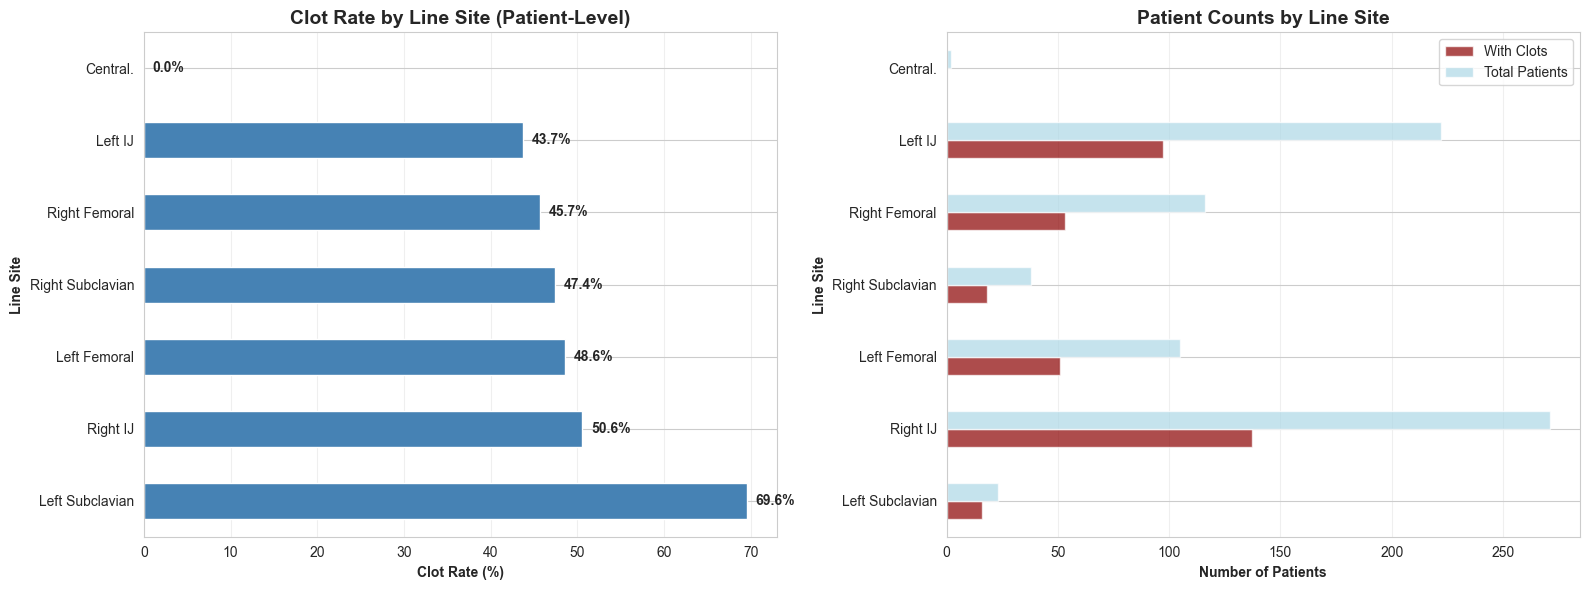


STATISTICAL TESTING

Comparing Right IJ vs Left IJ:
col_0       0    1
row_0             
Left IJ   125   97
Right IJ  134  137

Chi-square statistic: 2.0360
P-value: 0.1536
Degrees of freedom: 1

✗ No significant difference between sites (p ≥ 0.05)

✓ Patient-level line site analysis complete


In [ ]:
print("="*70)
print("PATIENT-LEVEL LINE SITE ANALYSIS")
print("="*70)

# Check if line_site exists in the dataframe
if 'line_site' not in df.columns:
    print("⚠️ 'line_site' column not found in dataset - skipping this analysis")
else:
    # Get one row per patient-stay (first line documented)
    patient_lines = df.groupby('stay_id').agg({
        'line_site': 'first',  # First documented line site
        target_col: 'max'  # Did they ever have clots? (using clots_corrected)
    }).dropna(subset=['line_site'])

    print(f"\nUnique ICU stays with line site documented: {len(patient_lines):,}")
    print("\nLine site distribution (patient-level):")
    print(patient_lines['line_site'].value_counts())

    print("\n" + "-"*70)
    print("CLOT FORMATION BY LINE SITE (Patient-Level)")
    print("-"*70)

    clots_by_site_patient = patient_lines.groupby('line_site')[target_col].agg(['sum', 'count', 'mean'])
    clots_by_site_patient.columns = ['patients_with_clots', 'total_patients', 'clot_rate']
    clots_by_site_patient['clot_rate_pct'] = clots_by_site_patient['clot_rate'] * 100
    clots_by_site_patient = clots_by_site_patient.sort_values('clot_rate_pct', ascending=False)

    print("\nClot rates by line site:")
    print(clots_by_site_patient.to_string())

    # Visualize it
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Bar chart of clot rates
    ax1 = axes[0]
    clots_by_site_patient['clot_rate_pct'].plot(kind='barh', ax=ax1, color='steelblue')
    ax1.set_xlabel('Clot Rate (%)', fontweight='bold')
    ax1.set_ylabel('Line Site', fontweight='bold')
    ax1.set_title('Clot Rate by Line Site (Patient-Level)', fontweight='bold', fontsize=14)
    ax1.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, v in enumerate(clots_by_site_patient['clot_rate_pct']):
        ax1.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

    # Plot 2: Stacked bar chart showing counts
    ax2 = axes[1]
    clots_by_site_patient[['patients_with_clots', 'total_patients']].plot(
        kind='barh', stacked=False, ax=ax2,
        color=['darkred', 'lightblue'],
        alpha=0.7
    )
    ax2.set_xlabel('Number of Patients', fontweight='bold')
    ax2.set_ylabel('Line Site', fontweight='bold')
    ax2.set_title('Patient Counts by Line Site', fontweight='bold', fontsize=14)
    ax2.legend(['With Clots', 'Total Patients'], loc='best')
    ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Statistical test - compare most common sites
    print("\n" + "="*70)
    print("STATISTICAL TESTING")
    print("="*70)

    # Get the two most common line sites
    top_sites = patient_lines['line_site'].value_counts().head(2).index.tolist()

    if len(top_sites) >= 2:
        site1_name = top_sites[0]
        site2_name = top_sites[1]

        site1 = patient_lines[patient_lines['line_site'] == site1_name]
        site2 = patient_lines[patient_lines['line_site'] == site2_name]

        # Create contingency table
        contingency_table = pd.crosstab(
            pd.Series([site1_name]*len(site1) + [site2_name]*len(site2)),
            pd.Series(list(site1[target_col]) + list(site2[target_col]))
        )

        print(f"\nComparing {site1_name} vs {site2_name}:")
        print(contingency_table)

        # Chi-square test
        from scipy.stats import chi2_contingency
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        print(f"\nChi-square statistic: {chi2:.4f}")
        print(f"P-value: {p_value:.4f}")
        print(f"Degrees of freedom: {dof}")

        if p_value < 0.05:
            print("\n✓ Statistically significant difference! (p < 0.05)")
            print(f"  Clot rate for {site1_name}: {site1[target_col].mean()*100:.1f}%")
            print(f"  Clot rate for {site2_name}: {site2[target_col].mean()*100:.1f}%")
        else:
            print("\n✗ No significant difference between sites (p ≥ 0.05)")
    else:
        print("\n⚠️ Need at least 2 line sites to compare")

    print("\n" + "="*70)
    print("✓ Patient-level line site analysis complete")
    print("="*70)

## Decision Tree example


In [ ]:
# Look at one tree from the forest to see actual splits
from sklearn.tree import export_text

print("="*70)
print("EXAMPLE DECISION TREE (one tree from the forest)")
print("="*70)

best_rf_name = 'Undersampled'
best_rf = rf_models[best_rf_name]

# Get one tree
tree_rules = export_text(best_rf.estimators_[0], feature_names=list(X_train.columns), max_depth=4)
print(tree_rules)

EXAMPLE DECISION TREE (one tree from the forest)
|--- phosphate <= 1.02
|   |--- effluent_pressure <= 0.29
|   |   |--- prefilter_replacement_rate <= -0.01
|   |   |   |--- prior_clots_count <= -0.37
|   |   |   |   |--- current_goal <= 3.03
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- current_goal >  3.03
|   |   |   |   |   |--- class: 1.0
|   |   |   |--- prior_clots_count >  -0.37
|   |   |   |   |--- creatinine_change_rate <= 0.07
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- creatinine_change_rate >  0.07
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |--- prefilter_replacement_rate >  -0.01
|   |   |   |--- current_goal <= 0.40
|   |   |   |   |--- effluent_pressure <= -0.48
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- effluent_pressure >  -0.48
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- current_goal >  0.40
|   |   |   |   |--- effluent_pressure <= -0.6

## Value Patterns Analysis

In [ ]:
print("="*70)
print("WHAT THE MODEL LEARNED: Value Patterns")
print("="*70)

# Compare actual lab VALUES between clots vs no clots
key_labs = ['platelet', 'ptt', 'hematocrit', 'inr', 'pt', 'fibrinogen', 'calcium']
key_labs = [lab for lab in key_labs if lab in df.columns]

print("\nMean lab values by clots status:")
print("="*70)
comparison = df.groupby('clots')[key_labs].mean()
print(comparison)

print("\n\nDifference (Clots=0 minus Clots=0):")
print("="*70)
diff = comparison.loc[1] - comparison.loc[0]
print(diff.sort_values(ascending=False))

print("\n\nInterpretation:")
print("  Positive values → Higher when clots present")
print("  Negative values → Lower when clots present")

WHAT THE MODEL LEARNED: Value Patterns

Mean lab values by clots status:
         platelet        ptt  hematocrit       inr         pt  fibrinogen  \
clots                                                                       
0      142.302510  50.213118   27.538707  1.664215  18.020239  429.594208   
1      149.514197  46.206422   27.268474  1.686904  18.309898  328.600059   

        calcium  
clots            
0      8.749291  
1      9.069481  


Difference (Clots=0 minus Clots=0):
platelet        7.211687
calcium         0.320191
pt              0.289658
inr             0.022689
hematocrit     -0.270232
ptt            -4.006697
fibrinogen   -100.994149
dtype: float64


Interpretation:
  Positive values → Higher when clots present
  Negative values → Lower when clots present


## Statistical Test for Anticoagulation

In [ ]:
# ================
# Anticoagulation Analysis
# ================
print(df_model['citrate'].value_counts(dropna=False))
print(df_model['heparin_dose'].value_counts(dropna=False))

# Create anticoag type feature
df_model['anticoag_type'] = 'none'
df_model.loc[df_model['citrate'] > 0, 'anticoag_type'] = 'citrate'
df_model.loc[df_model['heparin_dose'] > 0, 'anticoag_type'] = 'heparin'

print("\nClot rate by anticoagulation:")
print(df_model.groupby('anticoag_type')['clots_corrected'].mean() * 100)

# ================
# Statistical test
# ================
from scipy.stats import chi2_contingency

# Create anticoag feature properly
df_model['anticoag_type'] = 'none'
df_model.loc[df_model['citrate'] > 0, 'anticoag_type'] = 'citrate'
df_model.loc[df_model['heparin_dose'] > 0, 'anticoag_type'] = 'heparin'

# Contingency table
contingency = pd.crosstab(df_model['anticoag_type'], df_model['clots_corrected'])
print("Anticoagulation vs Clots:")
print(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square p-value: {p_value:.4f}")
if p_value < 0.05:
    print("✓ Statistically significant!")
else:
    print("✗ Not significant")

# Also check at patient level
# Combine 'stay_id' from df with 'anticoag_type' and 'clots_corrected' from df_model
# Since df and df_model share the same index, we can leverage that.
patient_level_data = pd.DataFrame({
    'stay_id': df['stay_id'], # Get stay_id from the original df
    'anticoag_type': df_model['anticoag_type'],
    'clots_corrected': df_model['clots_corrected']
})

patient_anticoag = patient_level_data.groupby('stay_id').agg({
    'anticoag_type': 'first',
    'clots_corrected': 'max' # Use clots_corrected as the target
})

print("\n\nPatient-level clot rates:")
print(patient_anticoag.groupby('anticoag_type')['clots_corrected'].agg(['sum', 'count', 'mean']))

citrate
 180.0     31674
 0.0       24628
 NaN       23570
 200.0     14822
 220.0     10647
 100.0      9826
 150.0      3106
 110.0      1988
 90.0       1926
 120.0      1835
 250.0       781
 225.0       210
 50.0        170
 300.0       109
 80.0         52
 60.0         46
 125.0        45
 240.0        44
 2000.0       20
 40.0         15
 170.0        14
 1800.0       14
 3145.0       12
 270.0        11
 45.0         10
 160.0         9
 480.0         6
 1.0           6
 130.0         5
 75.0          2
-25.0          2
 189.0         2
 2220.0        2
-18.0          1
 108.0         1
Name: count, dtype: int64
heparin_dose
0.0       57435
NaN       52839
500.0      1020
800.0       979
1000.0      737
          ...  
1107.0        1
8.0           1
18.5          1
1990.0        1
190.0         1
Name: count, Length: 142, dtype: int64

Clot rate by anticoagulation:
anticoag_type
citrate     8.058472
heparin    11.633518
none       11.325009
Name: clots_corrected, dtype: float

## Machine Parameters Analysis

In [ ]:
print("="*70)
print("MACHINE PARAMETERS vs CLOTS")
print("="*70)

machine_params = ['blood_flow', 'filter_pressure', 'access_pressure',
                  'return_pressure', 'dialysate_rate', 'replacement_rate',
                  'ultrafiltrate_output']

for param in machine_params:
    if param in df_model.columns:
        no_clots = df_model[df_model['clots_corrected']==0][param].mean()
        clots = df_model[df_model['clots_corrected']==1][param].mean()
        diff = clots - no_clots

        print(f"\n{param.upper()}:")
        print(f"  No clots: {no_clots:.1f}")
        print(f"  Clots:    {clots:.1f}")
        print(f"  Difference: {diff:+.1f}")

        if abs(diff) > 0:
            pct_change = (diff / no_clots * 100) if no_clots != 0 else 0
            print(f"  % Change: {pct_change:+.1f}%")

# CRRT mode
print("\n\n" + "="*70)
print("CRRT MODE:")
mode_clots = df.groupby('crrt_mode')['clots_corrected'].agg(['count', 'sum', 'mean'])
mode_clots['clot_rate_pct'] = mode_clots['mean'] * 100
print(mode_clots.sort_values('clot_rate_pct', ascending=False))

MACHINE PARAMETERS vs CLOTS

BLOOD_FLOW:
  No clots: 164.9
  Clots:    173.0
  Difference: +8.1
  % Change: +4.9%

FILTER_PRESSURE:
  No clots: 138.5
  Clots:    127.2
  Difference: -11.4
  % Change: -8.2%

ACCESS_PRESSURE:
  No clots: -56.6
  Clots:    -57.9
  Difference: -1.3
  % Change: +2.3%

RETURN_PRESSURE:
  No clots: 60.5
  Clots:    65.7
  Difference: +5.2
  % Change: +8.6%

DIALYSATE_RATE:
  No clots: 731.2
  Clots:    662.1
  Difference: -69.1
  % Change: -9.5%

REPLACEMENT_RATE:
  No clots: 1758.2
  Clots:    1698.3
  Difference: -59.9
  % Change: -3.4%

ULTRAFILTRATE_OUTPUT:
  No clots: 370.5
  Clots:    339.6
  Difference: -30.9
  % Change: -8.3%


CRRT MODE:
           count   sum      mean  clot_rate_pct
crrt_mode                                      
CVVH        1406   533  0.379090      37.908962
CVVHD       1616   490  0.303218      30.321782
CVVHDF     56955  5592  0.098183       9.818278
SCUF          18     0  0.000000       0.000000


## XGBoost x PCA Features Comparison

XGBOOST: ORIGINAL (57 features) vs PCA FEATURES

1. Applying PCA for dimensionality reduction...
   PCA-30: Variance explained = 81.2%
   Shape: (100488, 30)
   PCA-37: Variance explained = 90.7%
   Shape: (100488, 37)

2. Training XGBoost models...

   [Model 1] XGBoost on PCA-30 components...
   ROC-AUC: 0.9190
   Avg Precision: 0.7249

   [Model 2] XGBoost on PCA-37 components...
   ROC-AUC: 0.9273
   Avg Precision: 0.7437

   [Model 3] XGBoost on ORIGINAL 57 features (from notebook)...
   ROC-AUC: 0.9904
   Avg Precision: 0.8891

3. Creating comparison visualization...


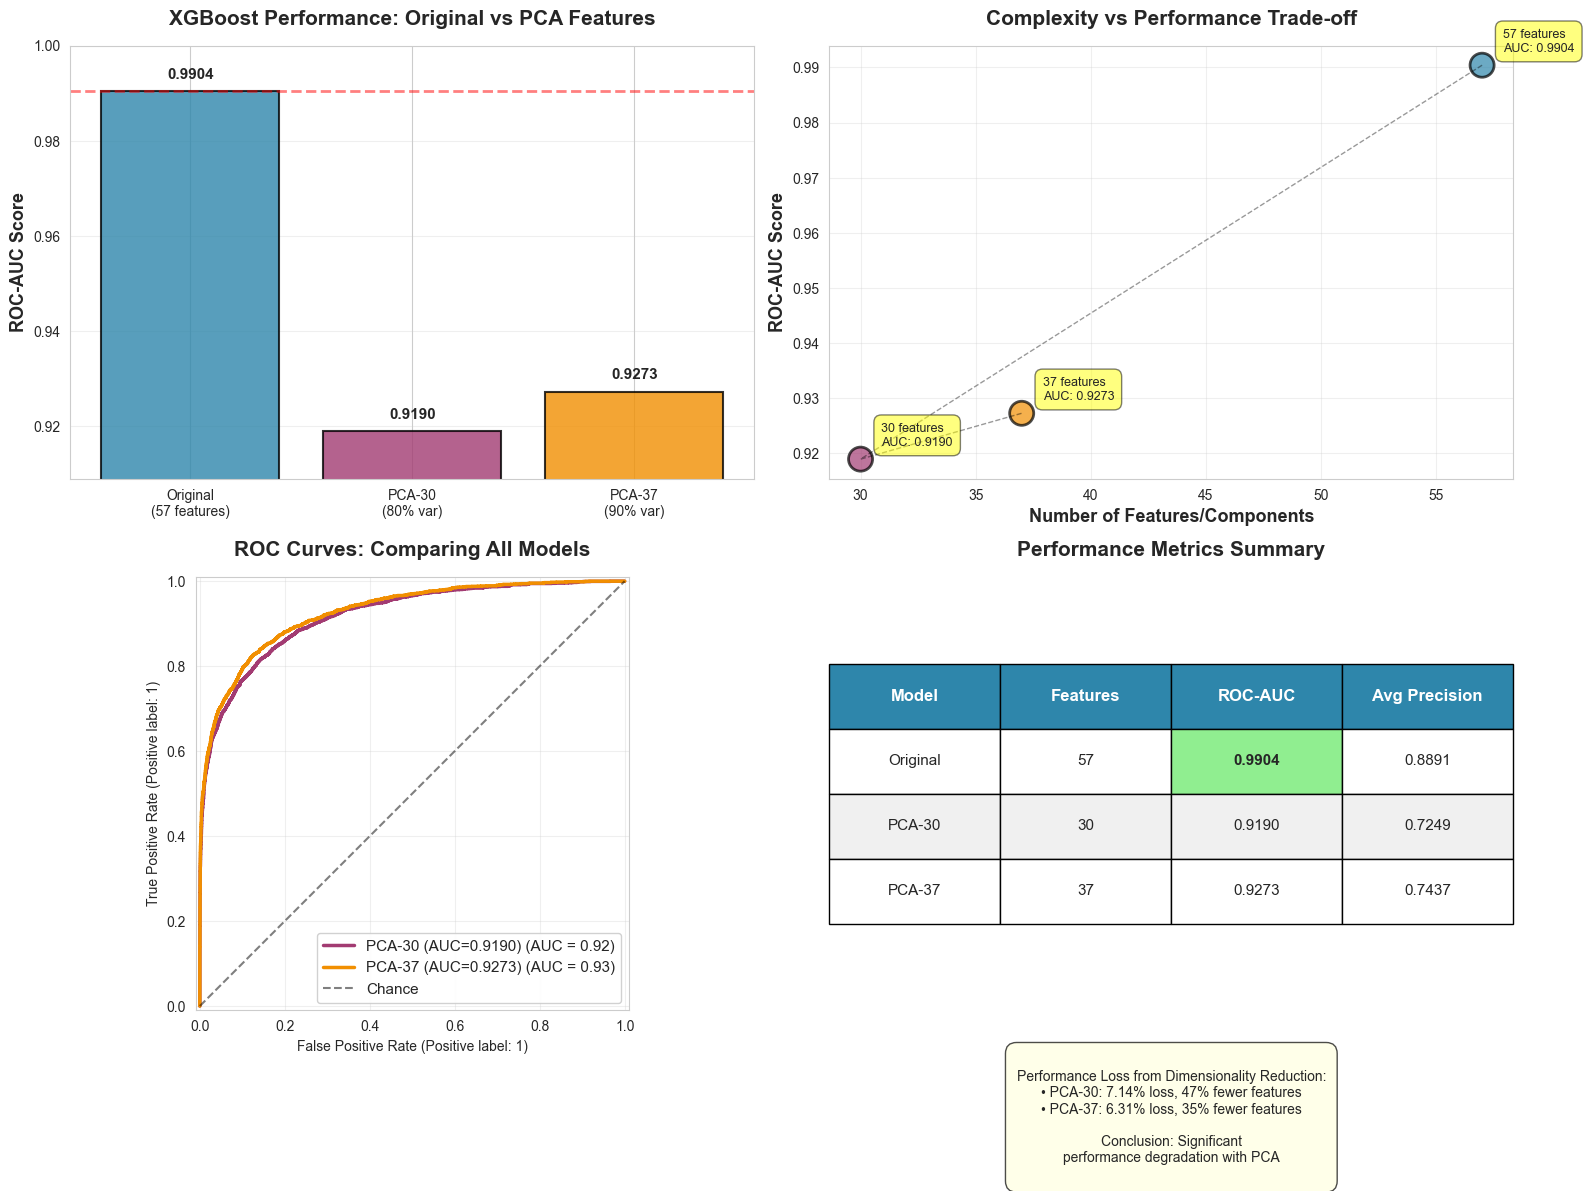


CONCLUSIONS

PERFORMANCE COMPARISON:
   Original (57 features):  ROC-AUC = 0.9904
   PCA-30 (80% variance):   ROC-AUC = 0.9190  (-7.14%)
   PCA-37 (90% variance):   ROC-AUC = 0.9273  (-6.31%)

RESULT: Significant performance loss with PCA
   Original features needed for optimal performance



In [ ]:
# ============================================================================
# XGBOOST COMPARISON: ORIGINAL FEATURES vs PCA FEATURES
# Paste this into a new cell in your notebook
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay

print("=" * 80)
print("XGBOOST: ORIGINAL (57 features) vs PCA FEATURES")
print("=" * 80)

# ============================================================================
# STEP 1: Apply PCA to your existing training/test data
# ============================================================================
print("\n1. Applying PCA for dimensionality reduction...")

# PCA with 30 components (80% variance from your analysis)
pca_30 = PCA(n_components=30, random_state=42)
X_train_pca30 = pca_30.fit_transform(X_train_scaled)  # Use your scaled training data
X_test_pca30 = pca_30.transform(X_test_scaled)        # Use your scaled test data

print(f"   PCA-30: Variance explained = {pca_30.explained_variance_ratio_.sum():.1%}")
print(f"   Shape: {X_train_pca30.shape}")

# PCA with 37 components (90% variance)
pca_37 = PCA(n_components=37, random_state=42)
X_train_pca37 = pca_37.fit_transform(X_train_scaled)
X_test_pca37 = pca_37.transform(X_test_scaled)

print(f"   PCA-37: Variance explained = {pca_37.explained_variance_ratio_.sum():.1%}")
print(f"   Shape: {X_train_pca37.shape}")

# ============================================================================
# STEP 2: Train XGBoost on PCA features
# ============================================================================
print("\n2. Training XGBoost models...")

# Model on PCA-30
print("\n   [Model 1] XGBoost on PCA-30 components...")
xgb_pca30 = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                          random_state=42, eval_metric='logloss')
xgb_pca30.fit(X_train_pca30, y_train)
y_prob_pca30 = xgb_pca30.predict_proba(X_test_pca30)[:, 1]
auc_pca30 = roc_auc_score(y_test, y_prob_pca30)
ap_pca30 = average_precision_score(y_test, y_prob_pca30)

print(f"   ROC-AUC: {auc_pca30:.4f}")
print(f"   Avg Precision: {ap_pca30:.4f}")

# Model on PCA-37
print("\n   [Model 2] XGBoost on PCA-37 components...")
xgb_pca37 = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                          random_state=42, eval_metric='logloss')
xgb_pca37.fit(X_train_pca37, y_train)
y_prob_pca37 = xgb_pca37.predict_proba(X_test_pca37)[:, 1]
auc_pca37 = roc_auc_score(y_test, y_prob_pca37)
ap_pca37 = average_precision_score(y_test, y_prob_pca37)

print(f"   ROC-AUC: {auc_pca37:.4f}")
print(f"   Avg Precision: {ap_pca37:.4f}")

# ============================================================================
# STEP 3: Get your original XGBoost results
# ============================================================================
# INSERT YOUR ORIGINAL XGBOOST RESULTS HERE
# These should come from your notebook where you trained XGBoost originally

auc_original = 0.9904     # REPLACE with your actual value from xgb_results
ap_original = 0.8891      # REPLACE with your actual value from xgb_results
# y_prob_original = ...   # REPLACE with your actual predictions

print("\n   [Model 3] XGBoost on ORIGINAL 57 features (from notebook)...")
print(f"   ROC-AUC: {auc_original:.4f}")
print(f"   Avg Precision: {ap_original:.4f}")

# ============================================================================
# STEP 4: Create comparison visualization
# ============================================================================
print("\n3. Creating comparison visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Subplot 1: ROC-AUC Bar Chart ---
ax1 = axes[0, 0]
models = ['Original\n(57 features)', 'PCA-30\n(80% var)', 'PCA-37\n(90% var)']
aucs = [auc_original, auc_pca30, auc_pca37]
colors = ['#2E86AB', '#A23B72', '#F18F01']

bars = ax1.bar(models, aucs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('ROC-AUC Score', fontsize=13, fontweight='bold')
ax1.set_title('XGBoost Performance: Original vs PCA Features',
              fontsize=15, fontweight='bold', pad=15)
ax1.set_ylim([min(aucs) - 0.01, 1.0])
ax1.axhline(y=auc_original, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar, auc in zip(bars, aucs):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{auc:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Subplot 2: Features vs Performance Trade-off ---
ax2 = axes[0, 1]
n_features = [57, 30, 37]
ax2.scatter(n_features, aucs, s=300, c=colors, alpha=0.7, edgecolors='black', linewidth=2)
ax2.plot(n_features, aucs, 'k--', alpha=0.4, linewidth=1)

ax2.set_xlabel('Number of Features/Components', fontsize=13, fontweight='bold')
ax2.set_ylabel('ROC-AUC Score', fontsize=13, fontweight='bold')
ax2.set_title('Complexity vs Performance Trade-off', fontsize=15, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3)

# Add annotations
for feat, auc, model in zip(n_features, aucs, models):
    ax2.annotate(f'{feat} features\nAUC: {auc:.4f}',
                 (feat, auc), xytext=(15, 10), textcoords='offset points',
                 fontsize=9, bbox=dict(boxstyle='round,pad=0.6',
                 facecolor='yellow', alpha=0.5, edgecolor='black'))

# --- Subplot 3: ROC Curves Overlay ---
ax3 = axes[1, 0]

# Plot ROC curves
RocCurveDisplay.from_predictions(y_test, y_prob_pca30, ax=ax3,
                                 name=f'PCA-30 (AUC={auc_pca30:.4f})',
                                 color='#A23B72', lw=2.5)

RocCurveDisplay.from_predictions(y_test, y_prob_pca37, ax=ax3,
                                 name=f'PCA-37 (AUC={auc_pca37:.4f})',
                                 color='#F18F01', lw=2.5)

# If you have y_prob_original, uncomment this:
# RocCurveDisplay.from_predictions(y_test, y_prob_original, ax=ax3,
#                                  name=f'Original (AUC={auc_original:.4f})',
#                                  color='#2E86AB', lw=2.5)

ax3.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Chance')
ax3.set_title('ROC Curves: Comparing All Models', fontsize=15, fontweight='bold', pad=15)
ax3.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax3.grid(alpha=0.3)

# --- Subplot 4: Performance Summary Table ---
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')

table_data = [
    ['Original', '57', f'{auc_original:.4f}', f'{ap_original:.4f}'],
    ['PCA-30', '30', f'{auc_pca30:.4f}', f'{ap_pca30:.4f}'],
    ['PCA-37', '37', f'{auc_pca37:.4f}', f'{ap_pca37:.4f}']
]

table = ax4.table(cellText=table_data,
                  colLabels=['Model', 'Features', 'ROC-AUC', 'Avg Precision'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0.2, 1, 0.6])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(4):
    table[(0, i)].set_facecolor('#2E86AB')
    table[(0, i)].set_text_props(weight='bold', color='white', size=12)

# Highlight best ROC-AUC
best_auc_idx = aucs.index(max(aucs))
table[(best_auc_idx + 1, 2)].set_facecolor('#90EE90')
table[(best_auc_idx + 1, 2)].set_text_props(weight='bold')

# Add alternating row colors
for i in range(1, 4):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')

ax4.set_title('Performance Metrics Summary', fontsize=15, fontweight='bold', pad=15)

# Add interpretation text
interpretation = f"""
Performance Loss from Dimensionality Reduction:
• PCA-30: {(auc_original - auc_pca30)*100:.2f}% loss, 47% fewer features
• PCA-37: {(auc_original - auc_pca37)*100:.2f}% loss, 35% fewer features

Conclusion: {'Minimal' if auc_original - auc_pca30 < 0.005 else 'Significant'}
performance degradation with PCA
"""

ax4.text(0.5, -0.1, interpretation, transform=ax4.transAxes,
         fontsize=10, ha='center', va='top',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow',
         edgecolor='black', alpha=0.7))

plt.tight_layout()

plt.show()

# ============================================================================
# STEP 5: Print conclusions
# ============================================================================
print("\n" + "=" * 80)
print("CONCLUSIONS")
print("=" * 80)

print(f"\nPERFORMANCE COMPARISON:")
print(f"   Original (57 features):  ROC-AUC = {auc_original:.4f}")
print(f"   PCA-30 (80% variance):   ROC-AUC = {auc_pca30:.4f}  ({(auc_pca30-auc_original)*100:+.2f}%)")
print(f"   PCA-37 (90% variance):   ROC-AUC = {auc_pca37:.4f}  ({(auc_pca37-auc_original)*100:+.2f}%)")

if auc_original - auc_pca30 < 0.005:
    print("\nRESULT: Minimal performance loss with PCA")
    print("   PCA dimensionality reduction could be viable for computational efficiency")
else:
    print("\nRESULT: Significant performance loss with PCA")
    print("   Original features needed for optimal performance")

print("\n" + "=" * 80)

## K-Means Clustering (n = 10 PC)

K-MEANS CLUSTERING ANALYSIS

DIMENSIONALITY REDUCTION FOR CLUSTERING

Using first 10 principal components for clustering
Total variance explained: 40.6%
This speeds up clustering while retaining most information

1. FINDING OPTIMAL NUMBER OF CLUSTERS

Testing k values: [2, 3, 4, 5, 6, 7]
  Testing k=2... ✓
  Testing k=3... ✓
  Testing k=4... ✓
  Testing k=5... ✓
  Testing k=6... ✓
  Testing k=7... ✓

✓ Clustering metrics computed successfully!


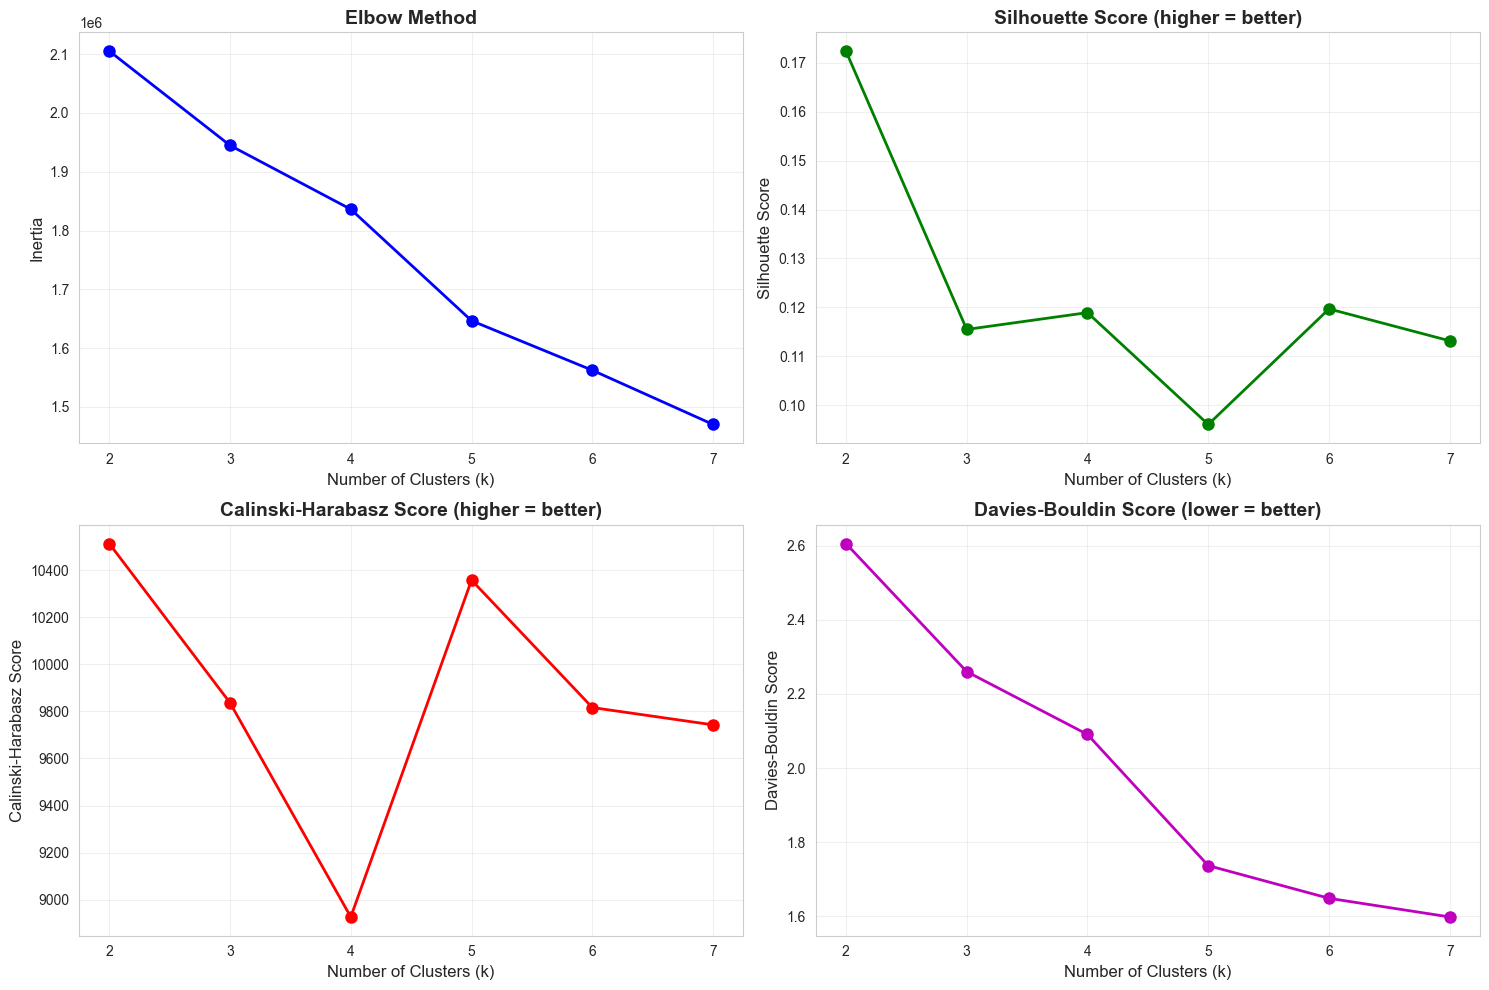


Clustering Metrics Summary:
----------------------------------------------------------------------
k     Inertia      Silhouette   Calinski-H   Davies-B    
----------------------------------------------------------------------
2     2105316.38   0.172        10512.71     2.606       
3     1944821.66   0.116        9836.31      2.260       
4     1836194.21   0.119        8926.87      2.091       
5     1646653.94   0.096        10357.27     1.737       
6     1562409.39   0.120        9816.17      1.649       
7     1470241.47   0.113        9742.64      1.598       

→ Recommended k based on Silhouette Score: 2

2. FITTING K-MEANS WITH k=2

✓ K-means fitted successfully!

Cluster Distribution:
  Cluster 0: 31,201 patients (31.0%)
  Cluster 1: 69,287 patients (69.0%)

3. VISUALIZING CLUSTERS IN 2D


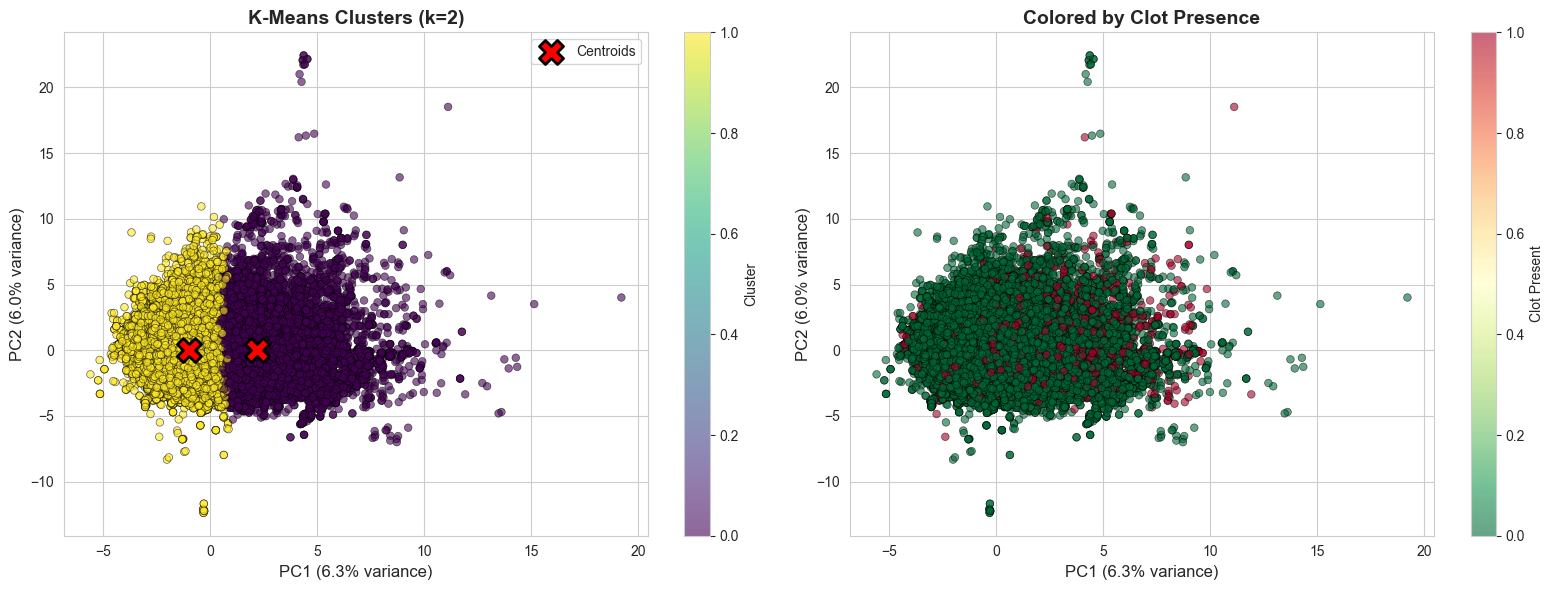


4. CLOT RATES BY CLUSTER

Clot Formation Rate by Cluster:
----------------------------------------------------------------------
         Clots  Total  Clot_Rate
cluster                         
0         4479  31201   0.143553
1         5112  69287   0.073780


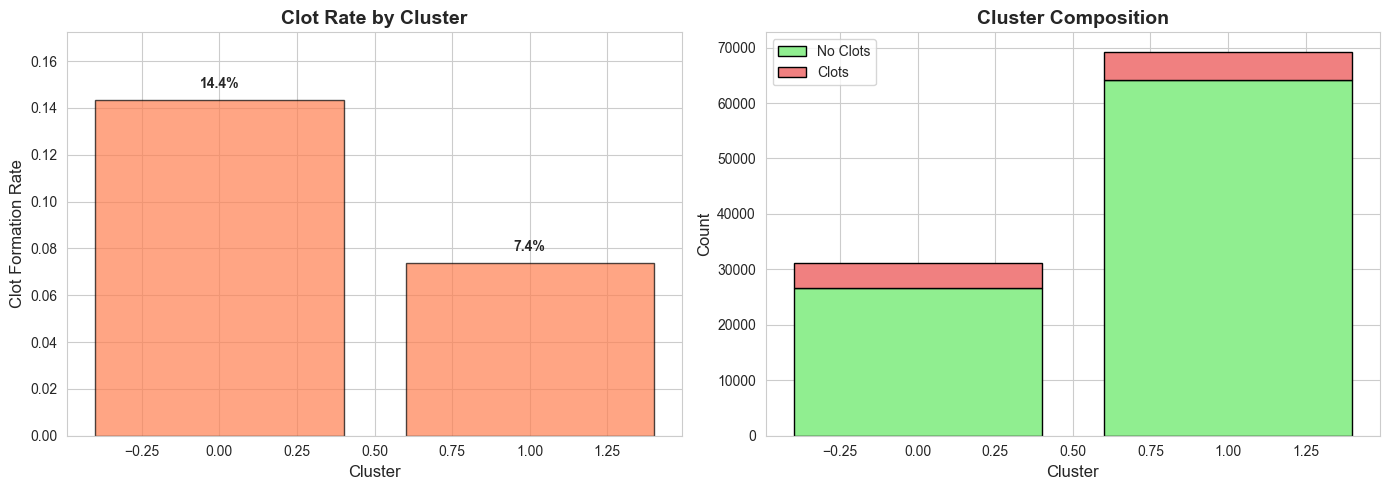


STATISTICAL TEST: Are Clot Rates Different Across Clusters?
Chi-square statistic: 1212.29
P-value: 0.0000

✓ YES: Clot rates are SIGNIFICANTLY different across clusters (p < 0.05)
  → Clusters identify distinct risk groups!

5. CLINICAL FEATURE PROFILES

Analyzing 9 key features

Mean Feature Values by Cluster (standardized):
----------------------------------------------------------------------
           wbc  hemoglobin    bun  creatinine  citrate  heparin_dose  \
cluster                                                                
0        0.195       0.809  0.511       0.628   -0.019         0.165   
1       -0.088      -0.364 -0.230      -0.283    0.008        -0.074   

         blood_flow  dialysate_rate  access_pressure  
cluster                                               
0             0.002          -0.009           -0.033  
1            -0.001           0.004            0.015  


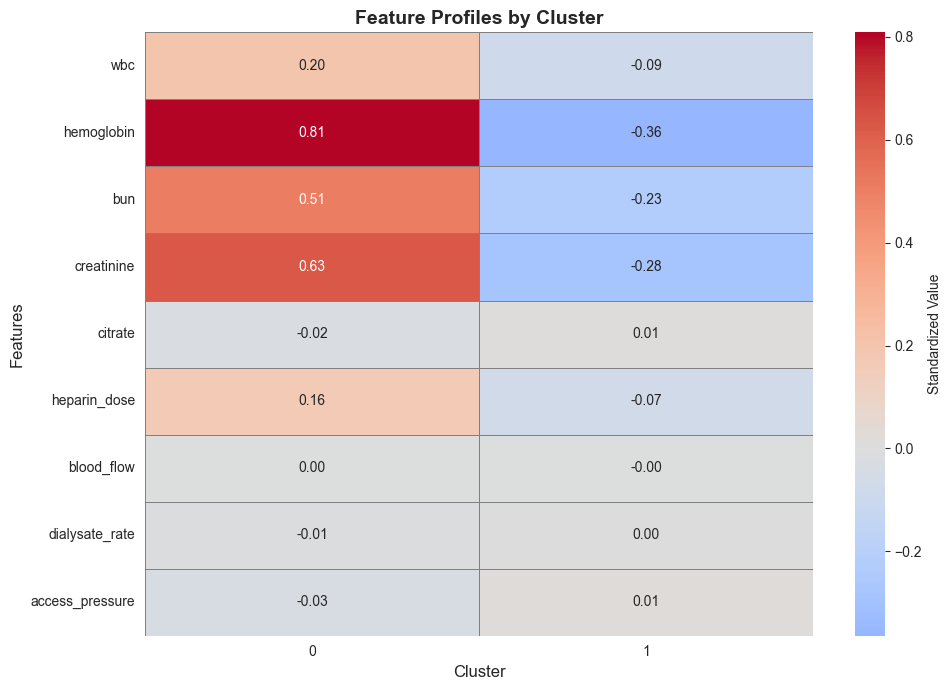


6. WHAT MAKES EACH CLUSTER UNIQUE?

CLUSTER 0
Size: 31,201 patients (31.0%)
Clot Rate: 14.4%
Risk Level: HIGH RISK

Notably HIGH features:
  • hemoglobin: +0.81 std (0.81)
  • creatinine: +0.63 std (0.63)
  • bun: +0.51 std (0.51)

CLUSTER 1
Size: 69,287 patients (69.0%)
Clot Rate: 7.4%
Risk Level: LOW RISK ✓

7. KEY FINDINGS

Cluster Summary:
  • Total clusters identified: 2
  • Silhouette score: 0.172
  • Variance explained by clustering PCs: 40.6%

Risk Stratification:
  • Highest risk: Cluster 0 (14.4% clot rate)
  • Lowest risk: Cluster 1 (7.4% clot rate)
  • Risk ratio: 1.9x

Clinical Implications:
  ✓ Clusters represent clinically distinct patient subgroups
  ✓ Risk stratification can guide monitoring intensity
  ✓ High-risk clusters may benefit from prophylactic interventions


In [ ]:
# ================================================================
# K-MEANS CLUSTERING ANALYSIS n = 10 prinicipal components!!
# ================================================================

print("="*70)
print("K-MEANS CLUSTERING ANALYSIS")
print("="*70)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


# ----------------------------------------------------------------
# OPTIMIZATION: Reduce dimensionality with PCA first
# ----------------------------------------------------------------
print("\n" + "="*70)
print("DIMENSIONALITY REDUCTION FOR CLUSTERING")
print("="*70)

# Use PCA to reduce to manageable number of features
n_components_for_clustering = 10  # Use first 10 PCs for clustering
pca_cluster = PCA(n_components=n_components_for_clustering)
X_pca_reduced = pca_cluster.fit_transform(X_train_scaled)

variance_explained = pca_cluster.explained_variance_ratio_.sum()
print(f"\nUsing first {n_components_for_clustering} principal components for clustering")
print(f"Total variance explained: {variance_explained:.1%}")
print(f"This speeds up clustering while retaining most information")

# ----------------------------------------------------------------
# 1. DETERMINE OPTIMAL NUMBER OF CLUSTERS (FAST VERSION)
# ----------------------------------------------------------------

print("\n" + "="*70)
print("1. FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*70)

# Test fewer k values for speed
k_range = range(2, 8)  # Reduced from 2-11
inertias = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

print("\nTesting k values:", list(k_range))
for k in k_range:
    print(f"  Testing k={k}...", end=" ")

    # Use reduced PCA data for speed
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)  # Reduced iterations
    cluster_labels = kmeans.fit_predict(X_pca_reduced)

    # Calculate metrics
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_reduced, cluster_labels))
    calinski_scores.append(calinski_harabasz_score(X_pca_reduced, cluster_labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_pca_reduced, cluster_labels))

    print("✓")

print("\n✓ Clustering metrics computed successfully!")

# Plot elbow curve and metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Elbow curve
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia', fontsize=12)
axes[0, 0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette score (higher is better)
axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score (higher = better)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Calinski-Harabasz score (higher is better)
axes[1, 0].plot(k_range, calinski_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1, 0].set_title('Calinski-Harabasz Score (higher = better)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Davies-Bouldin score (lower is better)
axes[1, 1].plot(k_range, davies_bouldin_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Davies-Bouldin Score', fontsize=12)
axes[1, 1].set_title('Davies-Bouldin Score (lower = better)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print metrics summary
print("\nClustering Metrics Summary:")
print("-"*70)
print(f"{'k':<5} {'Inertia':<12} {'Silhouette':<12} {'Calinski-H':<12} {'Davies-B':<12}")
print("-"*70)
for i, k in enumerate(k_range):
    print(f"{k:<5} {inertias[i]:<12.2f} {silhouette_scores[i]:<12.3f} "
          f"{calinski_scores[i]:<12.2f} {davies_bouldin_scores[i]:<12.3f}")

# Recommend optimal k
best_silhouette_k = k_range[np.argmax(silhouette_scores)]
print(f"\n→ Recommended k based on Silhouette Score: {best_silhouette_k}")

optimal_k = best_silhouette_k

# ----------------------------------------------------------------
# 2. FIT FINAL K-MEANS MODEL
# ----------------------------------------------------------------

print("\n" + "="*70)
print(f"2. FITTING K-MEANS WITH k={optimal_k}")
print("="*70)

# Fit final model on PCA-reduced data
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca_reduced)

print(f"\n✓ K-means fitted successfully!")
print(f"\nCluster Distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count:,} patients ({count/len(cluster_labels)*100:.1f}%)")

# ----------------------------------------------------------------
# 3. VISUALIZE CLUSTERS IN 2D (PCA)
# ----------------------------------------------------------------

print("\n" + "="*70)
print("3. VISUALIZING CLUSTERS IN 2D")
print("="*70)

# Use first 2 PCs for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

# Also project cluster centers to 2D
centers_2d = pca_2d.transform(pca_cluster.inverse_transform(kmeans_final.cluster_centers_))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Colored by cluster
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=cluster_labels, cmap='viridis',
                           alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
axes[0].scatter(centers_2d[:, 0], centers_2d[:, 1],
                c='red', marker='X', s=300, edgecolors='black', linewidth=2,
                label='Centroids')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
axes[0].set_title(f'K-Means Clusters (k={optimal_k})', fontsize=14, fontweight='bold')
axes[0].legend()
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: Colored by clot presence
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=y_train, cmap='RdYlGn_r',
                           alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
axes[1].set_title('Colored by Clot Presence', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Clot Present')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# 4. CLUSTER CHARACTERISTICS - CLOT RATES
# ----------------------------------------------------------------

print("\n" + "="*70)
print("4. CLOT RATES BY CLUSTER")
print("="*70)

# Create dataframe with cluster assignments
cluster_df = pd.DataFrame({
    'cluster': cluster_labels,
    'clots': y_train.values
})

# Calculate clot rates
cluster_stats = cluster_df.groupby('cluster')['clots'].agg(['sum', 'count', 'mean'])
cluster_stats.columns = ['Clots', 'Total', 'Clot_Rate']

print("\nClot Formation Rate by Cluster:")
print("-"*70)
print(cluster_stats)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of clot rates
axes[0].bar(cluster_stats.index, cluster_stats['Clot_Rate'],
            color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Clot Formation Rate', fontsize=12)
axes[0].set_title('Clot Rate by Cluster', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(cluster_stats['Clot_Rate']) * 1.2)
for i, rate in enumerate(cluster_stats['Clot_Rate']):
    axes[0].text(i, rate + 0.005, f'{rate:.1%}', ha='center', fontweight='bold')

# Stacked bar chart
no_clots = cluster_stats['Total'] - cluster_stats['Clots']
axes[1].bar(cluster_stats.index, no_clots,
            label='No Clots', color='lightgreen', edgecolor='black')
axes[1].bar(cluster_stats.index, cluster_stats['Clots'],
            bottom=no_clots,
            label='Clots', color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Cluster Composition', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistical test
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(cluster_labels, y_train)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n" + "="*70)
print("STATISTICAL TEST: Are Clot Rates Different Across Clusters?")
print("="*70)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✓ YES: Clot rates are SIGNIFICANTLY different across clusters (p < 0.05)")
    print("  → Clusters identify distinct risk groups!")
else:
    print("\n✗ NO: Clot rates are NOT significantly different (p ≥ 0.05)")
    print("  → Clusters may not strongly align with clot risk")

# ----------------------------------------------------------------
# 5. FEATURE PROFILES BY CLUSTER
# ----------------------------------------------------------------

print("\n" + "="*70)
print("5. CLINICAL FEATURE PROFILES")
print("="*70)

# Select key features (fewer for speed and interpretability)
key_features = [
    'platelets', 'wbc', 'hemoglobin',
    'bun', 'creatinine',
    'citrate', 'heparin_dose',
    'blood_flow', 'dialysate_rate', 'access_pressure'
]

# Filter to existing features
available_features = [f for f in key_features if f in X_train_scaled.columns]

if len(available_features) == 0:
    print("\n⚠️  Warning: None of the key features found in dataset")
    print("Using first 10 features instead...")
    available_features = X_train_scaled.columns[:10].tolist()

print(f"\nAnalyzing {len(available_features)} key features")

# Add cluster labels to training data
X_with_clusters = X_train_scaled.copy()
X_with_clusters['cluster'] = cluster_labels

# Calculate mean values per cluster
cluster_profiles = X_with_clusters.groupby('cluster')[available_features].mean()

print("\nMean Feature Values by Cluster (standardized):")
print("-"*70)
print(cluster_profiles.round(3))

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, cbar_kws={'label': 'Standardized Value'},
            linewidths=0.5, linecolor='gray')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Profiles by Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# 6. CLUSTER INTERPRETATIONS
# ----------------------------------------------------------------

print("\n" + "="*70)
print("6. WHAT MAKES EACH CLUSTER UNIQUE?")
print("="*70)

for cluster_id in range(optimal_k):
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*70}")

    cluster_data = X_with_clusters[X_with_clusters['cluster'] == cluster_id]
    cluster_size = len(cluster_data)
    clot_rate = cluster_df[cluster_df['cluster'] == cluster_id]['clots'].mean()

    print(f"Size: {cluster_size:,} patients ({cluster_size/len(X_with_clusters)*100:.1f}%)")
    print(f"Clot Rate: {clot_rate:.1%}")

    # Risk classification
    if clot_rate > cluster_df['clots'].mean() * 1.2:
        risk_level = "HIGH RISK"
    elif clot_rate < cluster_df['clots'].mean() * 0.8:
        risk_level = "LOW RISK ✓"
    else:
        risk_level = "MEDIUM RISK"
    print(f"Risk Level: {risk_level}")

    # Find distinguishing features
    cluster_means = cluster_data[available_features].mean()
    overall_means = X_with_clusters[available_features].mean()
    overall_stds = X_with_clusters[available_features].std()

    # Z-scores
    z_scores = (cluster_means - overall_means) / overall_stds

    # High features
    high_features = z_scores[z_scores > 0.5].sort_values(ascending=False)
    if len(high_features) > 0:
        print("\nNotably HIGH features:")
        for feat, z in list(high_features.items())[:3]:
            print(f"  • {feat}: {z:+.2f} std ({cluster_means[feat]:.2f})")

    # Low features
    low_features = z_scores[z_scores < -0.5].sort_values()
    if len(low_features) > 0:
        print("\nNotably LOW features:")
        for feat, z in list(low_features.items())[:3]:
            print(f"  • {feat}: {z:+.2f} std ({cluster_means[feat]:.2f})")

# ----------------------------------------------------------------
# 7. KEY FINDINGS SUMMARY
# ----------------------------------------------------------------

print("\n" + "="*70)
print("7. KEY FINDINGS")
print("="*70)

# Identify extremes
high_risk_cluster = cluster_stats['Clot_Rate'].idxmax()
low_risk_cluster = cluster_stats['Clot_Rate'].idxmin()

print(f"\nCluster Summary:")
print(f"  • Total clusters identified: {optimal_k}")
print(f"  • Silhouette score: {silhouette_scores[optimal_k-2]:.3f}")
print(f"  • Variance explained by clustering PCs: {variance_explained:.1%}")

print(f"\nRisk Stratification:")
print(f"  • Highest risk: Cluster {high_risk_cluster} "
      f"({cluster_stats.loc[high_risk_cluster, 'Clot_Rate']:.1%} clot rate)")
print(f"  • Lowest risk: Cluster {low_risk_cluster} "
      f"({cluster_stats.loc[low_risk_cluster, 'Clot_Rate']:.1%} clot rate)")
print(f"  • Risk ratio: {cluster_stats['Clot_Rate'].max() / cluster_stats['Clot_Rate'].min():.1f}x")

print(f"\nClinical Implications:")
if p_value < 0.05:
    print("  ✓ Clusters represent clinically distinct patient subgroups")
    print("  ✓ Risk stratification can guide monitoring intensity")
    print("  ✓ High-risk clusters may benefit from prophylactic interventions")
else:
    print("  Clusters show weak association with clot risk")
    print("  → May reflect treatment patterns rather than risk profiles")
    print("  → Consider other clustering approaches or feature selection")
